## ERA5 Monthly Averaged Data Analysis 

In [17]:
#%matplotlib inline 
# this line is required for the plots to appear in the Jupyter cells, rather than launching the matplotlib GUI
%matplotlib notebook
#this allows interactive view but you need to be in classic rather than CoCalc Jupyter notebook for this to work

import matplotlib

import numpy as np

import matplotlib.pyplot as plt


# Let printing work the same in Python 2 and 3
from __future__ import division,print_function

# notice two underscores _ either side of future

import xarray as xr
import netCDF4 as nc

First I tried to download 1 year of data for just temperature to test data out. Dowloaded from following link: https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-monthly-means?tab=overview


Sub-region extraction for UK:

North: 61 degrees

West: - 8 degrees

South: 49 degrees

East: 2 degrees

In [2]:
data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda.nc")

In [3]:
# Prints all the variables listed in the .nc file
print(data.data_vars)

Data variables:
    d2m      (valid_time, latitude, longitude) float32 587kB ...
    t2m      (valid_time, latitude, longitude) float32 587kB ...
    skt      (valid_time, latitude, longitude) float32 587kB ...
    stl1     (valid_time, latitude, longitude) float32 587kB ...
    stl2     (valid_time, latitude, longitude) float32 587kB ...
    stl3     (valid_time, latitude, longitude) float32 587kB ...
    stl4     (valid_time, latitude, longitude) float32 587kB ...


In [4]:
# Prints all the dimensions listed in the .nc file
print(data.dims)

FrozenMappingWarningOnValuesAccess({'valid_time': 12, 'latitude': 121, 'longitude': 101})


In [5]:
# Prints all the attributes listed in the .nc file
print(data.attrs)

{'GRIB_centre': 'ecmf', 'GRIB_centreDescription': 'European Centre for Medium-Range Weather Forecasts', 'GRIB_subCentre': 0, 'Conventions': 'CF-1.7', 'institution': 'European Centre for Medium-Range Weather Forecasts', 'history': '2025-06-30T18:16 GRIB to CDM+CF via cfgrib-0.9.15.0/ecCodes-2.41.0 with {"source": "data.grib", "filter_by_keys": {"stream": ["moda"]}, "encode_cf": ["parameter", "time", "geography", "vertical"]}'}


In [6]:
# Prints the data of the variable
print(data.d2m)

<xarray.DataArray 'd2m' (valid_time: 12, latitude: 121, longitude: 101)> Size: 587kB
[146652 values with dtype=float32]
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 96B 2024-01-01 ... 2024-12-01
  * latitude    (latitude) float64 968B 61.0 60.9 60.8 60.7 ... 49.2 49.1 49.0
  * longitude   (longitude) float64 808B -8.0 -7.9 -7.8 -7.7 ... 1.7 1.8 1.9 2.0
    expver      (valid_time) <U4 192B ...
Attributes: (12/31)
    GRIB_paramId:                             168
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      12221
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units: 

In [7]:
# Variables can be converted to numpy arrays
data_one_year = data.d2m.values
data_all_months = data.d2m.values

# Print the shape of the numpy array
print(data_one_year.shape)
print(data_all_months.shape)

(12, 121, 101)
(12, 121, 101)


In [8]:
print(data_one_year)

[[[      nan       nan       nan ...       nan       nan       nan]
  [      nan       nan       nan ...       nan       nan       nan]
  [      nan       nan       nan ...       nan       nan       nan]
  ...
  [      nan       nan       nan ... 274.22656 274.18555 274.14453]
  [      nan       nan       nan ... 274.33203 274.32422 274.32227]
  [      nan       nan       nan ... 274.45898 274.47266 274.50586]]

 [[      nan       nan       nan ...       nan       nan       nan]
  [      nan       nan       nan ...       nan       nan       nan]
  [      nan       nan       nan ...       nan       nan       nan]
  ...
  [      nan       nan       nan ... 279.47974 279.43677 279.386  ]
  [      nan       nan       nan ... 279.5227  279.5188  279.52466]
  [      nan       nan       nan ... 279.5852  279.60474 279.64185]]

 [[      nan       nan       nan ...       nan       nan       nan]
  [      nan       nan       nan ...       nan       nan       nan]
  [      nan       nan       nan

<IPython.core.display.Javascript object>


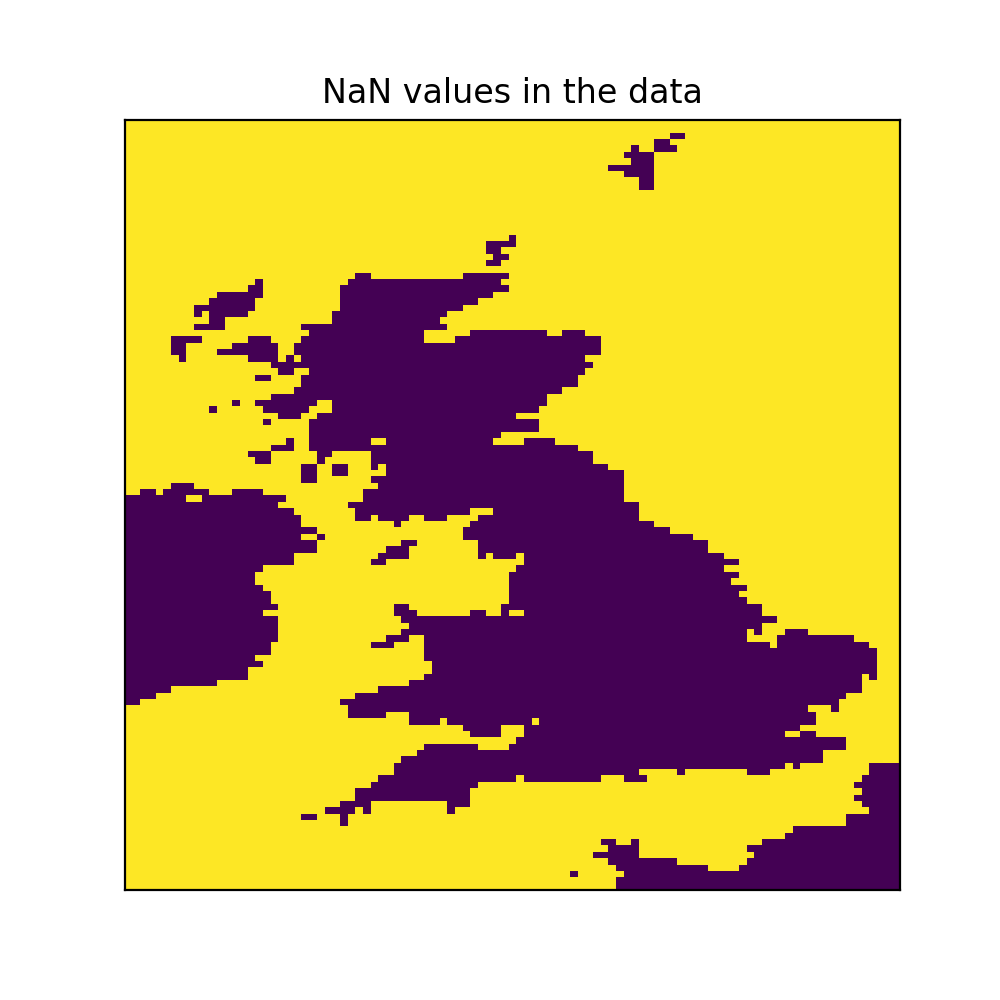

In [9]:
temperature_data = data['d2m']

plt.figure(figsize=(5, 5))
ax = temperature_data.isnull().sum(dim='valid_time').plot(add_colorbar=False)
plt.title('NaN values in the data')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.show()

Now downloaded a file with multiple variables (temperatures, soil, percipitation, surface pressure, wind strength (u and v components)) across multiple years (1950 to 2025)

In [10]:
data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

In [11]:
# Prints all the variables listed in the .nc file
print(data.data_vars)

Data variables:
    d2m      (valid_time, latitude, longitude) float32 45MB ...
    t2m      (valid_time, latitude, longitude) float32 45MB ...
    skt      (valid_time, latitude, longitude) float32 45MB ...
    stl1     (valid_time, latitude, longitude) float32 45MB ...
    stl2     (valid_time, latitude, longitude) float32 45MB ...
    stl3     (valid_time, latitude, longitude) float32 45MB ...
    stl4     (valid_time, latitude, longitude) float32 45MB ...
    src      (valid_time, latitude, longitude) float32 45MB ...
    swvl1    (valid_time, latitude, longitude) float32 45MB ...
    swvl2    (valid_time, latitude, longitude) float32 45MB ...
    swvl3    (valid_time, latitude, longitude) float32 45MB ...
    swvl4    (valid_time, latitude, longitude) float32 45MB ...
    u10      (valid_time, latitude, longitude) float32 45MB ...
    v10      (valid_time, latitude, longitude) float32 45MB ...
    sp       (valid_time, latitude, longitude) float32 45MB ...
    tp       (valid_time

In [12]:
# Prints all the dimensions listed in the .nc file
print(data.dims)

FrozenMappingWarningOnValuesAccess({'valid_time': 905, 'latitude': 121, 'longitude': 103})


In [13]:
# Prints all the attributes listed in the .nc file
print(data.attrs)

{'GRIB_centre': 'ecmf', 'GRIB_centreDescription': 'European Centre for Medium-Range Weather Forecasts', 'GRIB_subCentre': 0, 'Conventions': 'CF-1.7', 'institution': 'European Centre for Medium-Range Weather Forecasts', 'history': '2025-06-30T19:25 GRIB to CDM+CF via cfgrib-0.9.15.0/ecCodes-2.41.0 with {"source": "data.grib", "filter_by_keys": {"stream": ["moda"]}, "encode_cf": ["parameter", "time", "geography", "vertical"]}'}


In [14]:
# Prints the data of the variable
print(data.src)

<xarray.DataArray 'src' (valid_time: 905, latitude: 121, longitude: 103)> Size: 45MB
[11279015 values with dtype=float32]
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 7kB 1950-01-01 ... 2025-05-01
  * latitude    (latitude) float64 968B 61.0 60.9 60.8 60.7 ... 49.2 49.1 49.0
  * longitude   (longitude) float64 824B -8.2 -8.1 -8.0 -7.9 ... 1.7 1.8 1.9 2.0
    expver      (valid_time) <U4 14kB ...
Attributes: (12/31)
    GRIB_paramId:                             198
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      12463
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m of water equivalent
    long_name:                                Skin reservoir con

In [15]:
# Variables can be converted to numpy arrays
data_one_year = data.src.values
data_all_months = data.src.values

# Print the shape of the numpy array
print(data_one_year.shape)
print(data_all_months.shape)

(905, 121, 103)
(905, 121, 103)


In [16]:
print(data_one_year)

[[[           nan            nan            nan ...            nan
              nan            nan]
  [           nan            nan            nan ...            nan
              nan            nan]
  [           nan            nan            nan ...            nan
              nan            nan]
  ...
  [           nan            nan            nan ... 7.65770674e-05
   7.63982534e-05 7.85440207e-05]
  [           nan            nan            nan ... 7.76052475e-05
   7.89463520e-05 8.05556774e-05]
  [           nan            nan            nan ... 7.79181719e-05
   7.86781311e-05 7.38352537e-05]]

 [[           nan            nan            nan ...            nan
              nan            nan]
  [           nan            nan            nan ...            nan
              nan            nan]
  [           nan            nan            nan ...            nan
              nan            nan]
  ...
  [           nan            nan            nan ... 1.09493732e-04
   1.12339

In [17]:
last_time = data.valid_time.values[-1]
print(last_time)

2025-05-01T00:00:00.000000000


In [18]:
import pandas as pd

last_timestamp = pd.to_datetime(data.valid_time.values[-1])
print("Month:", last_timestamp.strftime('%B'))  

Month: May


<IPython.core.display.Javascript object>


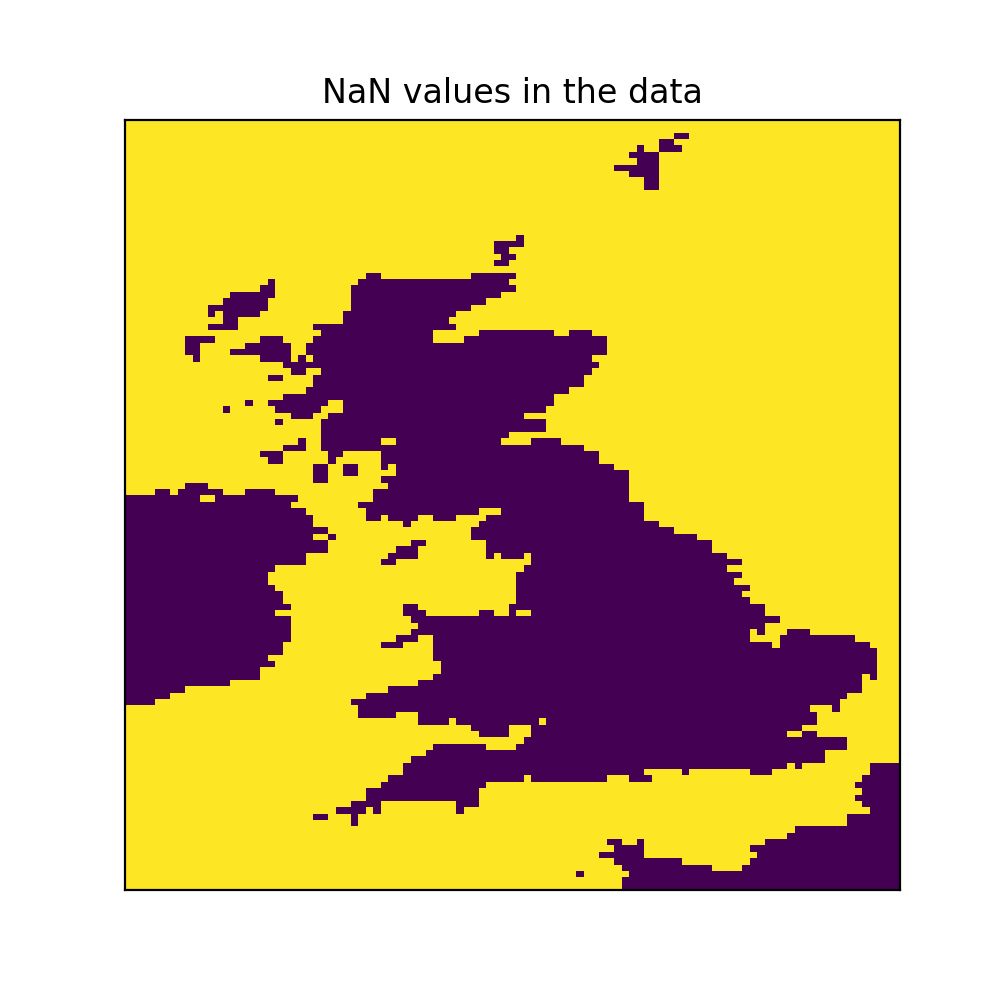

In [19]:
temperature_data = data['d2m']

plt.figure(figsize=(5, 5))
ax = temperature_data.isnull().sum(dim='valid_time').plot(add_colorbar=False)
plt.title('NaN values in the data')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.show()

## Map for each variable

1. 2m Dewpoint Temperature
2. 2m Temperature
3. Skin Temperature
4. Soil Temperature Level 1
5. Soil Temperature Level 2
6. Soil Temperature Level 3
7. Soil Temperature Level 4
8. Skin Resevoir Content
9. Volumetric Soil Water Layer 1
10. Volumetric Soil Water Layer 2
11. Volumetric Soil Water Layer 3
12. Volumetric Soil Water Layer 4
13. 10m u-component of wind
14. 10m v-component of wind
15. Surface Pressure
16. Total Precipitation

<IPython.core.display.Javascript object>


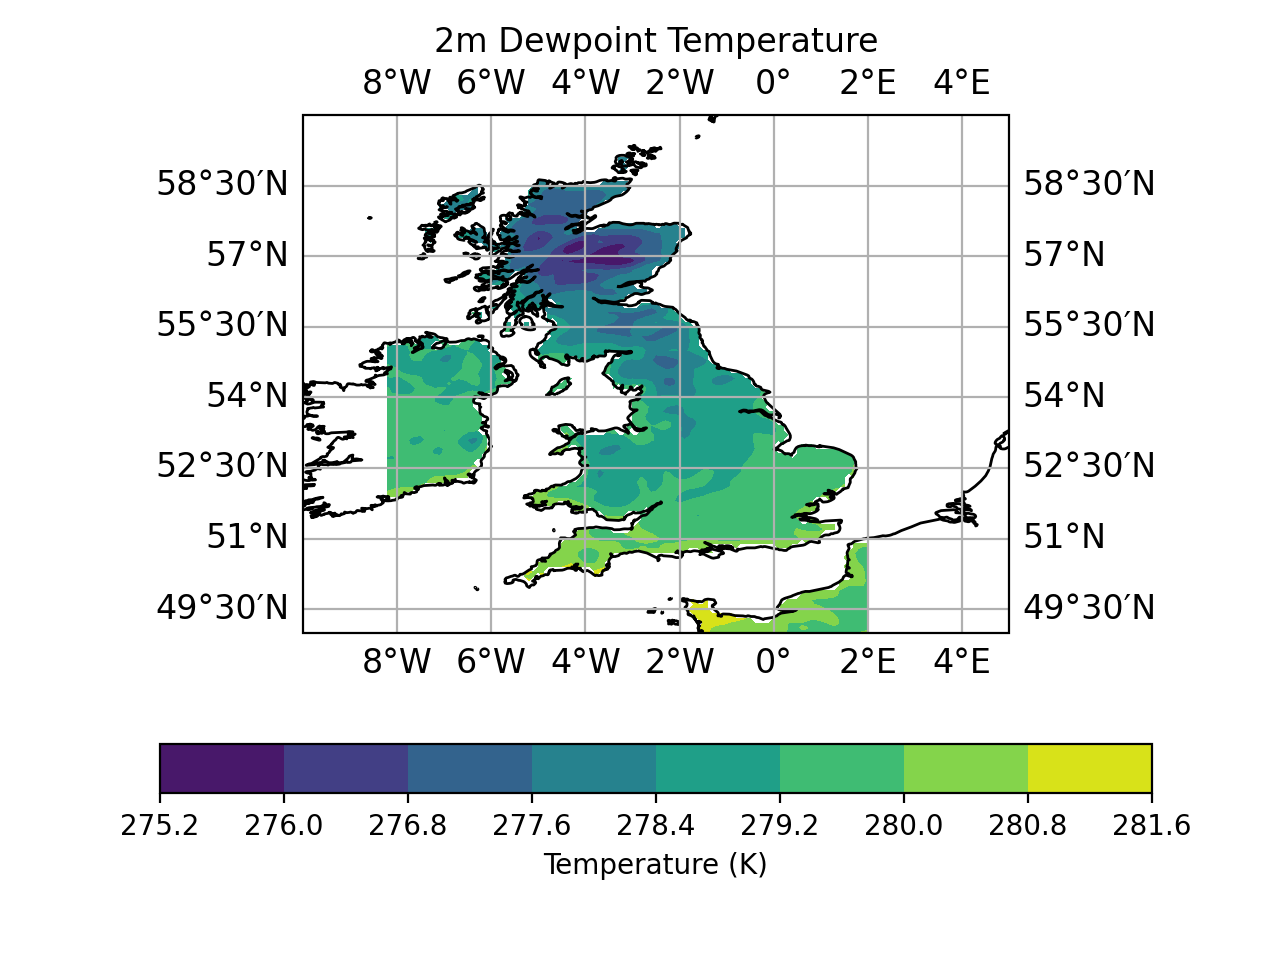

In [20]:
import cartopy.crs as ccrs


lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.d2m.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('2m Dewpoint Temperature')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Temperature (K)")

plt.show()

<IPython.core.display.Javascript object>


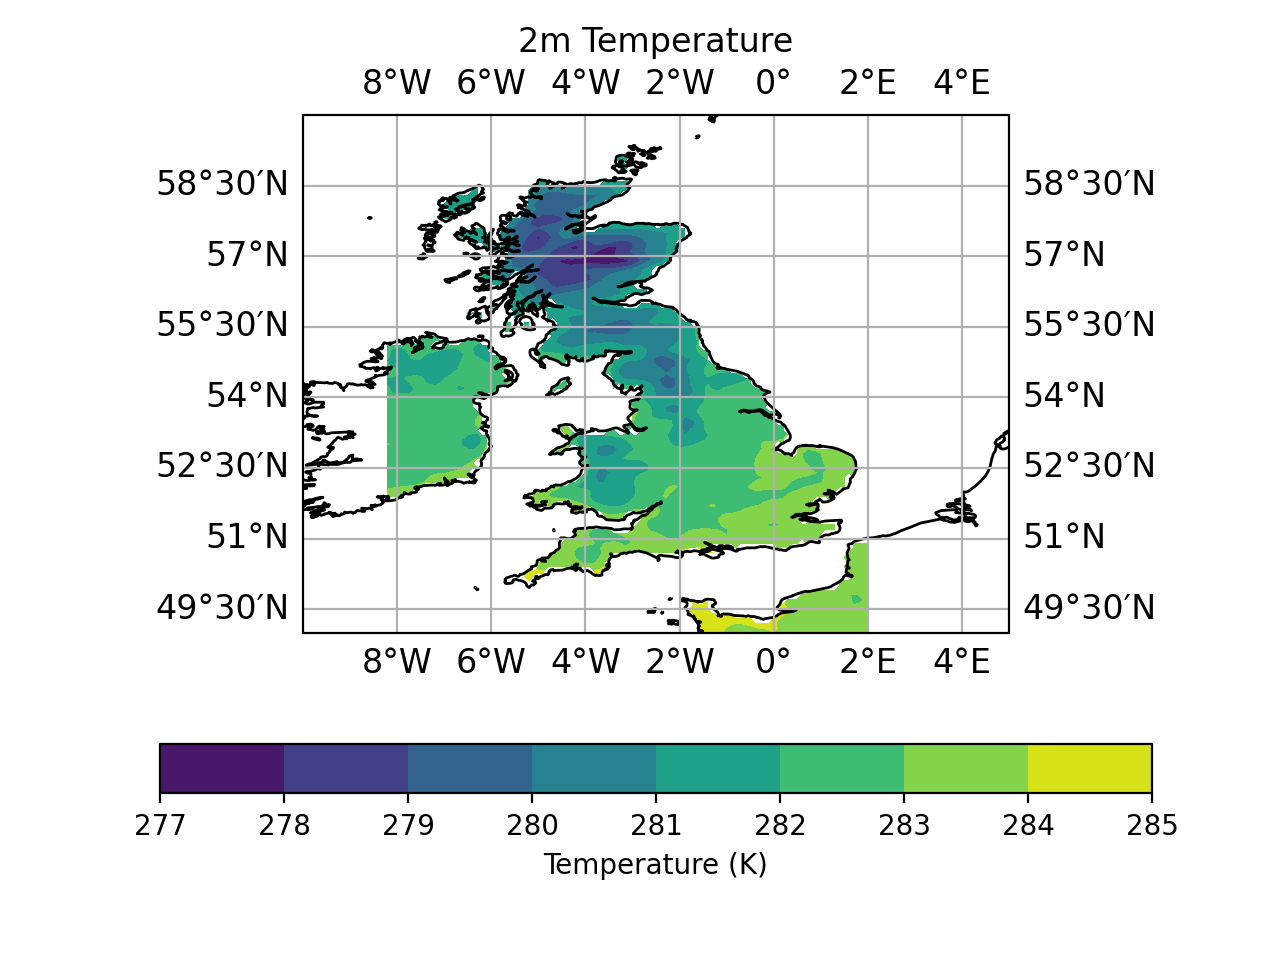

In [21]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.t2m.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('2m Temperature')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Temperature (K)")

plt.show()

<IPython.core.display.Javascript object>


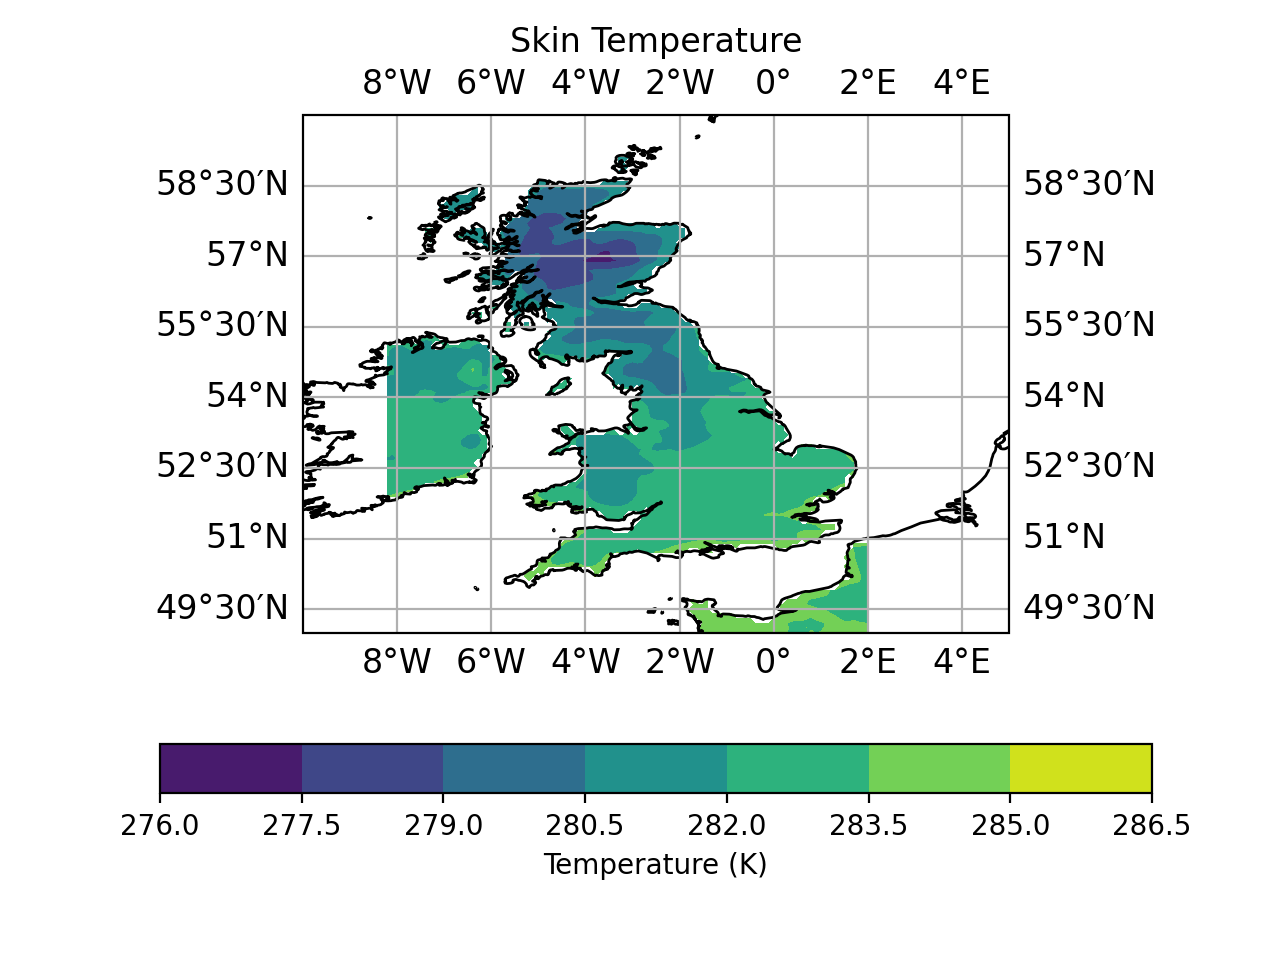

In [22]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.skt.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Skin Temperature')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Temperature (K)")

plt.show()

<IPython.core.display.Javascript object>


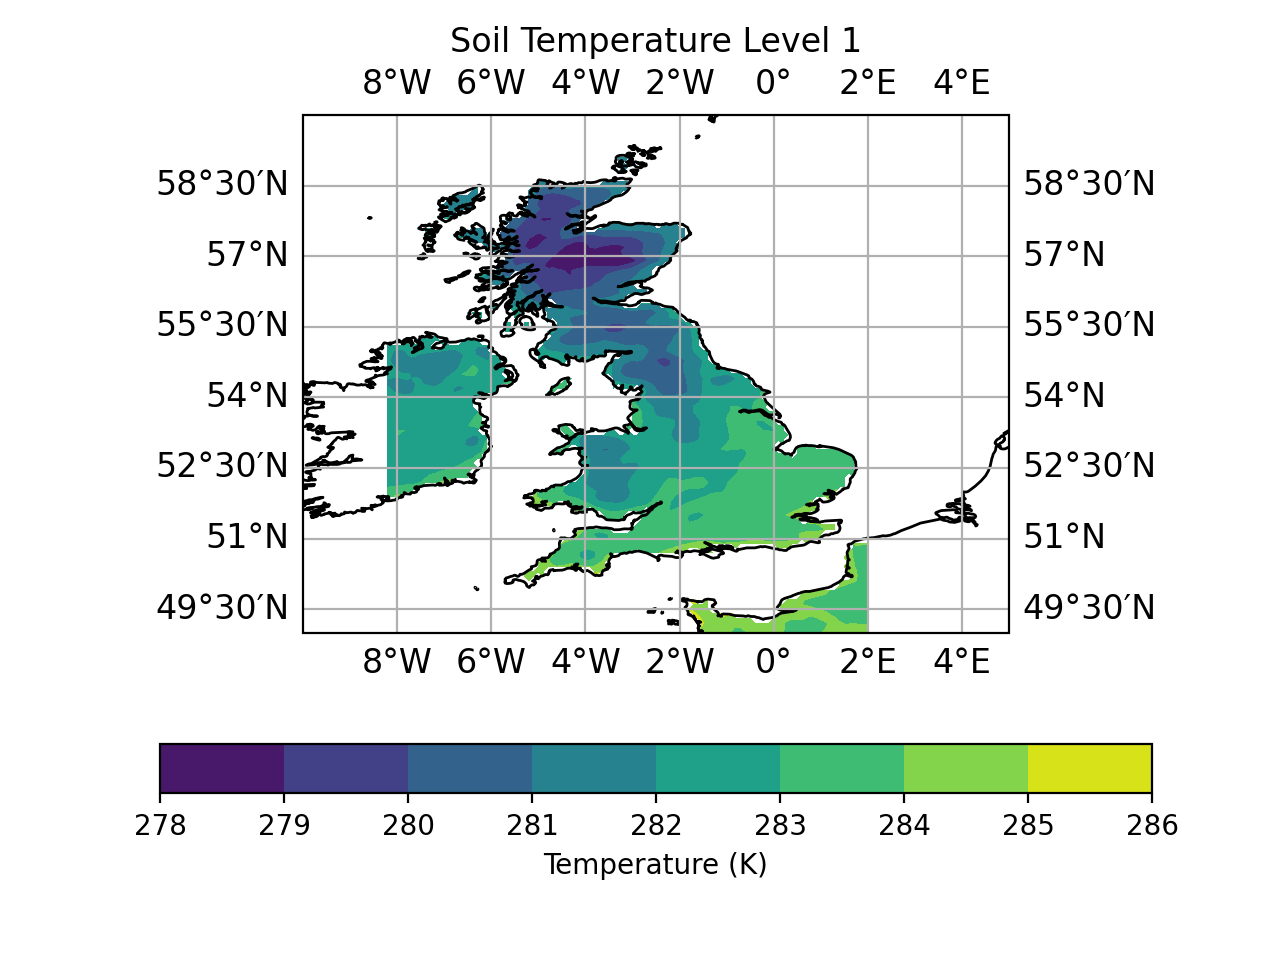

In [23]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.stl1.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Soil Temperature Level 1')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Temperature (K)")

plt.show()

<IPython.core.display.Javascript object>


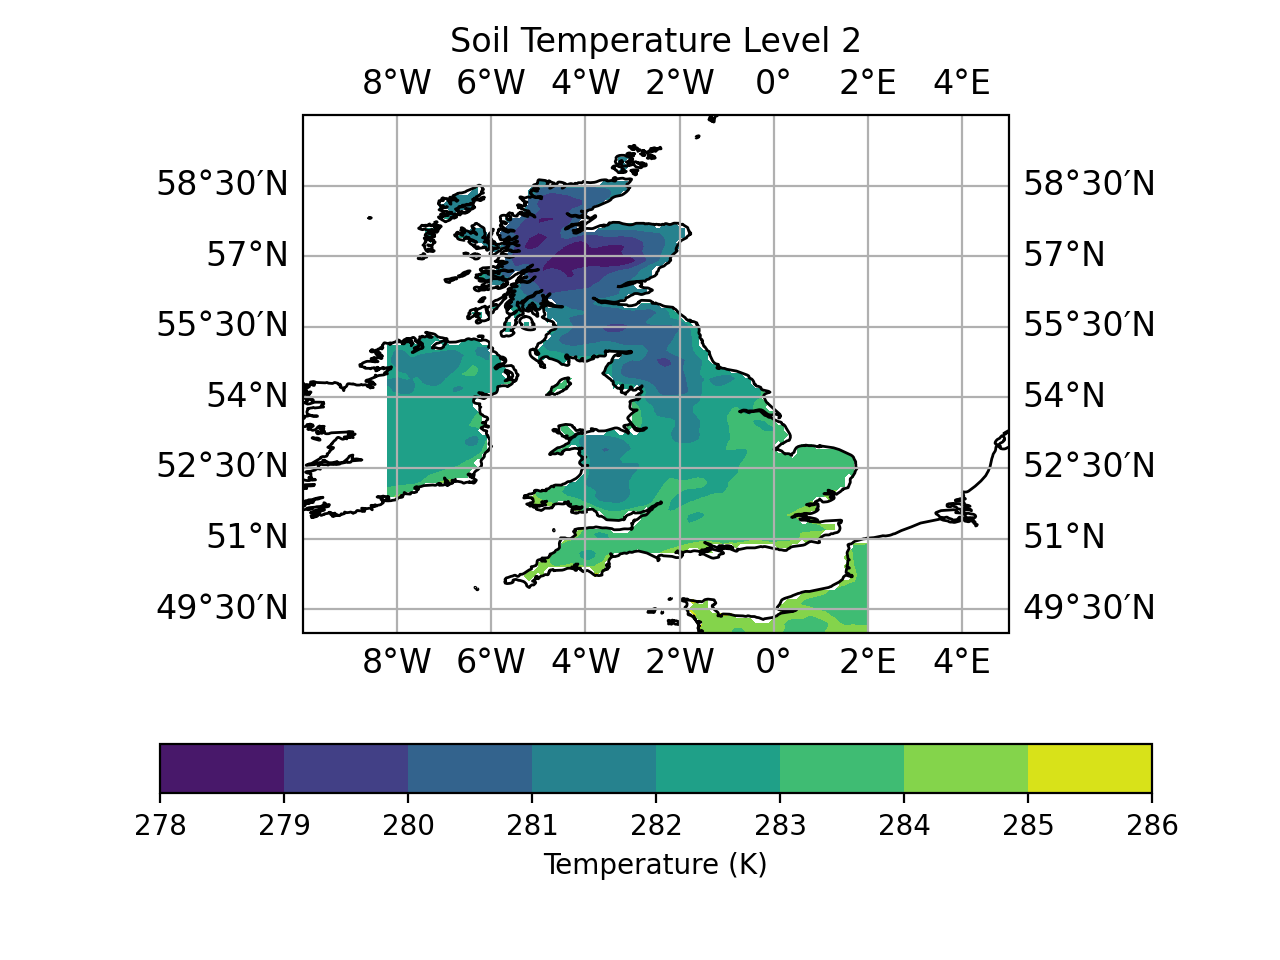

In [24]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.stl2.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Soil Temperature Level 2')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Temperature (K)")

plt.show()

<IPython.core.display.Javascript object>


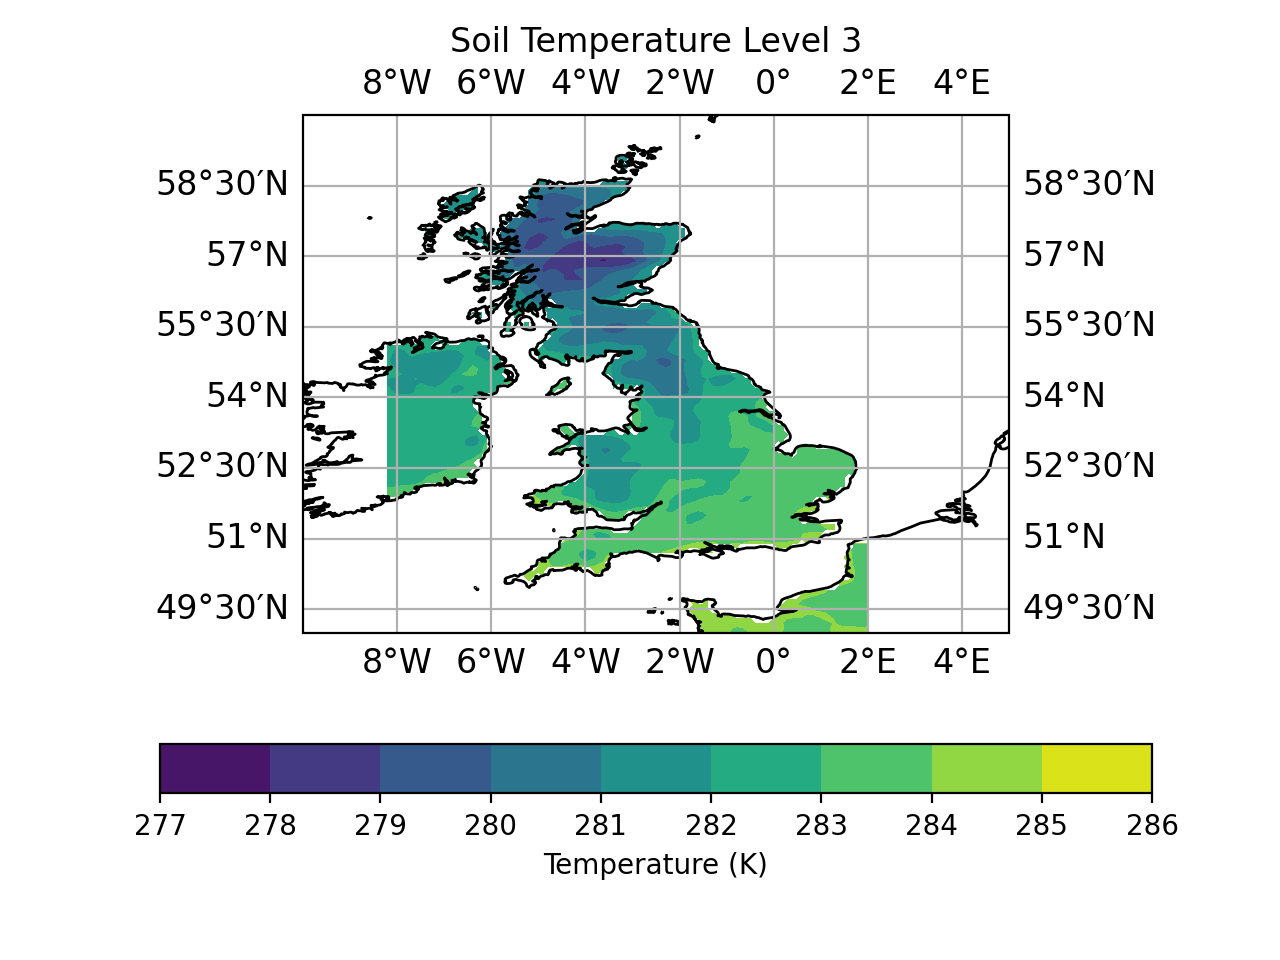

In [25]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.stl3.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Soil Temperature Level 3')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Temperature (K)")

plt.show()

<IPython.core.display.Javascript object>


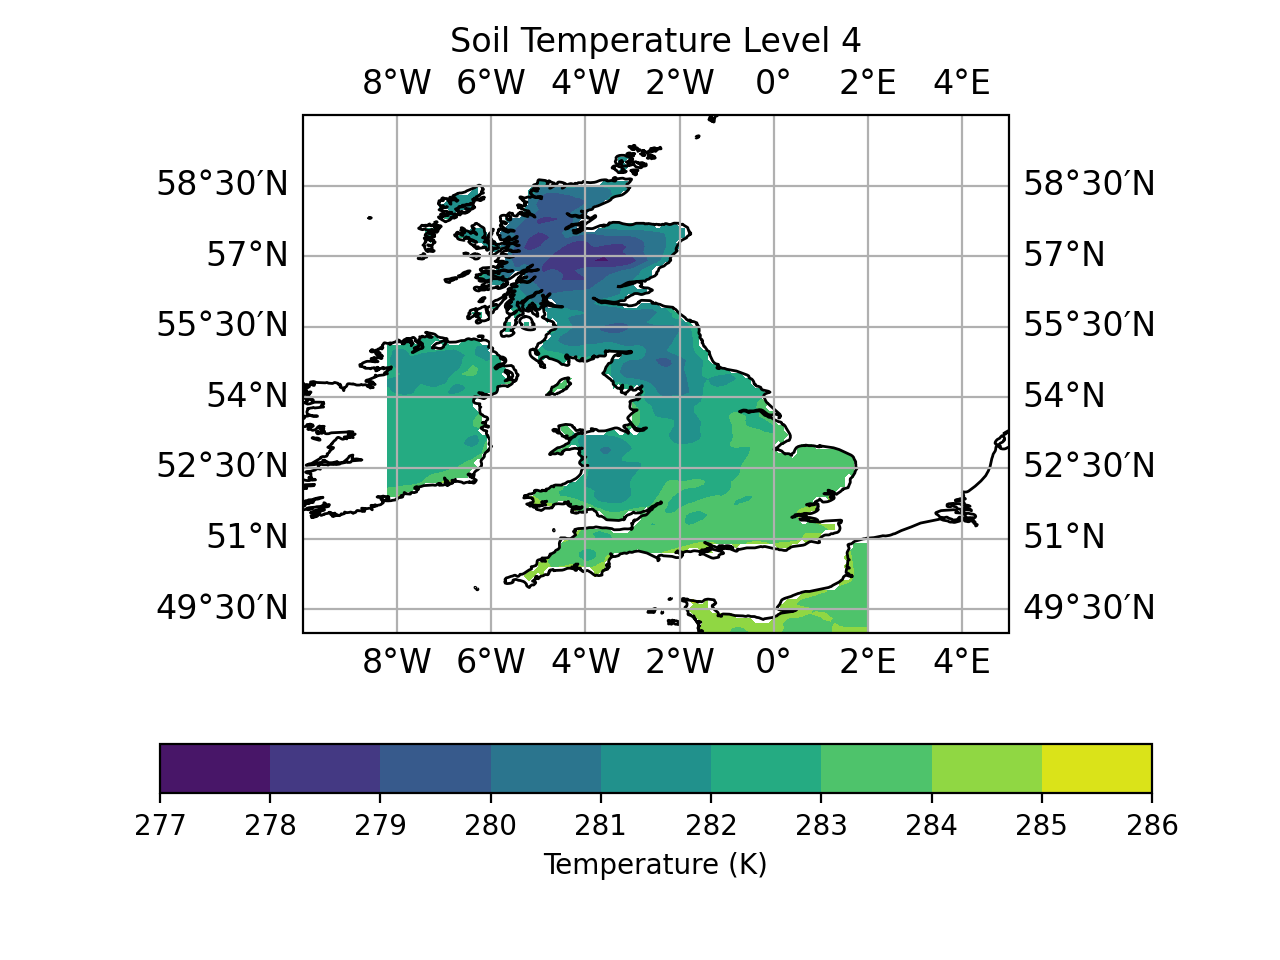

In [26]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.stl4.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Soil Temperature Level 4')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Temperature (K)")

plt.show()

<IPython.core.display.Javascript object>


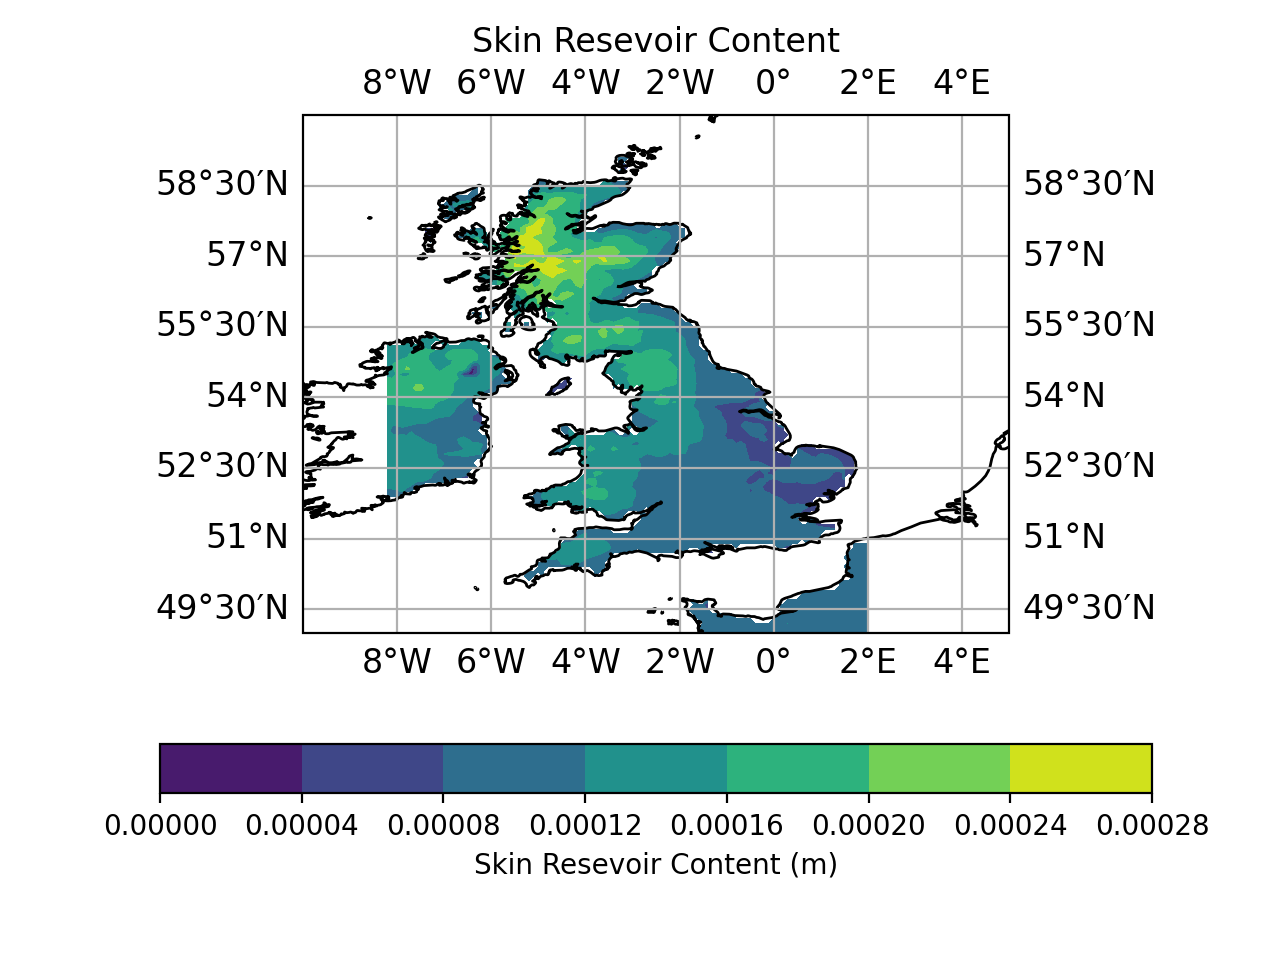

In [27]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.src.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Skin Resevoir Content')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Skin Resevoir Content (m)")

plt.show()

<IPython.core.display.Javascript object>


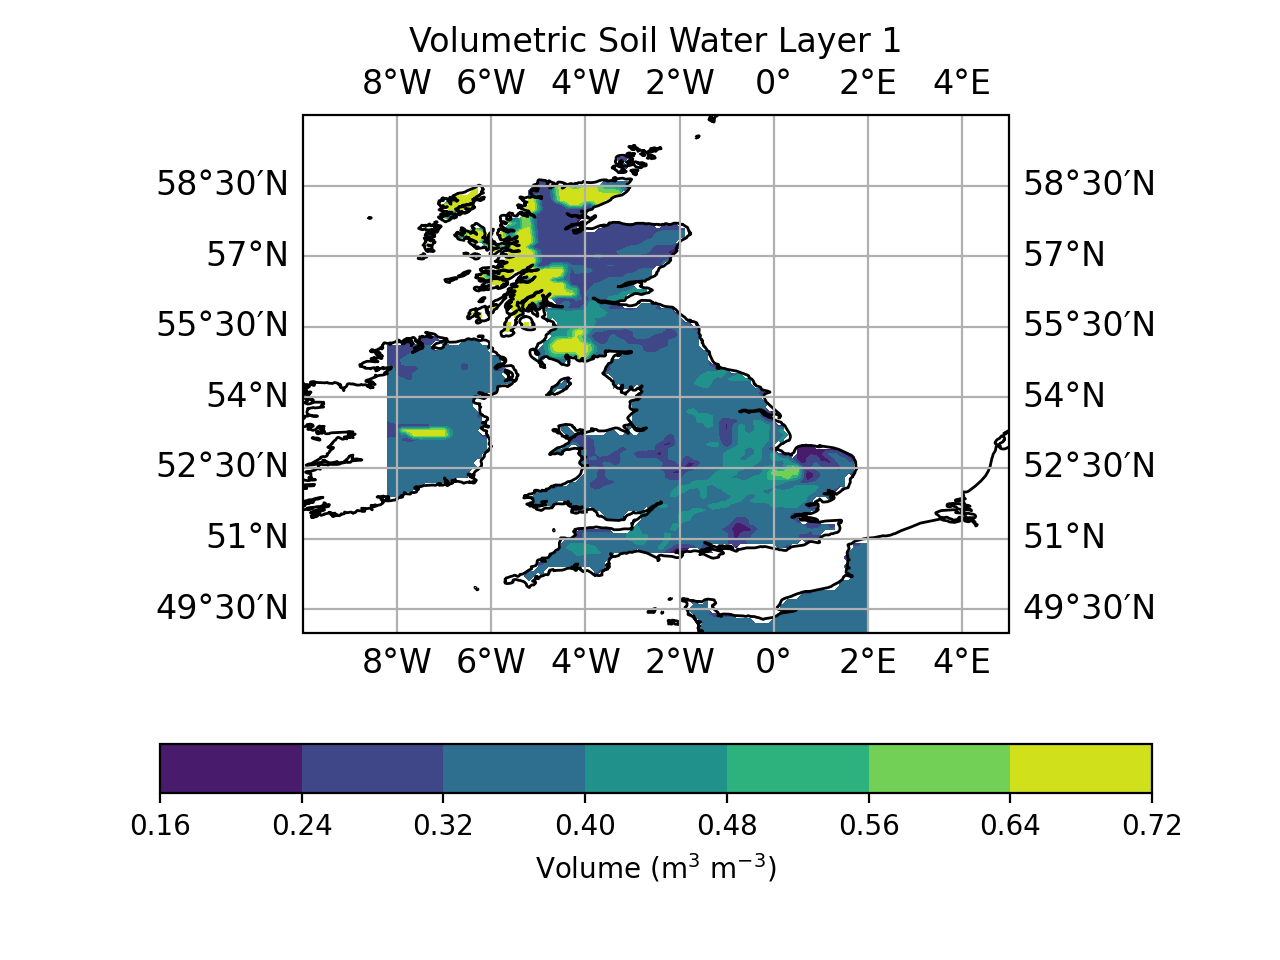

In [28]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.swvl1.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Volumetric Soil Water Layer 1')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Volume (m$^3$ m$^{-3}$)")

plt.show()

<IPython.core.display.Javascript object>


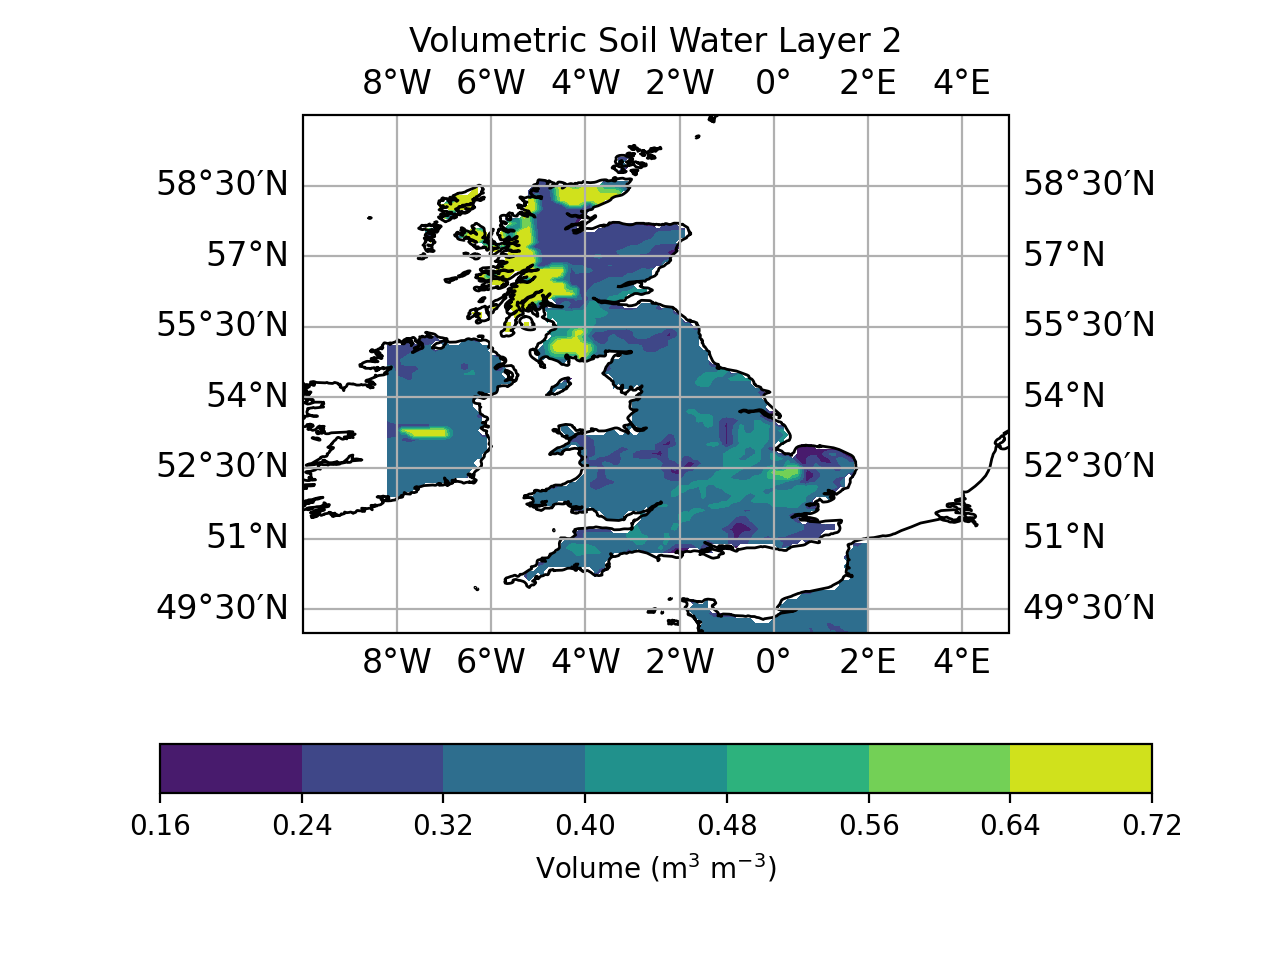

In [29]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.swvl2.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Volumetric Soil Water Layer 2')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Volume (m$^3$ m$^{-3}$)")

plt.show()

<IPython.core.display.Javascript object>


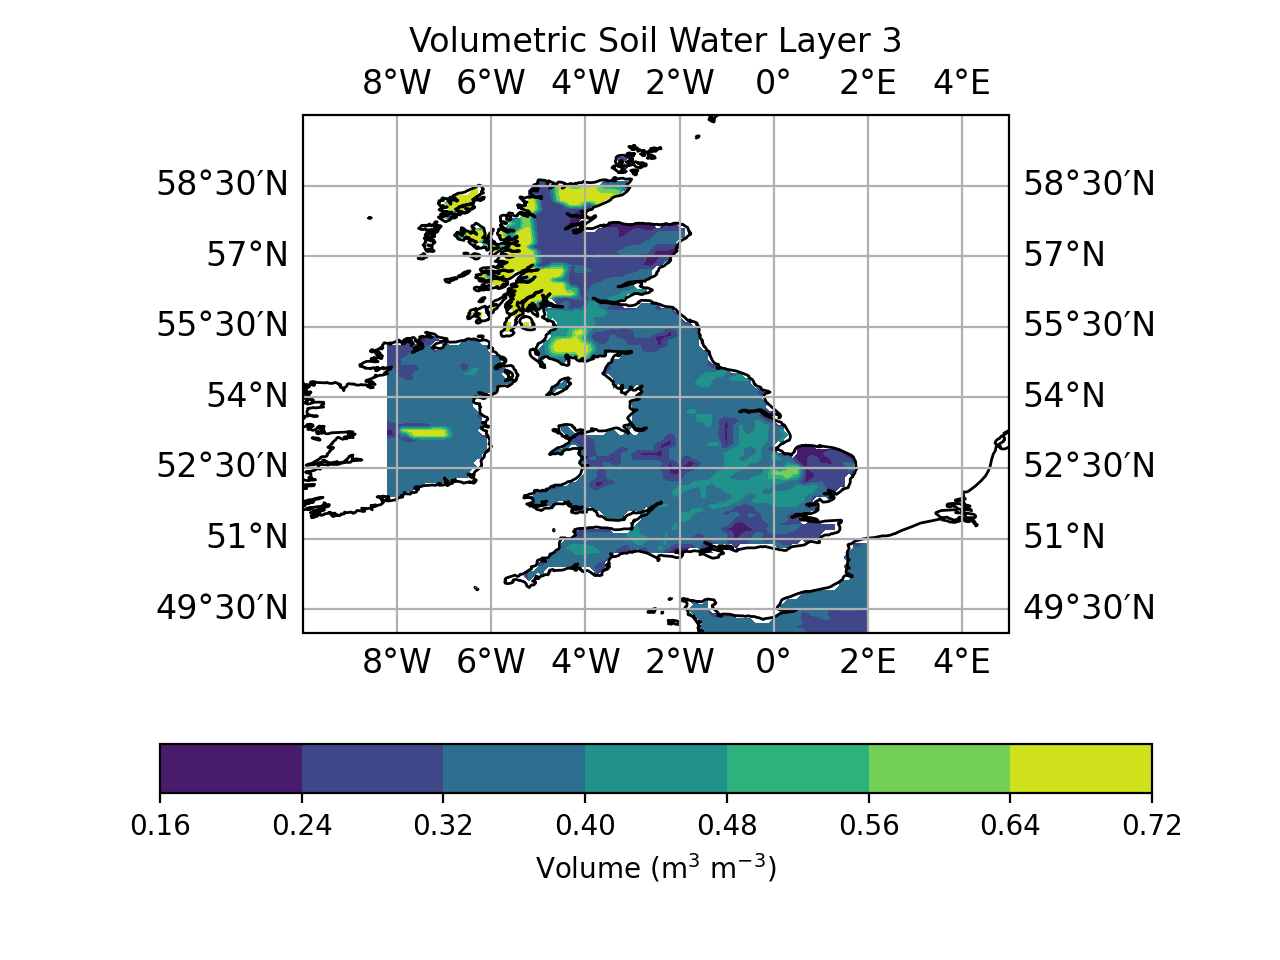

In [30]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.swvl3.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Volumetric Soil Water Layer 3')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Volume (m$^3$ m$^{-3}$)")

plt.show()

<IPython.core.display.Javascript object>


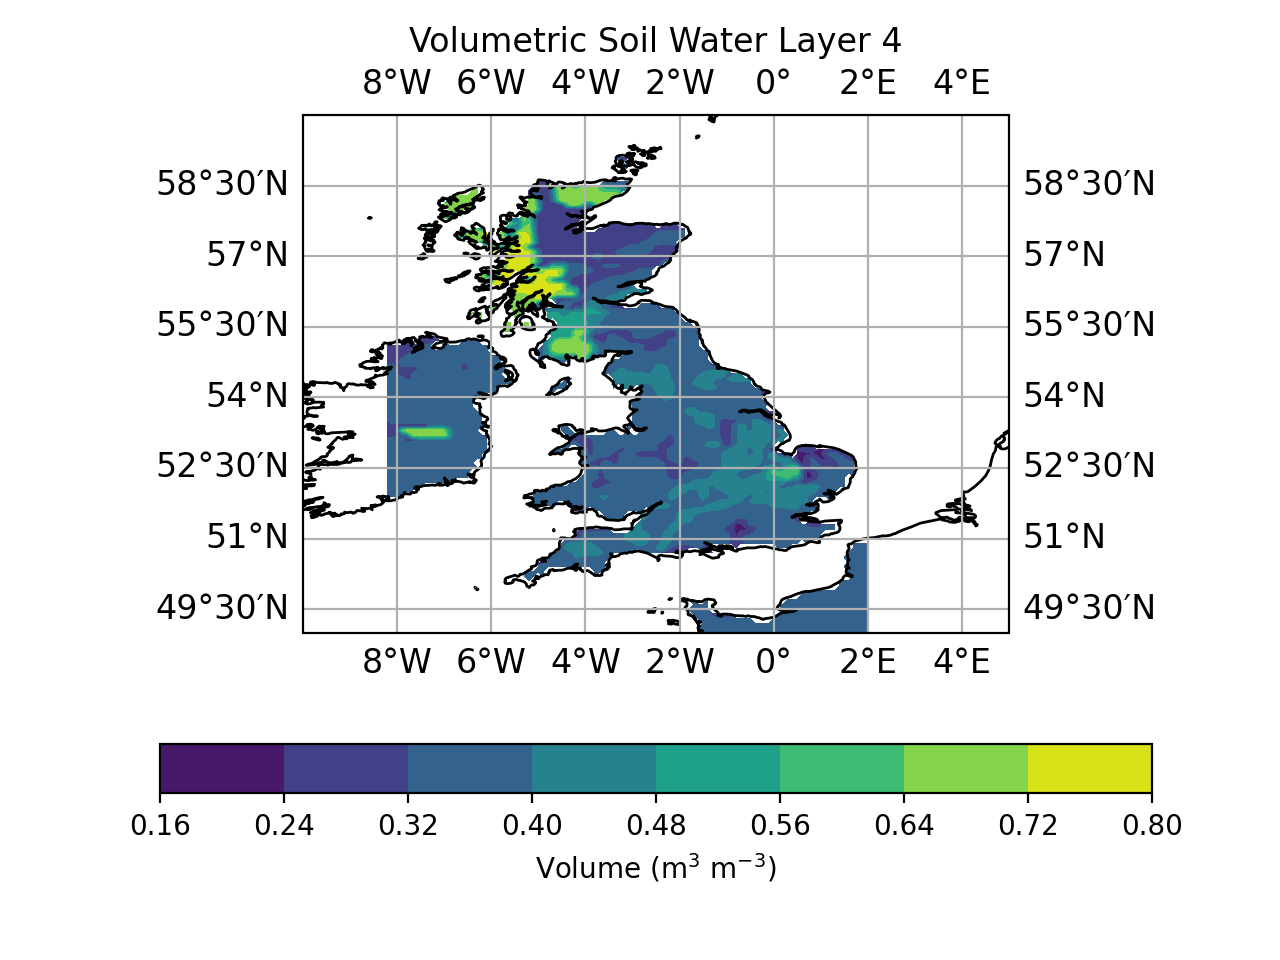

In [31]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.swvl4.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Volumetric Soil Water Layer 4')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Volume (m$^3$ m$^{-3}$)")

plt.show()

<IPython.core.display.Javascript object>


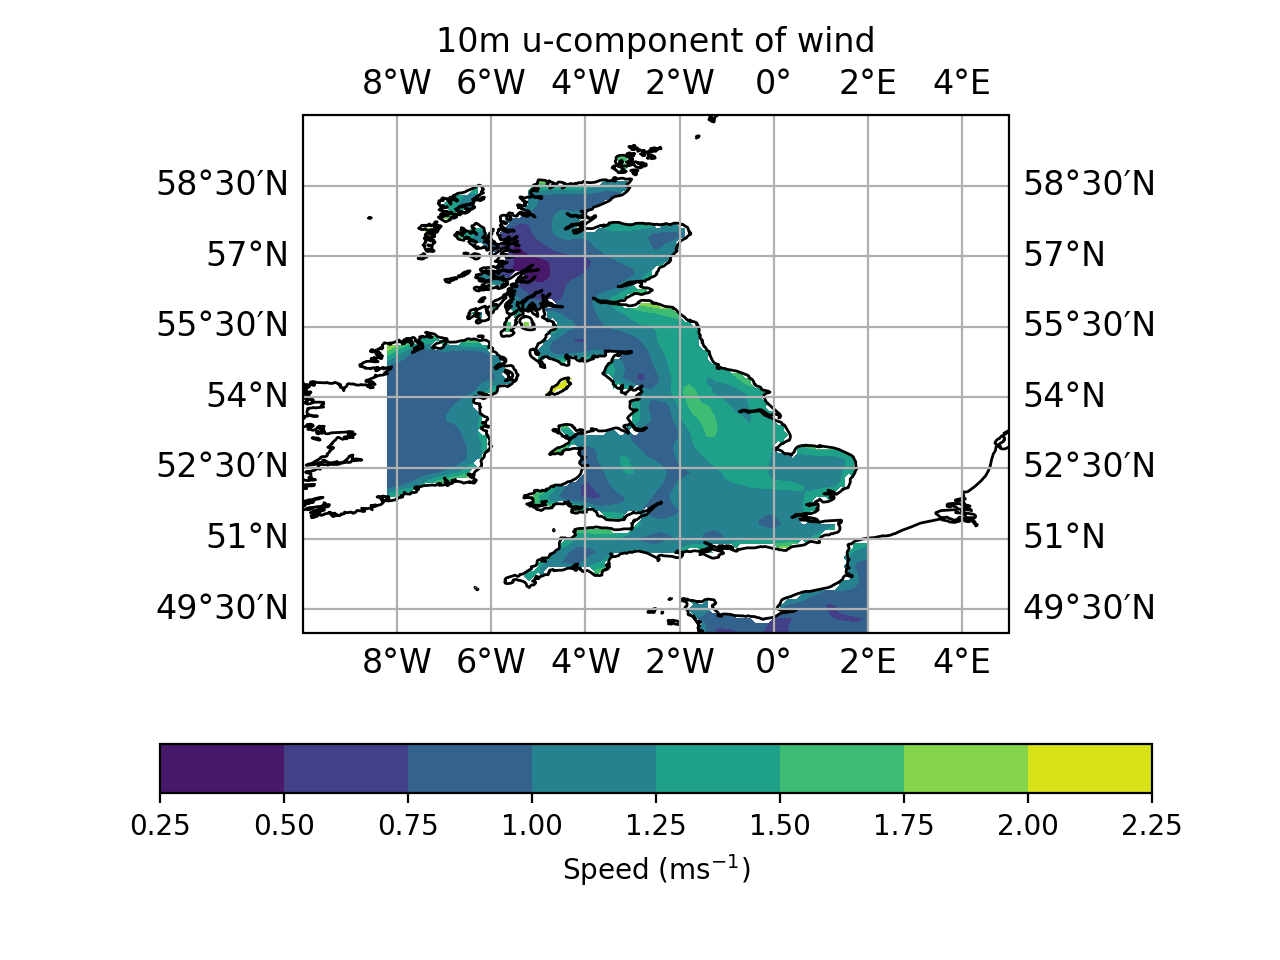

In [32]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.u10.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('10m u-component of wind')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Speed (ms$^{-1}$)")

plt.show()

<IPython.core.display.Javascript object>


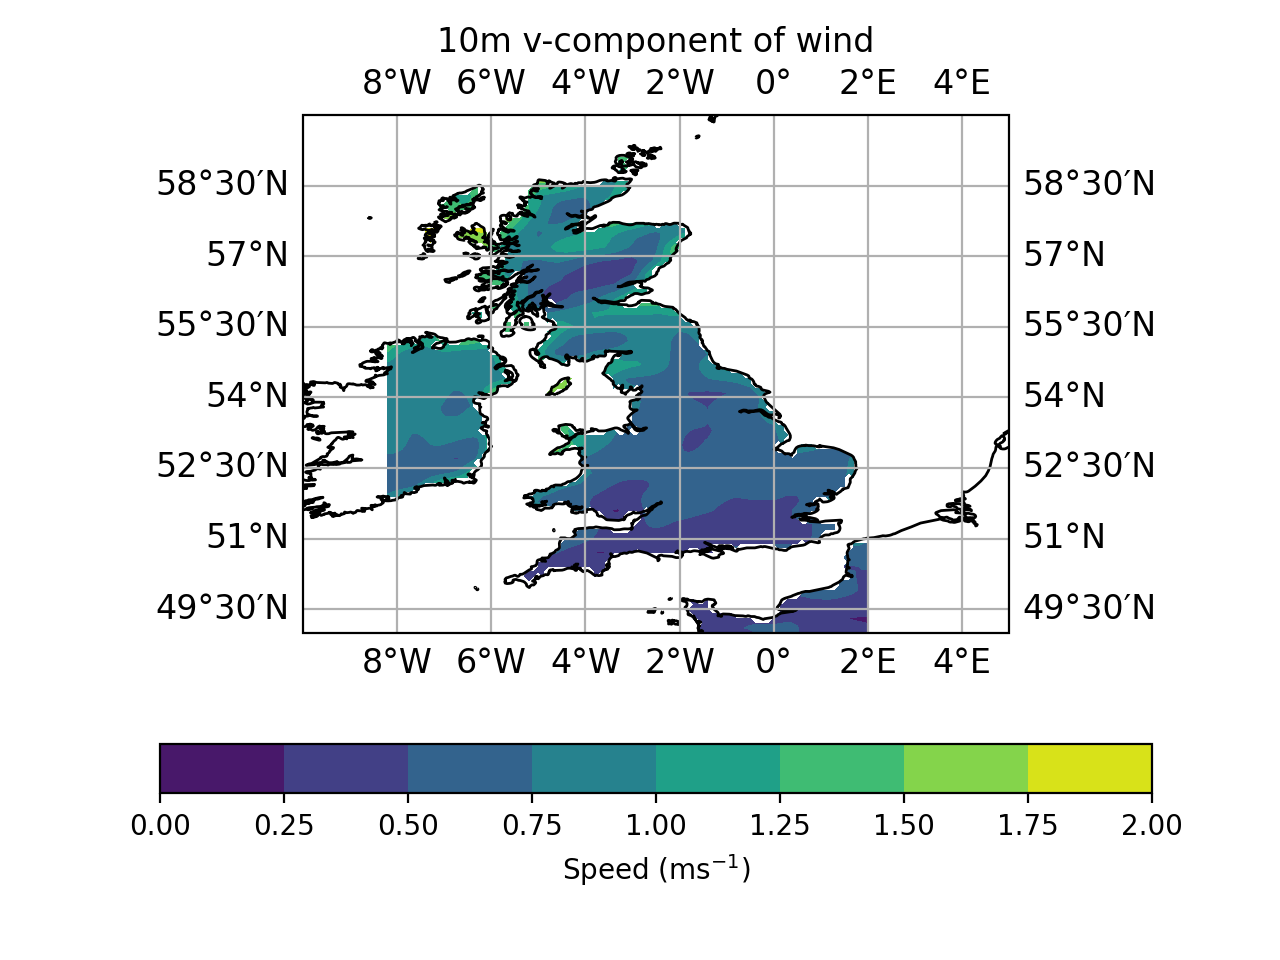

In [33]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.v10.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('10m v-component of wind')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Speed (ms$^{-1}$)")

plt.show()

<IPython.core.display.Javascript object>


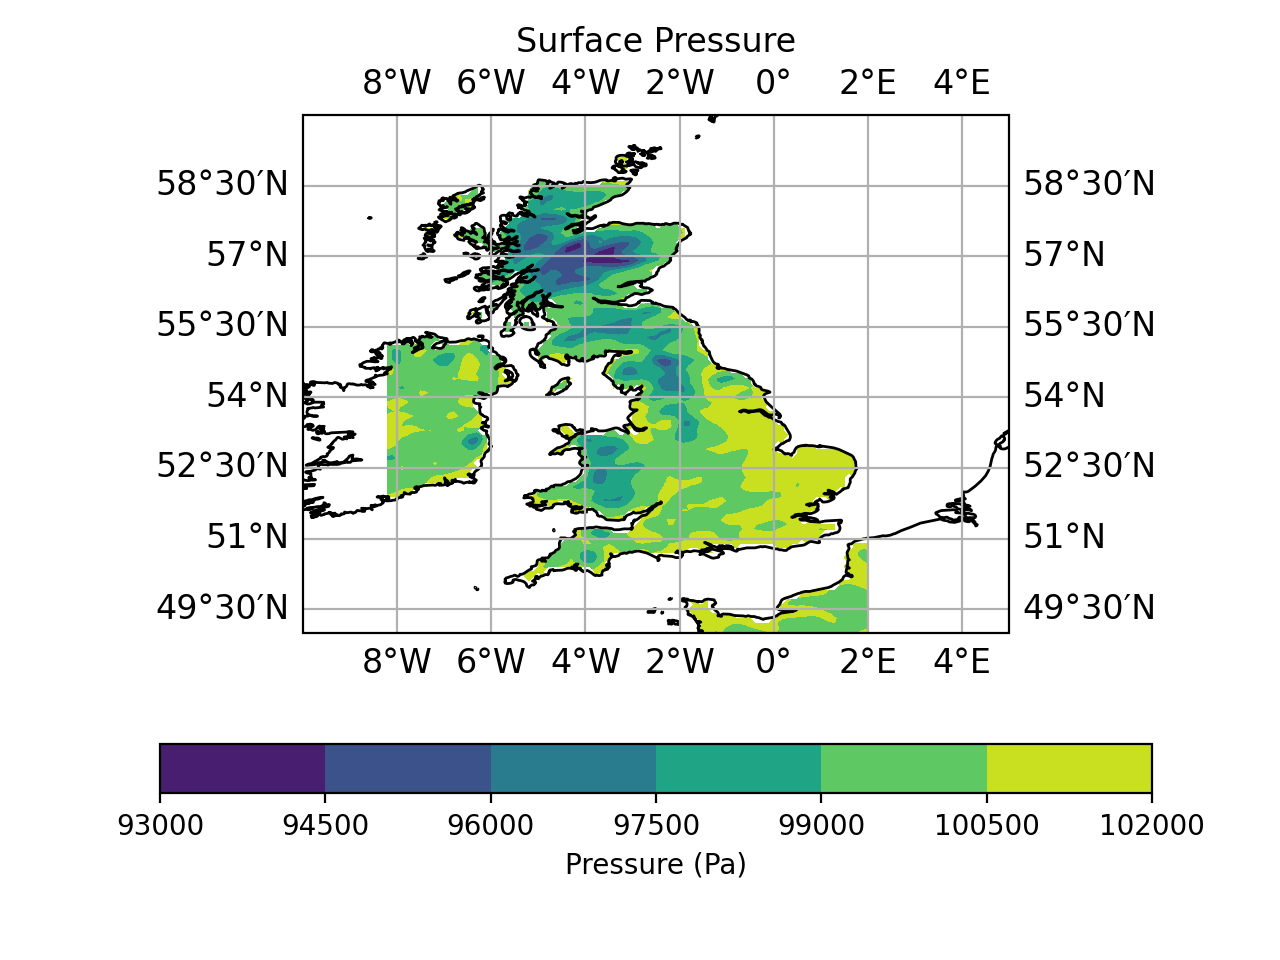

In [34]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.sp.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Surface Pressure')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Pressure (Pa)")

plt.show()

<IPython.core.display.Javascript object>


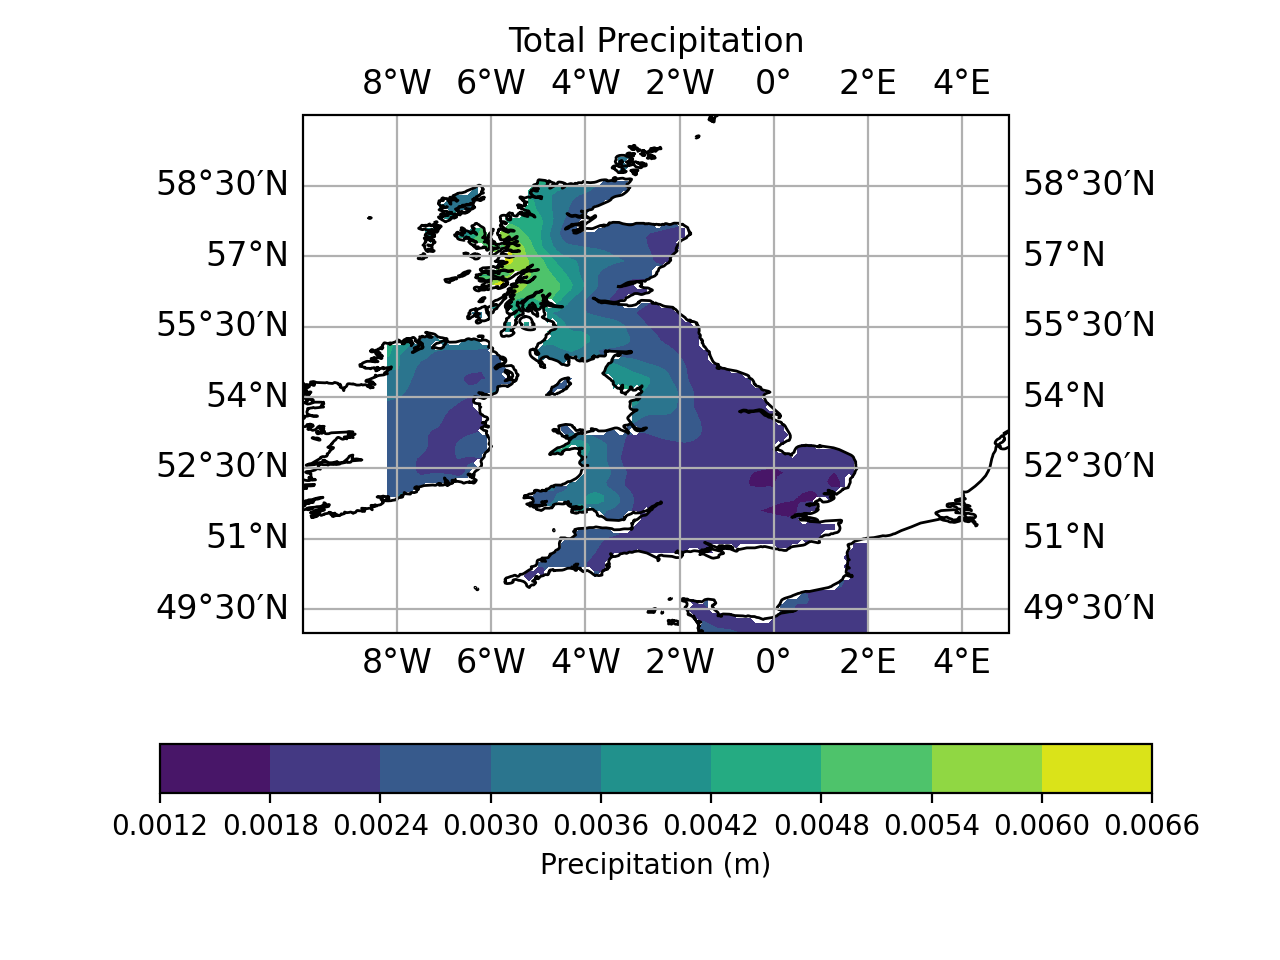

In [35]:
lons = data.variables['longitude'][:]
lats = data.variables['latitude'][:]

data_all_months = data.tp.values
mean_temp = np.mean(data_all_months, axis=0)

plt.figure()


ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([-10, 5, 49, 60])
ax.set_title('Total Precipitation')


ax.coastlines(resolution='10m', color='black')
ax.gridlines(draw_labels=True, dms=True)


contour = plt.contourf(lons, lats, mean_temp, cmap=plt.cm.viridis)


cbar = plt.colorbar(contour, orientation='horizontal')
cbar.set_label(u"Precipitation (m)")

plt.show()

## Plot for each variable 

1. 2m Dewpoint Temperature
2. 2m Temperature
3. Skin Temperature
4. Soil Temperature Level 1
5. Soil Temperature Level 2
6. Soil Temperature Level 3
7. Soil Temperature Level 4
8. Skin Resevoir Content
9. Volumetric Soil Water Layer 1
10. Volumetric Soil Water Layer 2
11. Volumetric Soil Water Layer 3
12. Volumetric Soil Water Layer 4
13. 10m u-component of wind
14. 10m v-component of wind
15. Surface Pressure
16. Total Precipitation

Slope: 0.01247 ± 0.00005 K per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



/Users/anvijoy/anaconda3/lib/python3.10/site-packages/skimage/measure/block.py:94: RuntimeWarning: Mean of empty slice
  return func(blocked, axis=tuple(range(image.ndim, blocked.ndim)), **func_kwargs)


<IPython.core.display.Javascript object>


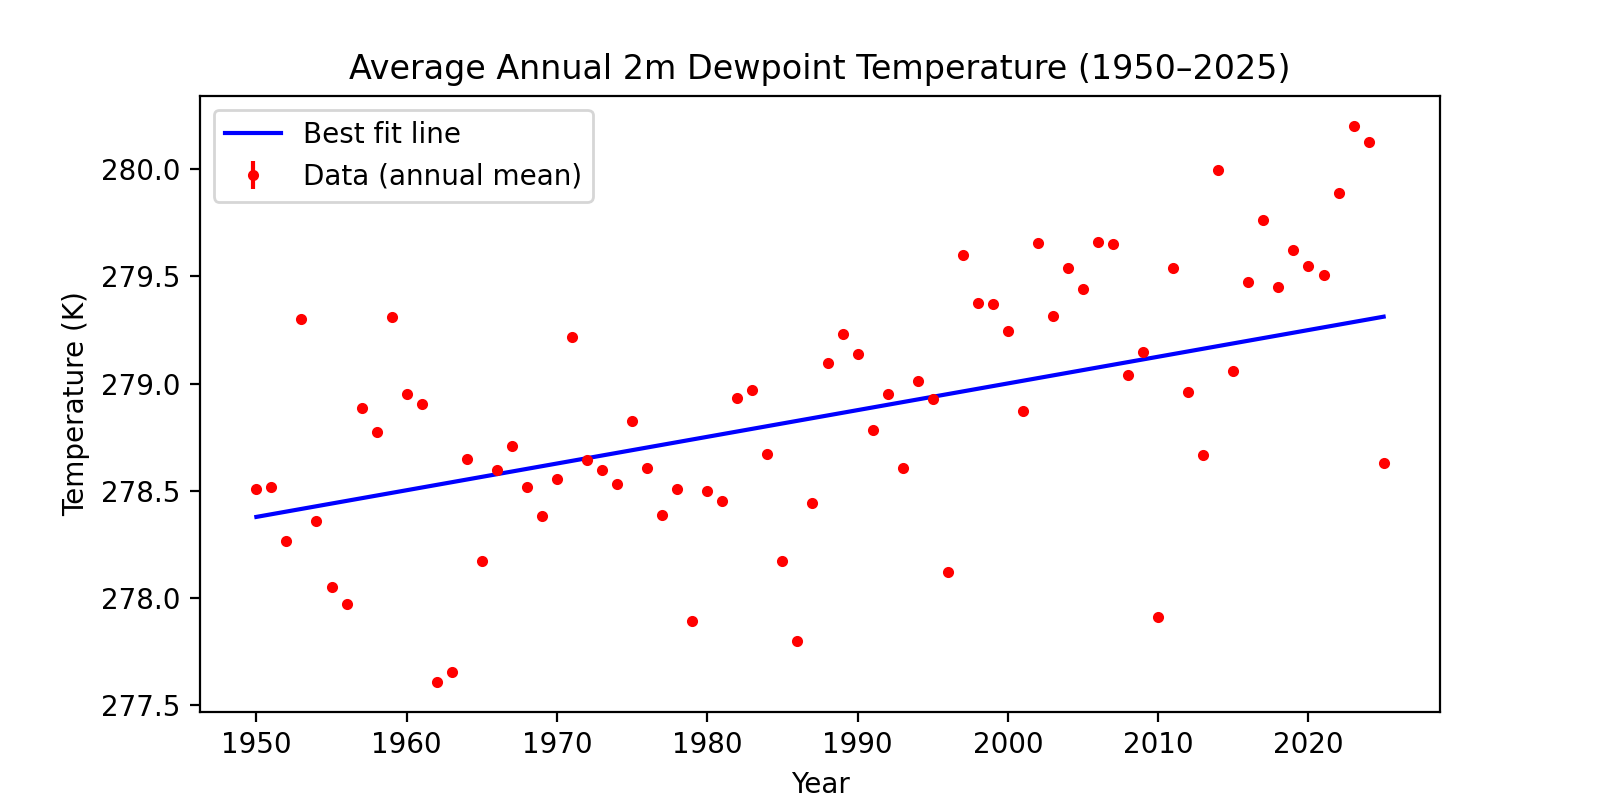

In [36]:
from skimage.measure import block_reduce
from scipy.optimize import curve_fit


data_all_months = data.d2m.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} K per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.title('Average Annual 2m Dewpoint Temperature (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()


Slope: 0.01060 ± 0.00006 K per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


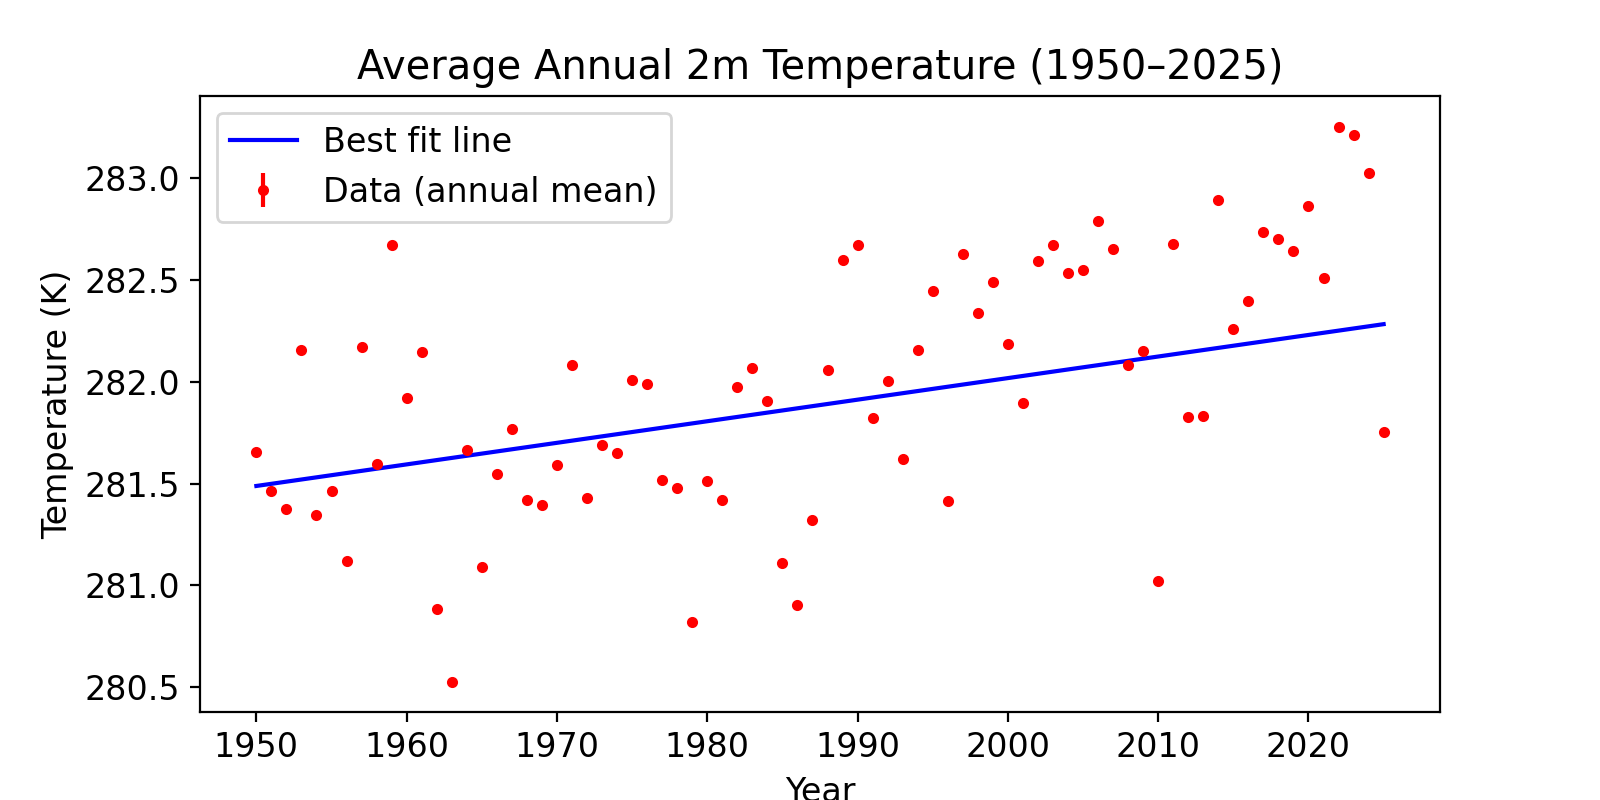

In [37]:
data_all_months = data.t2m.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} K per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.title('Average Annual 2m Temperature (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.01052 ± 0.00006 K per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



/var/folders/_l/wt96l_z540q0zcwsfngpk6t00000gq/T/ipykernel_54480/1117213331.py:31: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,4))


<IPython.core.display.Javascript object>


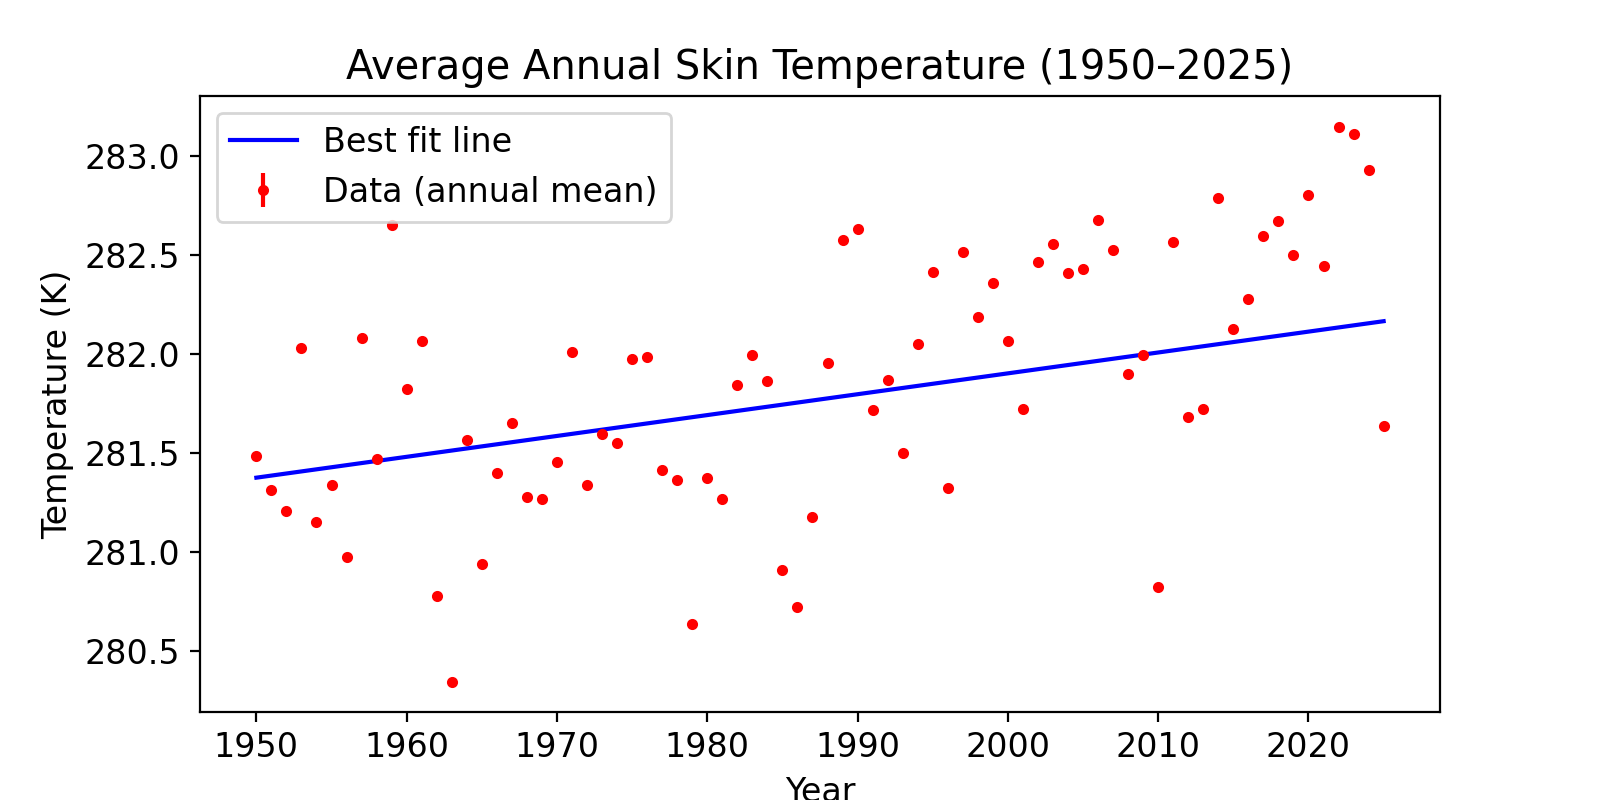

In [38]:
data_all_months = data.skt.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} K per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.title('Average Annual Skin Temperature (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()


Slope: 0.01028 ± 0.00006 K per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


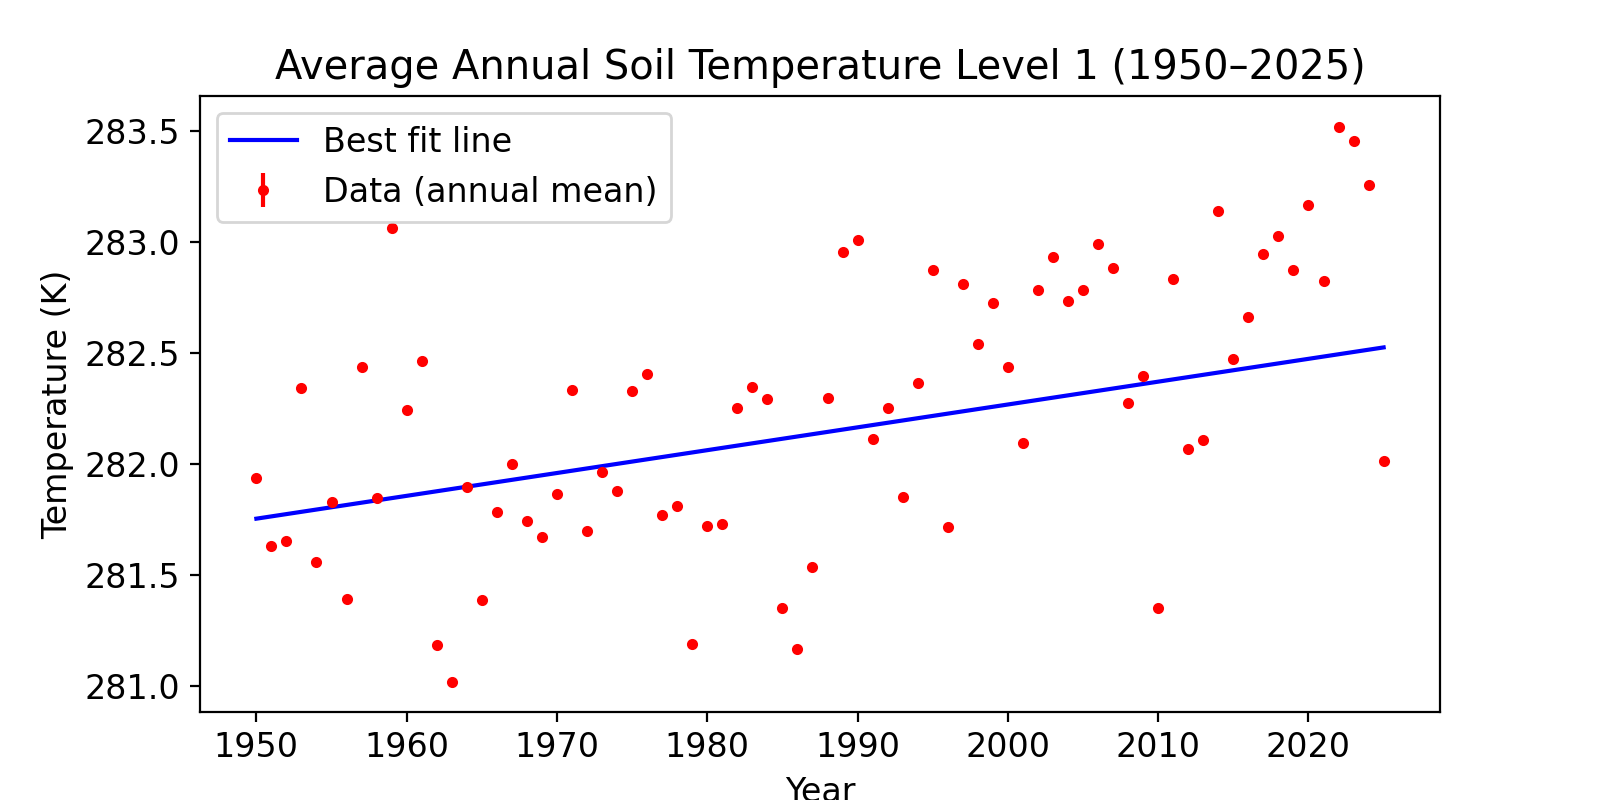

In [39]:
data_all_months = data.stl1.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} K per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.title('Average Annual Soil Temperature Level 1 (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.01046 ± 0.00006 K per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


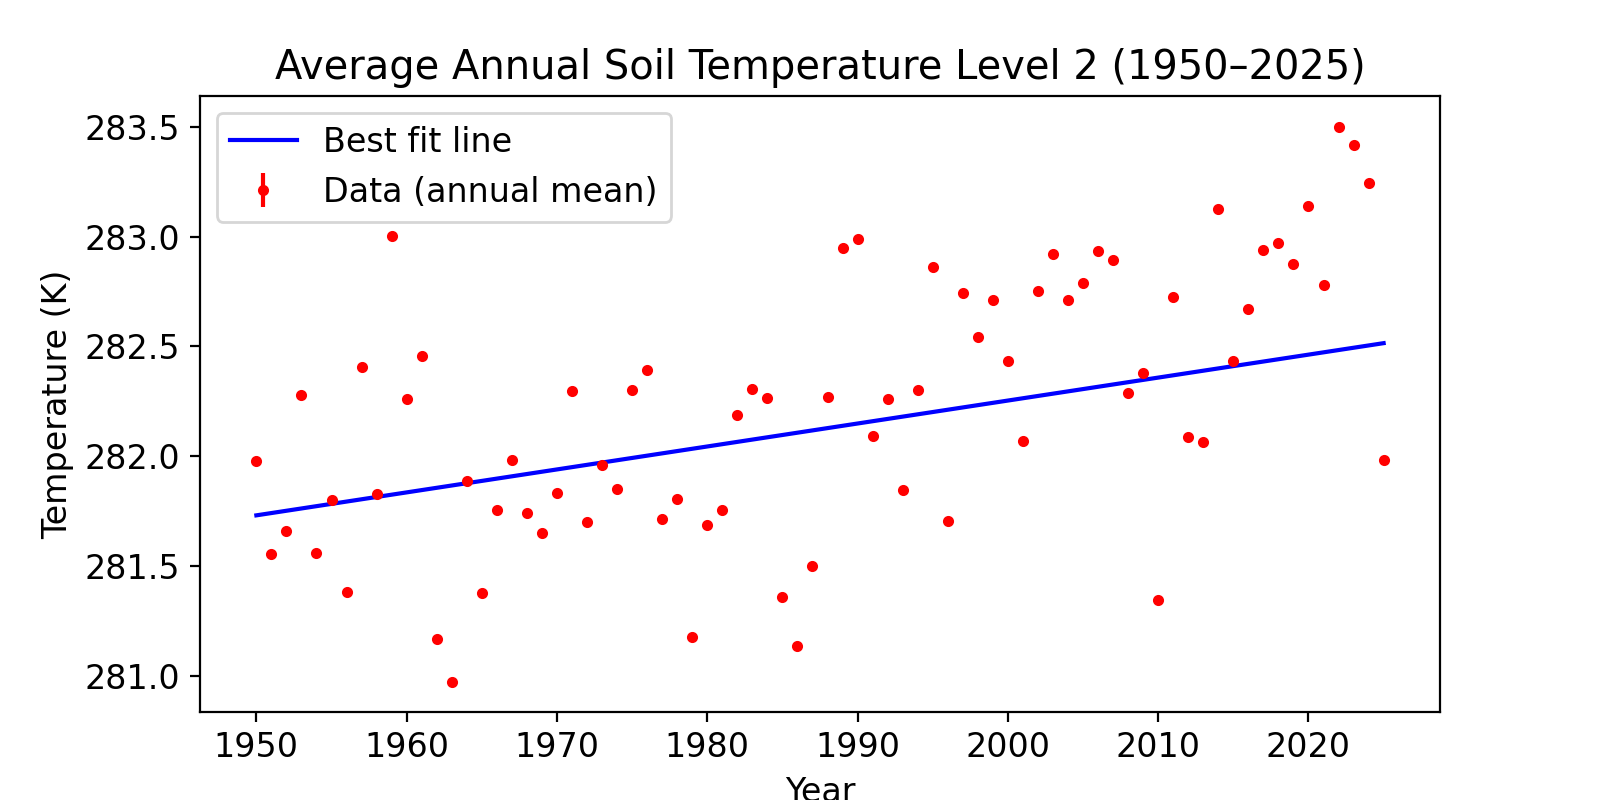

In [40]:
data_all_months = data.stl2.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} K per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.title('Average Annual Soil Temperature Level 2 (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.01075 ± 0.00006 K per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


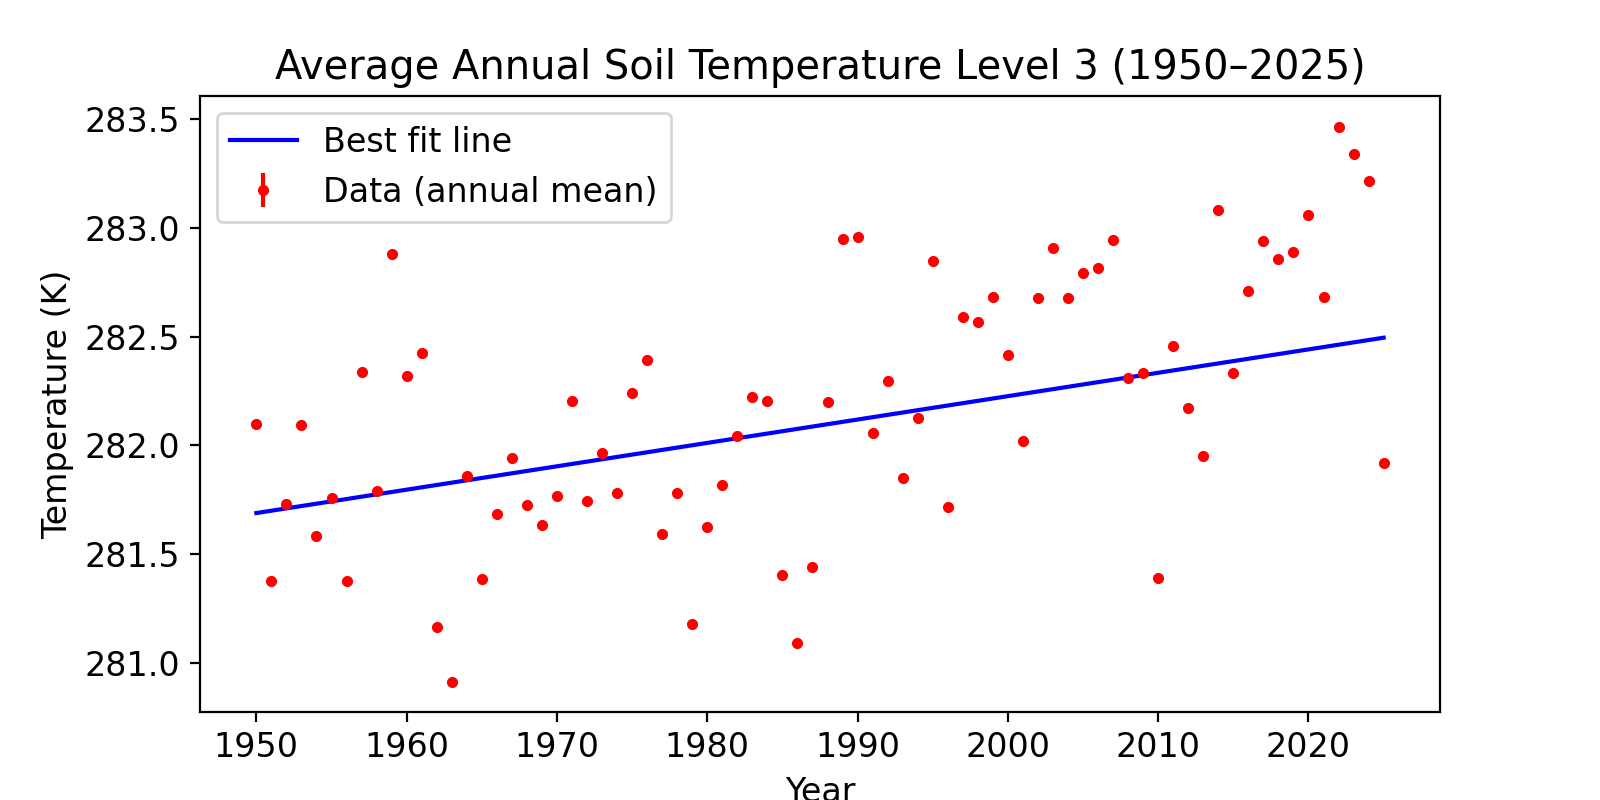

In [41]:
data_all_months = data.stl3.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} K per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.title('Average Annual Soil Temperature Level 3 (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.01061 ± 0.00006 K per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


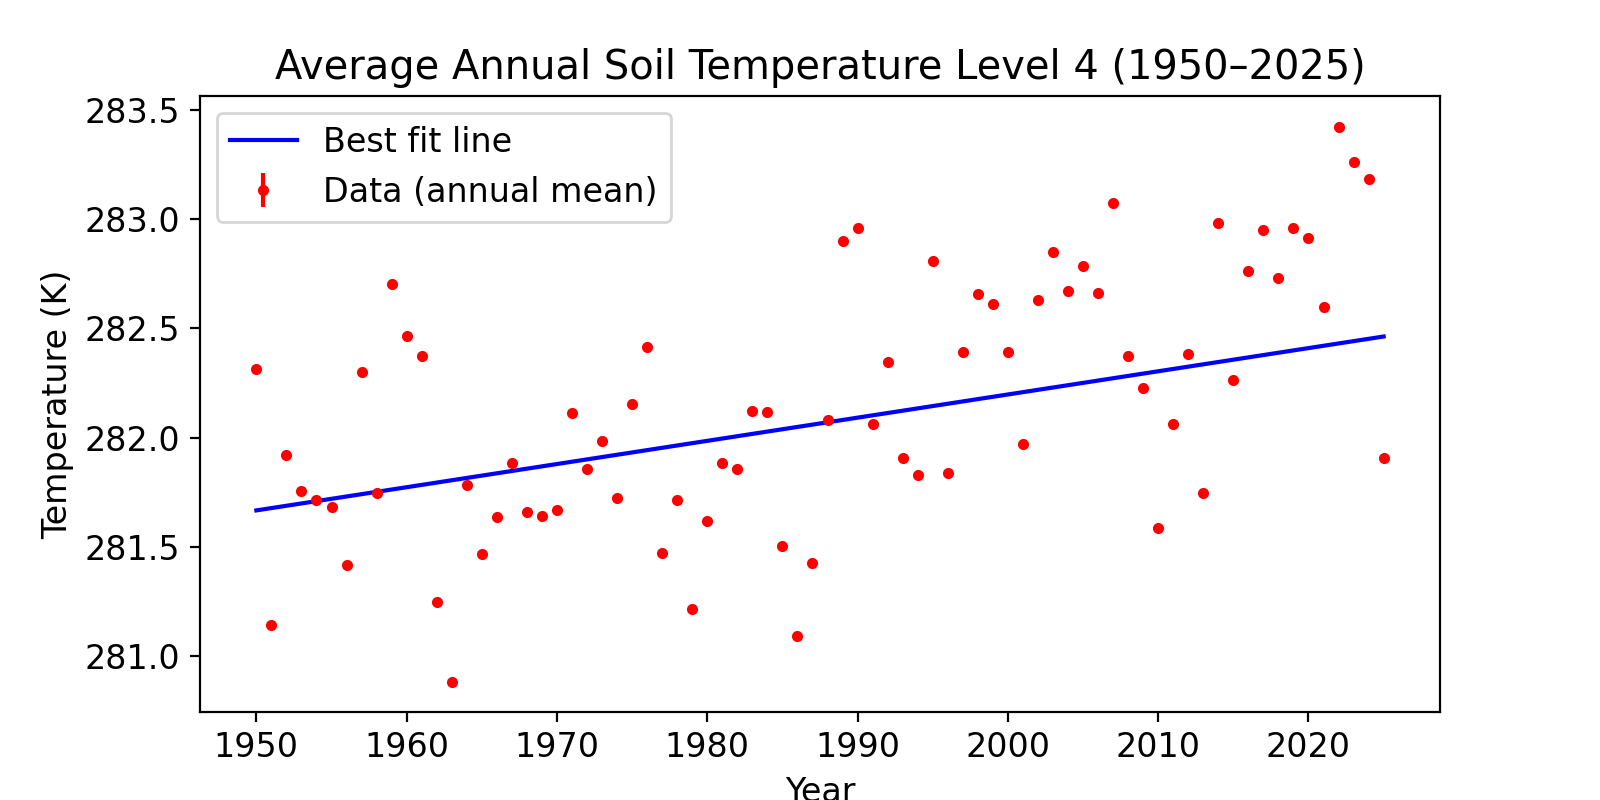

In [42]:
data_all_months = data.stl4.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} K per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.title('Average Annual Soil Temperature Level 4 (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.00000 ± 0.00000 m per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


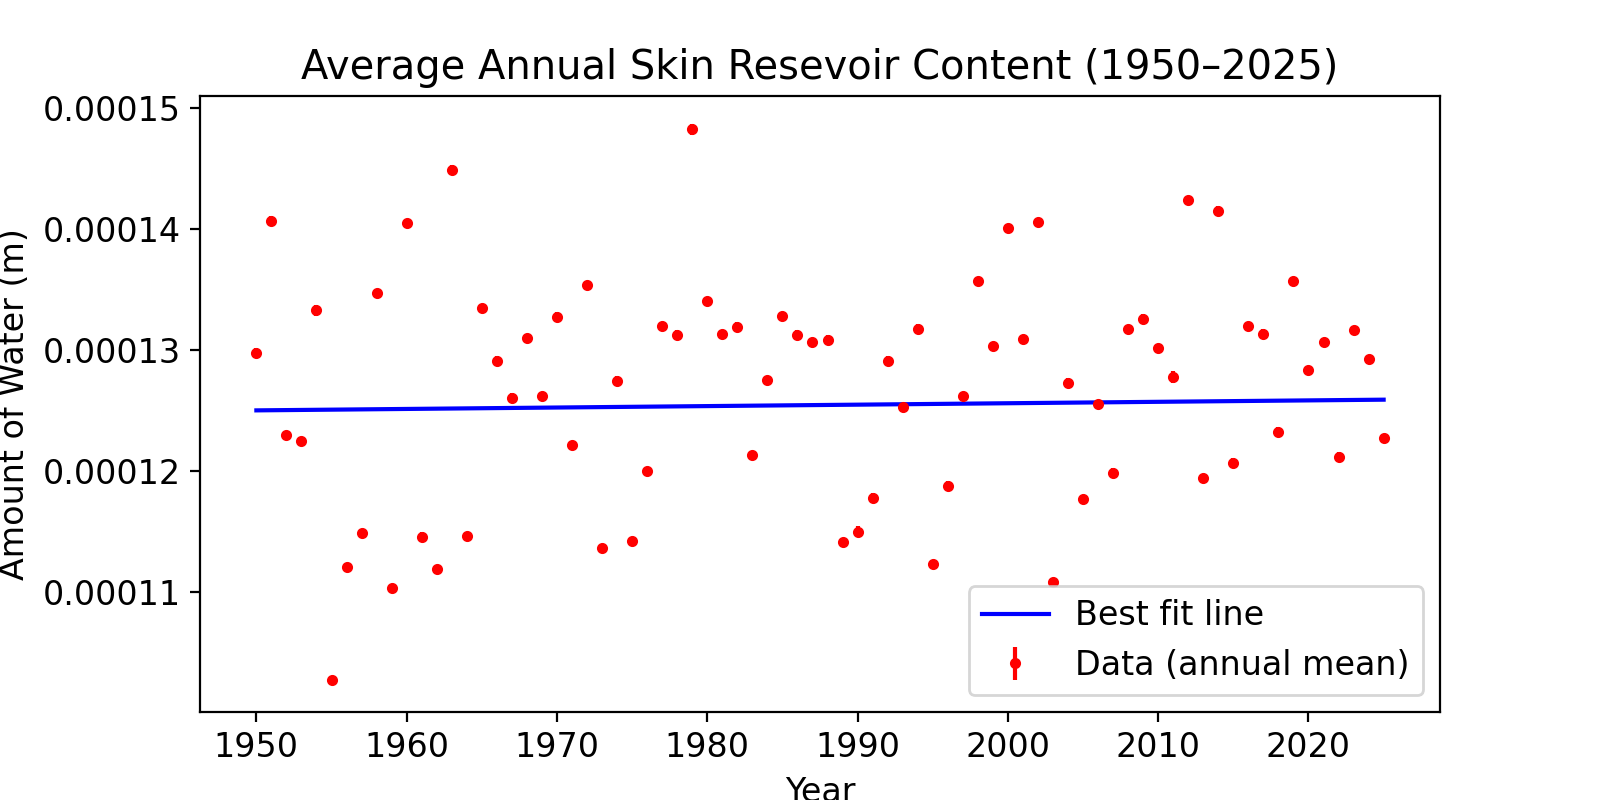

In [43]:
data_all_months = data.src.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} m per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Amount of Water (m)')
plt.title('Average Annual Skin Resevoir Content (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.00004 ± 0.00000 m$^3$ m$^-3$ per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


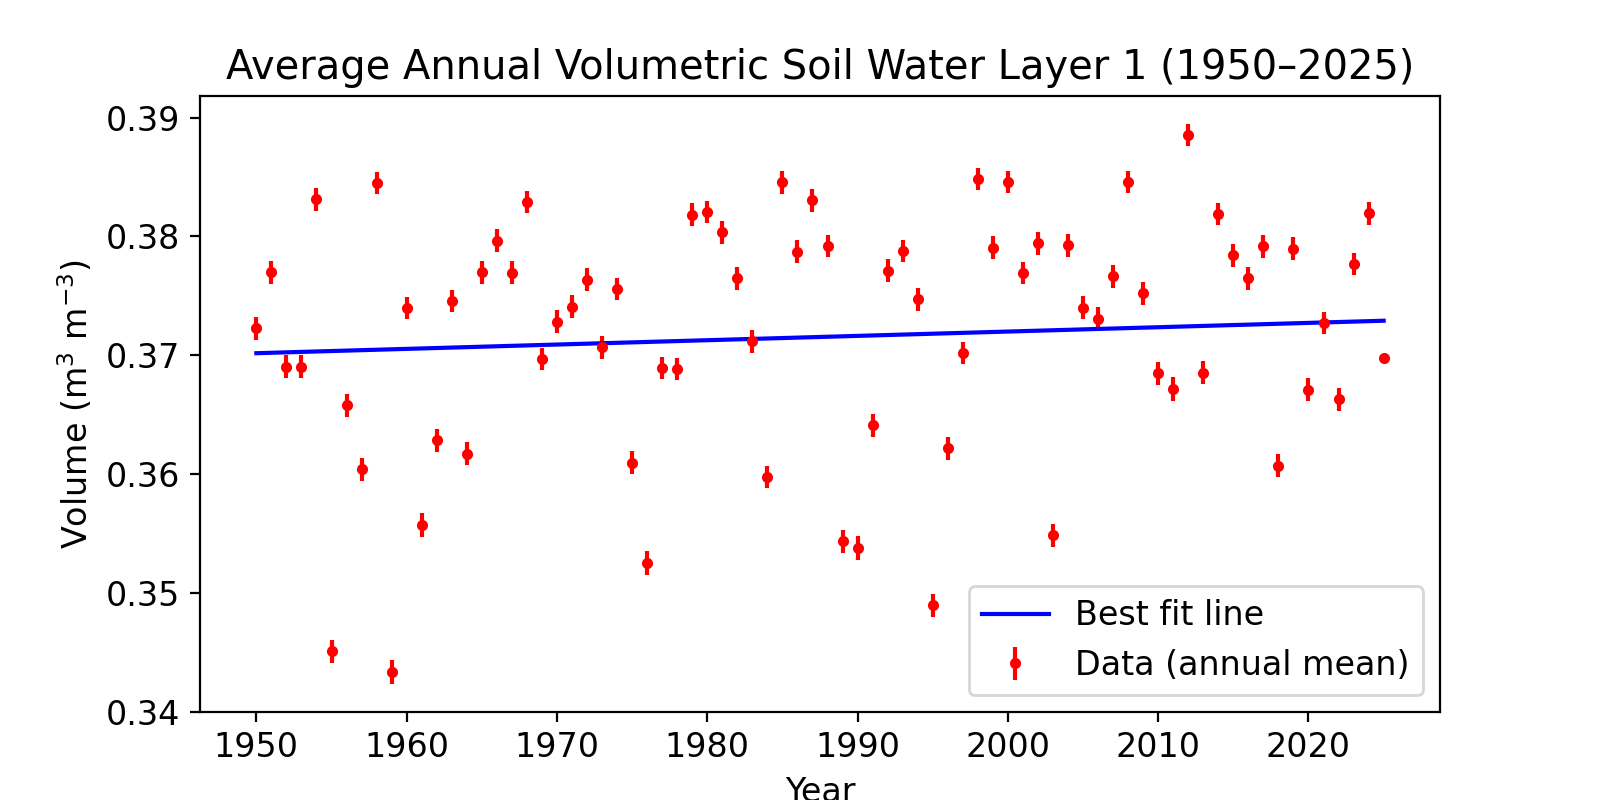

In [44]:
data_all_months = data.swvl1.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} m$^3$ m$^{-3}$ per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Volume (m$^3$ m$^{-3}$)')
plt.title('Average Annual Volumetric Soil Water Layer 1 (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.00005 ± 0.00000 m$^3$ m$^-3$ per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


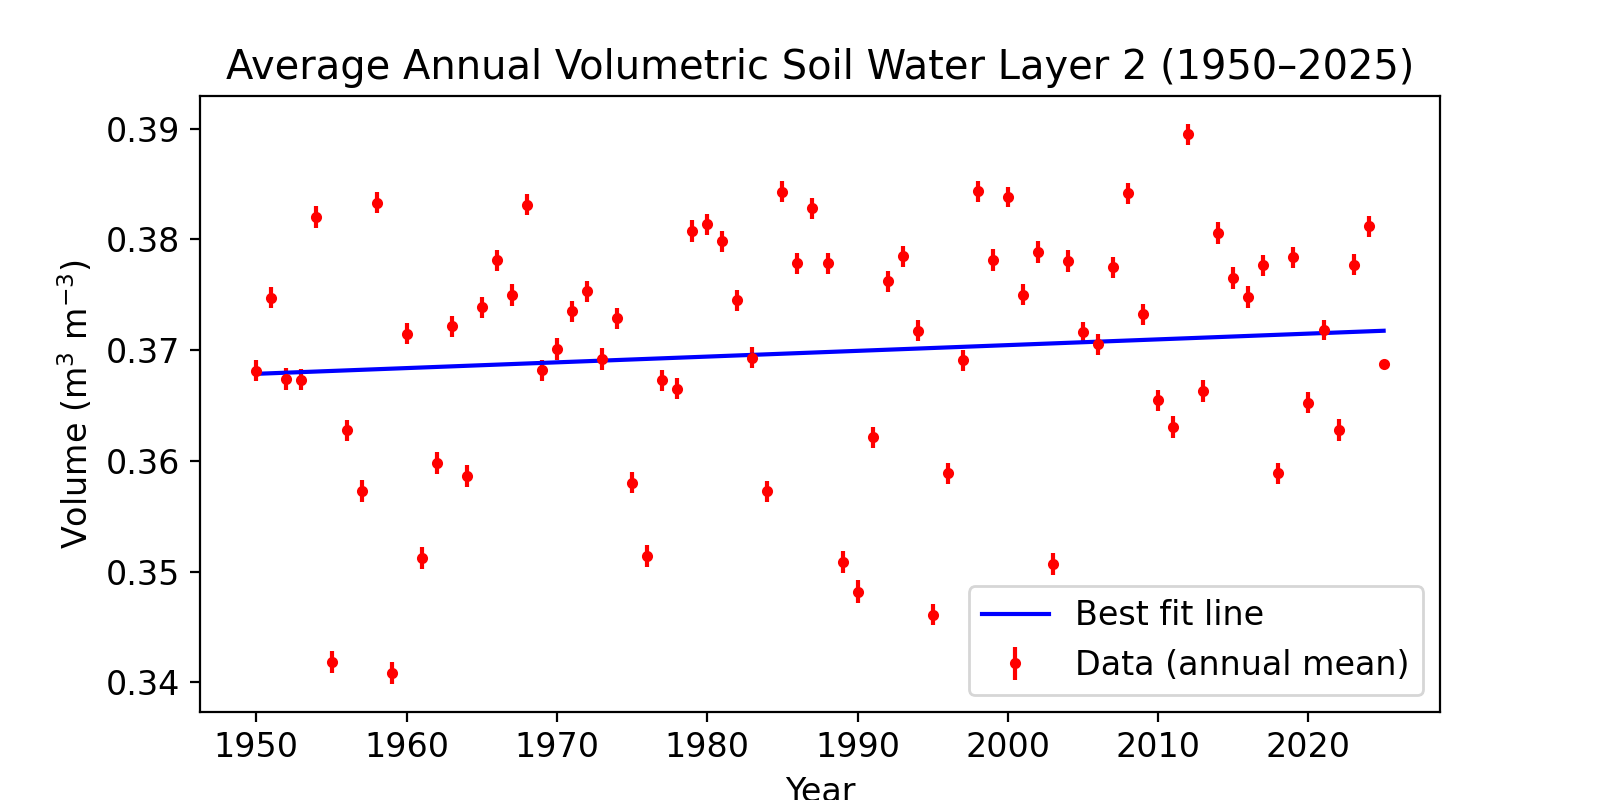

In [45]:
data_all_months = data.swvl2.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} m$^3$ m$^{-3}$ per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Volume (m$^3$ m$^{-3}$)')
plt.title('Average Annual Volumetric Soil Water Layer 2 (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.00007 ± 0.00000 m$^3$ m$^-3$ per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


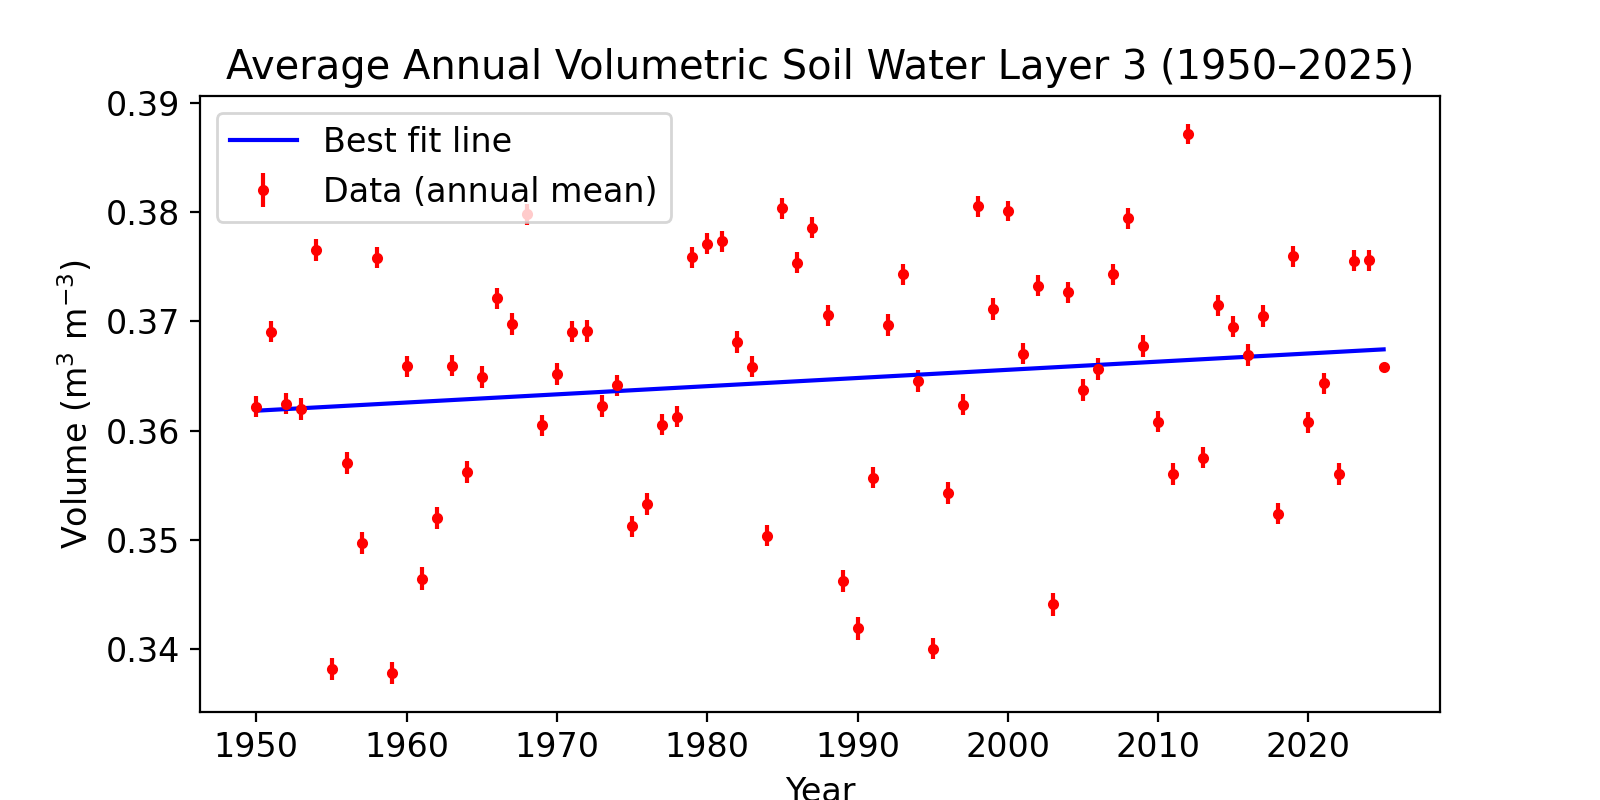

In [46]:
data_all_months = data.swvl3.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} m$^3$ m$^{-3}$ per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Volume (m$^3$ m$^{-3}$)')
plt.title('Average Annual Volumetric Soil Water Layer 3 (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.00011 ± 0.00000 m$^3$ m$^-3$ per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


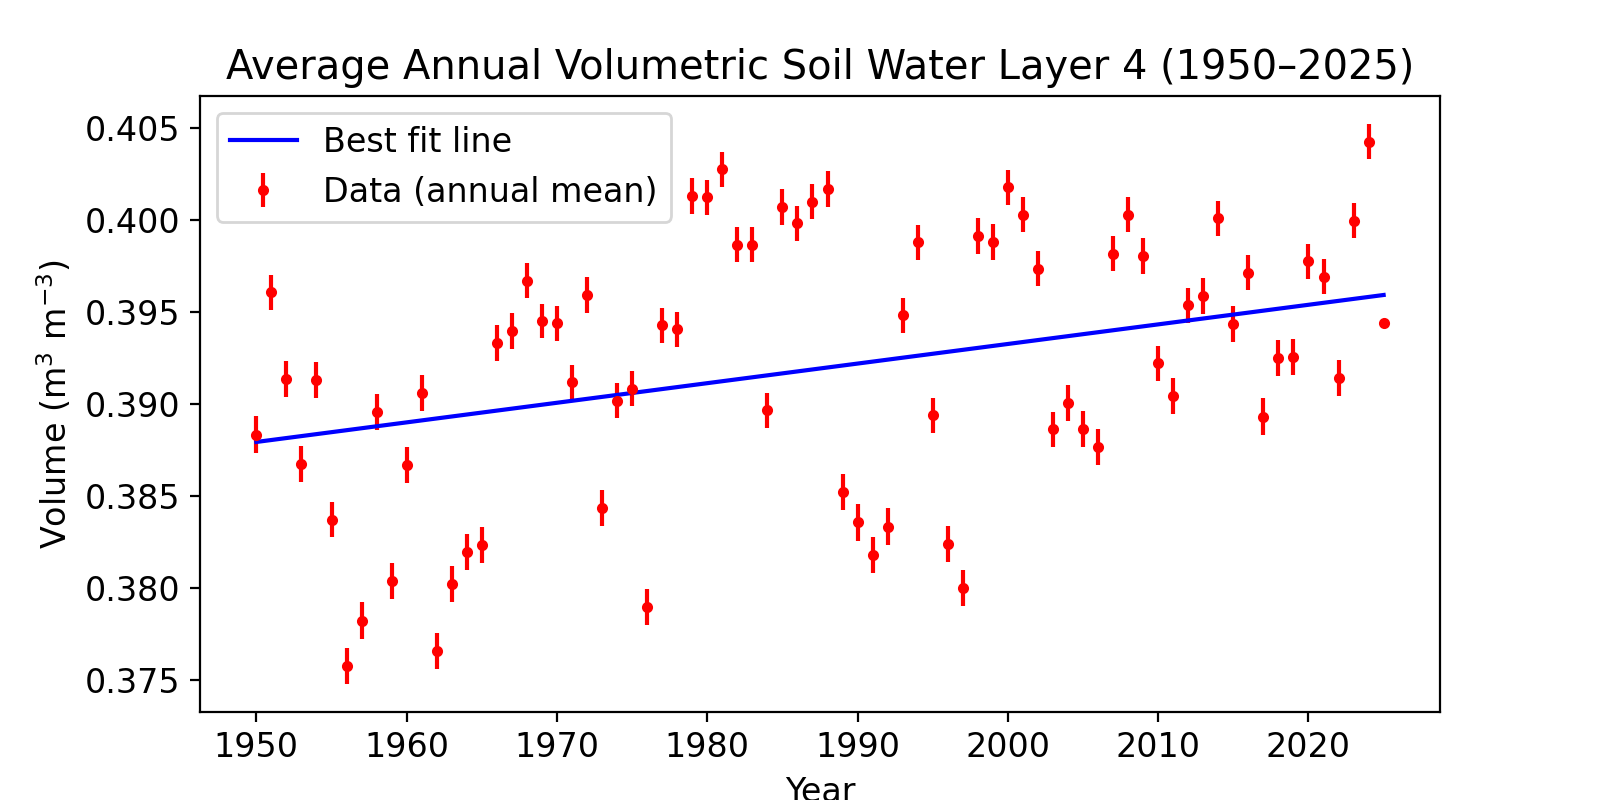

In [47]:
data_all_months = data.swvl4.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} m$^3$ m$^{-3}$ per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Volume (m$^3$ m$^{-3}$)')
plt.title('Average Annual Volumetric Soil Water Layer 4 (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.00169 ± 0.00001 ms$^-1$ per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


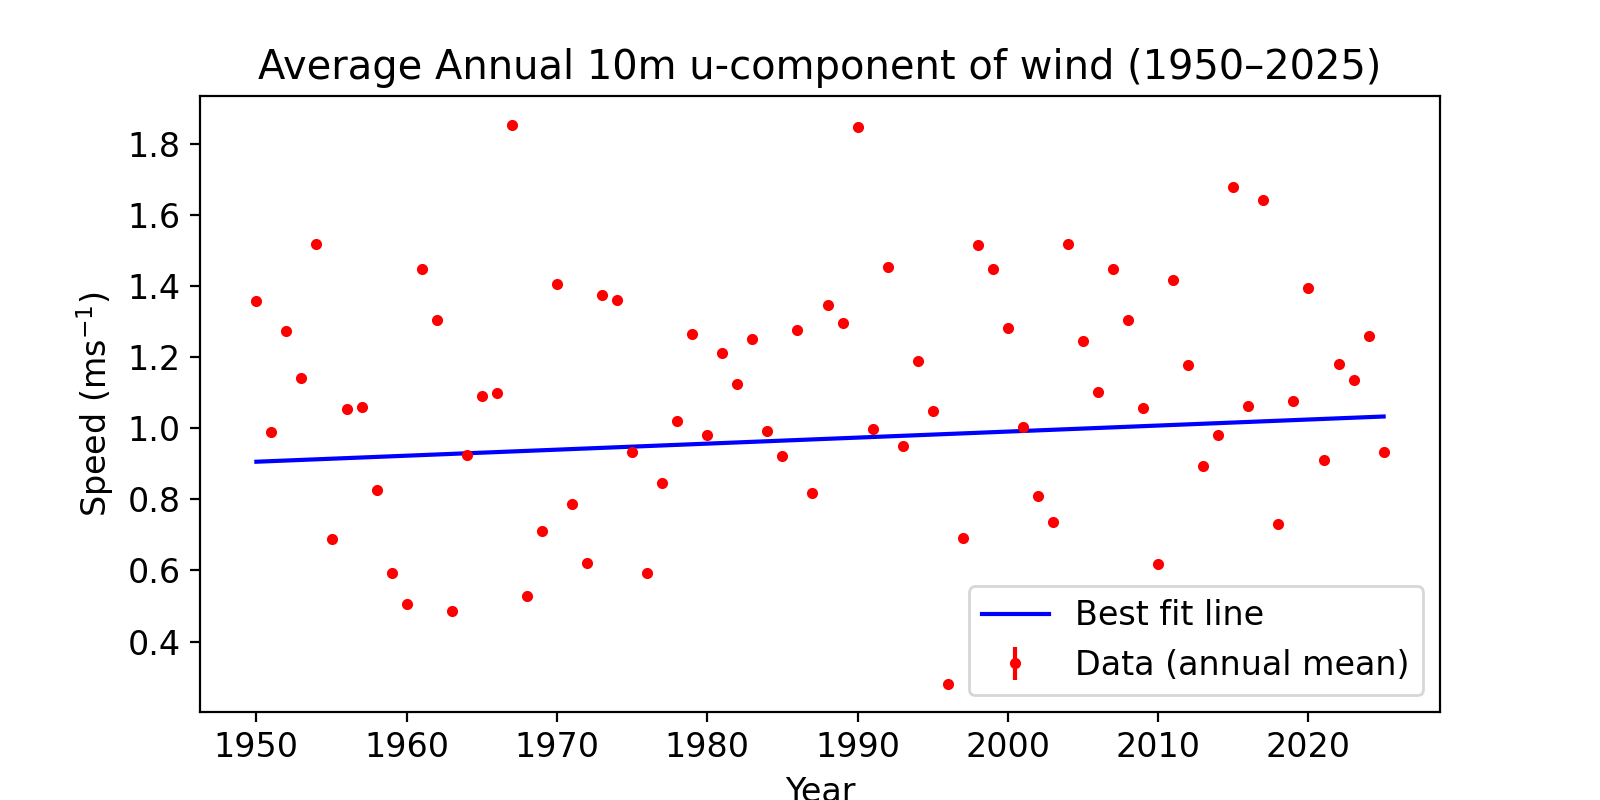

In [48]:
data_all_months = data.u10.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} ms$^{-1}$ per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Speed (ms$^{-1}$)')
plt.title('Average Annual 10m u-component of wind (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.00248 ± 0.00001 ms$^-1$ per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


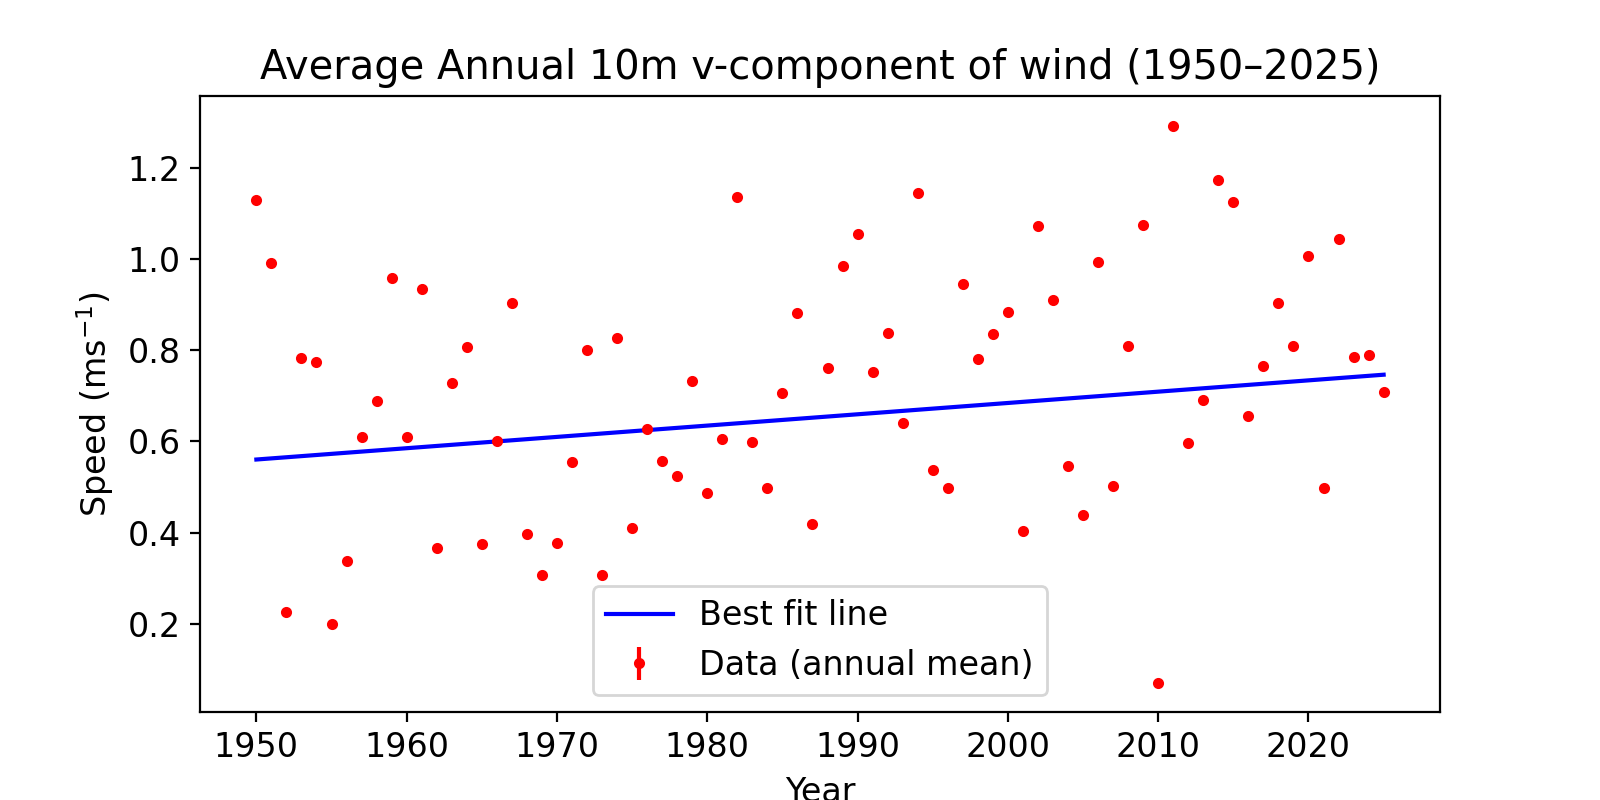

In [49]:
data_all_months = data.v10.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} ms$^{-1}$ per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Speed (ms$^{-1}$)')
plt.title('Average Annual 10m v-component of wind (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.22991 ± 0.05432 Pa per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


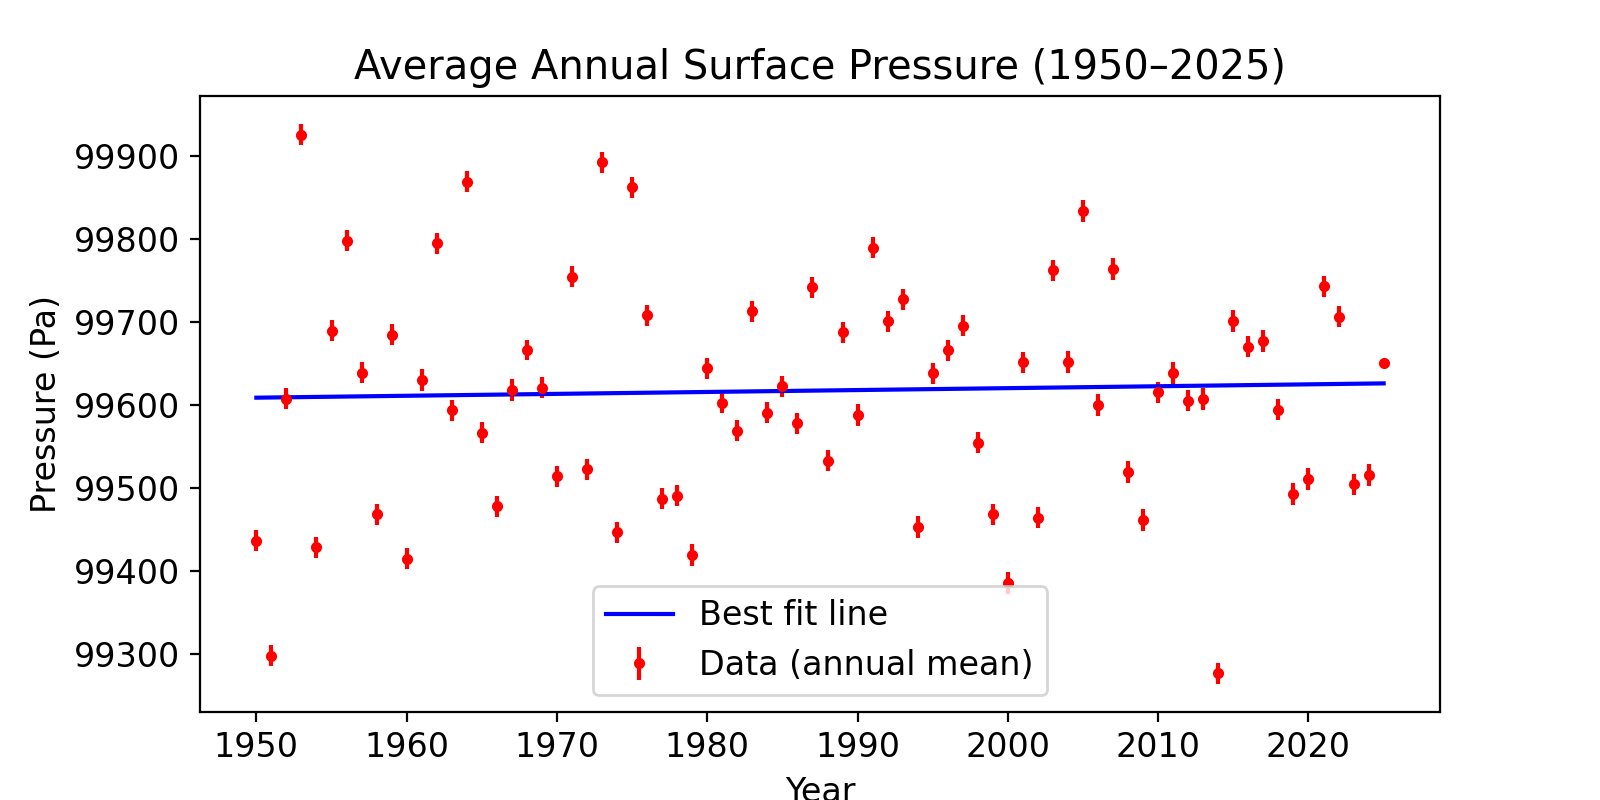

In [50]:
data_all_months = data.sp.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} Pa per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Pressure (Pa)')
plt.title('Average Annual Surface Pressure (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

Slope: 0.00000 ± 0.00000 m per yearIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



<IPython.core.display.Javascript object>


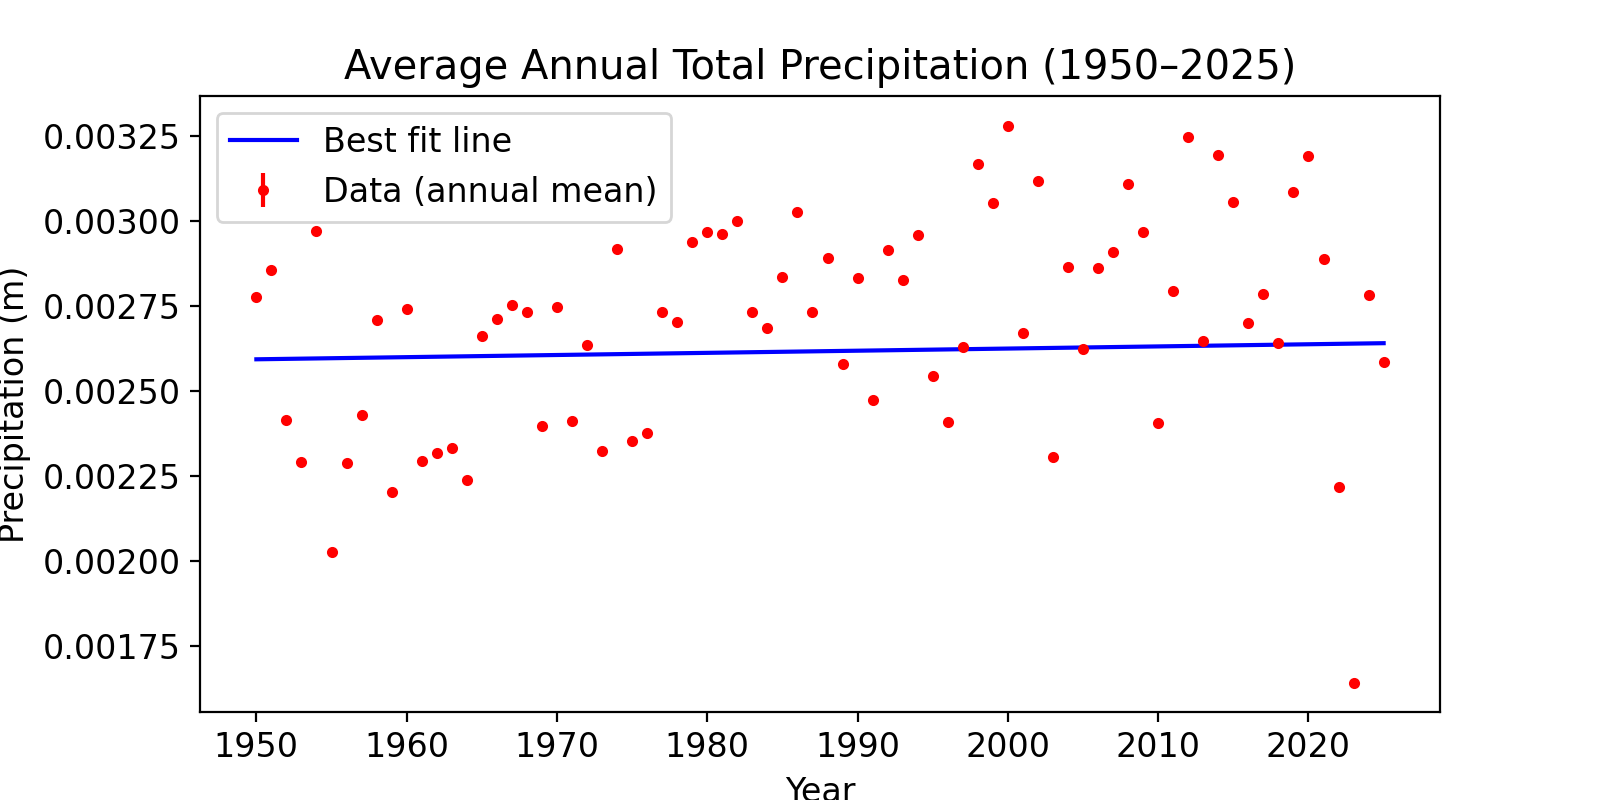

In [51]:
data_all_months = data.tp.values  
mean_value = np.nanmean(data_all_months)

temp = block_reduce(data_all_months, 
                    block_size=(12, 1, 1), 
                    func=np.nanmean, 
                    cval=mean_value)

temp_mean = np.nanmean(temp, axis=(1, 2))
time = np.arange(1950, 2026)

def linear_model(x, m, b):
    return m * x + b


spatial_std = np.nanstd(temp, axis=(1, 2))
n_points = temp.shape[1] * temp.shape[2]
y_err = spatial_std / np.sqrt(n_points)


popt, pcov = curve_fit(linear_model, time, temp_mean, sigma=y_err, absolute_sigma=True)

m, b = popt
m_err = np.sqrt(pcov[0,0])
b_err = np.sqrt(pcov[1,1])


print(f"Slope: {m:.5f} ± {m_err:.5f} m per year")


plt.figure(figsize=(8,4))
plt.errorbar(time, temp_mean, yerr=y_err, fmt='.', color='red', label='Data (annual mean)')
plt.plot(time, linear_model(time, *popt), 'b-', label='Best fit line')
plt.xlabel('Year')
plt.ylabel('Precipitation (m)')
plt.title('Average Annual Total Precipitation (1950–2025)')
plt.legend()
plt.rcParams.update({'font.size': 12})
plt.show()

# Spring 

## Checking 2025

In [68]:
data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-3.nc")

<IPython.core.display.Javascript object>


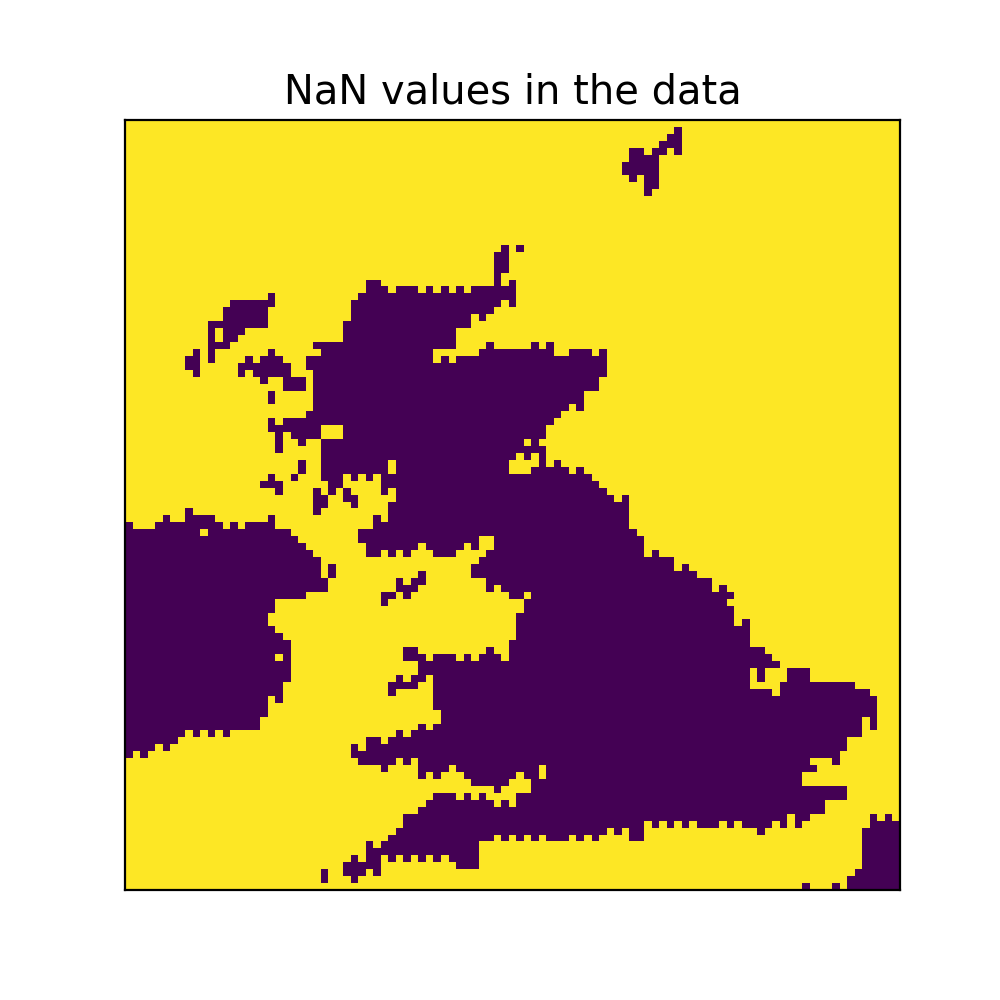

In [69]:
temperature_data = data['d2m']

plt.figure(figsize=(5, 5))
ax = temperature_data.isnull().sum(dim='valid_time').plot(add_colorbar=False)
plt.title('NaN values in the data')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.show()

In [71]:
import xarray as xr
from calendar import month_name

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-3.nc")

tp_data = data.tp
time_values = data.valid_time.values

monthly_mm_values = []

for i in range(len(time_values)):
    date = time_values[i].astype('datetime64[M]').item()
    month = month_name[date.month]
    year = date.year

    monthly_avg = tp_data.isel(valid_time=i).mean(dim=("latitude", "longitude"), skipna=True).values * 1000  # convert to mm
    monthly_mm_values.append(monthly_avg)

    print(f"{month} {year}: {monthly_avg:.2f} mm")

seasonal_avg = sum(monthly_mm_values) / len(monthly_mm_values)
print(f"March–May 2025 average precipitation: {seasonal_avg:.2f} mm")


March 2025: 1.16 mm
April 2025: 1.57 mm
May 2025: 1.56 mm
March–May 2025 average precipitation: 1.43 mm


In [73]:
print(data.tp)

<xarray.DataArray 'tp' (valid_time: 3, latitude: 111, longitude: 103)> Size: 137kB
[34299 values with dtype=float32]
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 24B 2025-03-01 2025-04-01 2025-05-01
  * latitude    (latitude) float64 888B 60.95 60.85 60.75 ... 50.15 50.05 49.95
  * longitude   (longitude) float64 824B -8.2 -8.1 -8.0 -7.9 ... 1.7 1.8 1.9 2.0
    expver      (valid_time) <U4 48B ...
Attributes: (12/31)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      11433
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:      

In [74]:
print(data.valid_time.values)

['2025-03-01T00:00:00.000000000' '2025-04-01T00:00:00.000000000'
 '2025-05-01T00:00:00.000000000']


## Plotting Spring

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


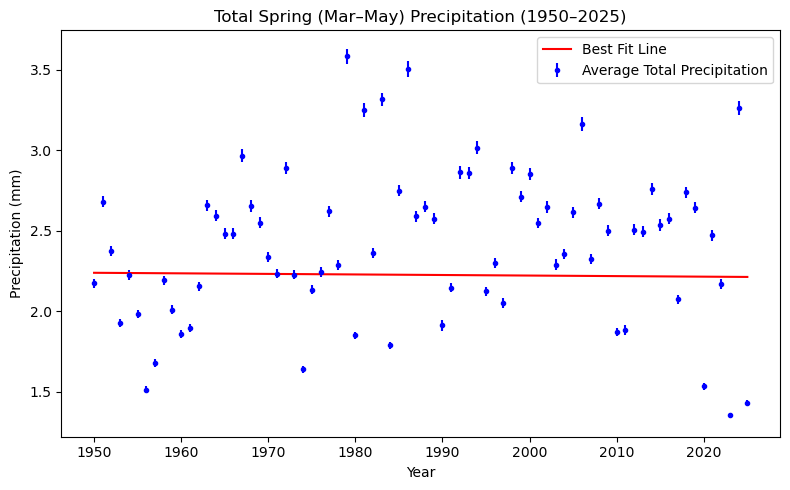

Slope: -3.43188e-04 ± 1.48771e-04 mm/year
March–May 2025 total precipitation: 1.43 mm
March 2025: 1.15 mm
April 2025: 1.54 mm
May 2025: 1.56 mm


In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from calendar import month_name

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

tp_data = data.tp
time_values = data.valid_time.values

months = np.array([(t.astype('datetime64[M]').item().month) for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

unique_years = np.unique(years)
mam_years = []
mam_means = []
mam_stds = []

for yr in unique_years:
    mask = (years == yr) & (np.isin(months, [3, 4, 5]))
    if np.sum(mask) == 3:
        tp_mam = tp_data.isel(valid_time=np.where(mask)[0])
        tp_sum = tp_mam.sum(dim="valid_time", skipna=True)
        mean_val = tp_sum.mean(dim=("latitude", "longitude"), skipna=True).values
        std_val = tp_sum.std(dim=("latitude", "longitude"), skipna=True).values
        n_grid = tp_sum.sizes["latitude"] * tp_sum.sizes["longitude"]
        error = std_val / np.sqrt(n_grid)

        mam_years.append(yr)
        mam_means.append(mean_val)
        mam_stds.append(error)

mam_years = np.array(mam_years)
mam_means = np.array(mam_means) * 1000  # convert to mm
mam_stds = np.array(mam_stds) * 1000    # convert to mm

def linear_model(x, m, b):
    return m * x + b

popt, pcov = curve_fit(linear_model, mam_years, mam_means, sigma=mam_stds, absolute_sigma=True)
slope, intercept = popt
slope_err = np.sqrt(pcov[0, 0])

plt.figure(figsize=(8, 5))
plt.errorbar(mam_years, mam_means, yerr=mam_stds, fmt='.', color='blue', label='Average Total Precipitation')
plt.plot(mam_years, linear_model(mam_years, *popt), 'r-', label='Best Fit Line')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.title('Total Spring (Mar–May) Precipitation (1950–2025)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Slope: {slope:.5e} ± {slope_err:.5e} mm/year")

mask_2025 = (years == 2025) & (np.isin(months, [3, 4, 5]))
if np.sum(mask_2025) == 3:
    indices = np.where(mask_2025)[0]
    tp_2025 = tp_data.isel(valid_time=indices)
    tp_2025_total = tp_2025.sum(dim="valid_time", skipna=True).mean(dim=("latitude", "longitude"), skipna=True).values * 1000
    print(f"March–May 2025 total precipitation: {tp_2025_total:.2f} mm")
    
    for idx in indices:
        date = time_values[idx].astype('datetime64[M]').item()
        val_mm = tp_data.isel(valid_time=idx).mean(dim=("latitude", "longitude"), skipna=True).values * 1000
        print(f"{month_name[date.month]} {date.year}: {val_mm:.2f} mm")
else:
    print("Spring 2025 data is incomplete.")


In [66]:
mask_2025_mam = (years == 2025) & (np.isin(months, [3, 4, 5]))
indices = np.where(mask_2025_mam)[0]

for idx in indices:
    val = tp_data.isel(valid_time=idx).mean(dim=("latitude", "longitude"), skipna=True).values
    date = time_values[idx].astype('datetime64[M]').item()
    print(f"{date}: {val:.6f} m")


2025-03-01: 0.001148 m
2025-04-01: 0.001543 m
2025-05-01: 0.001561 m


<IPython.core.display.Javascript object>


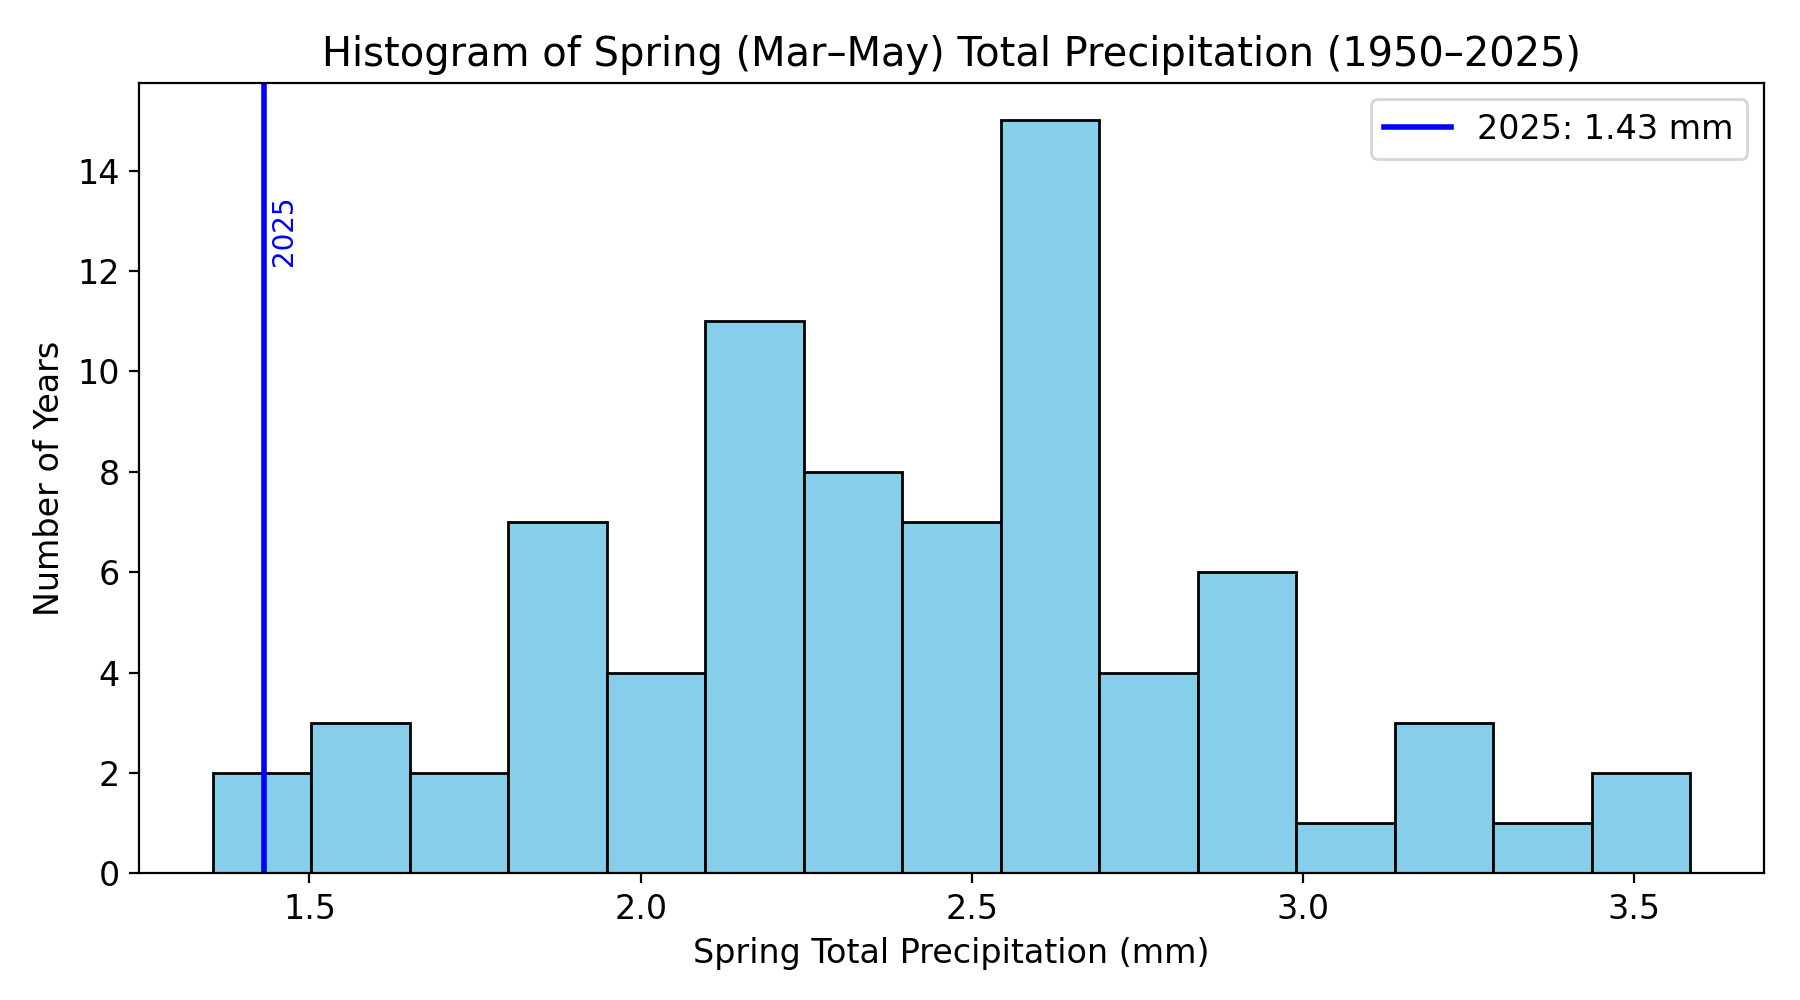

In [95]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

tp_data = data.tp
time_values = data.valid_time.values

months = np.array([(t.astype('datetime64[M]').item().month) for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

spring_totals = []
spring_years = []

for yr in np.unique(years):
    mask = (years == yr) & (np.isin(months, [3, 4, 5]))
    if np.sum(mask) == 3:
        tp_spring = tp_data.isel(valid_time=np.where(mask)[0])
        total_mm = tp_spring.sum(dim="valid_time", skipna=True).mean(dim=("latitude", "longitude"), skipna=True).values.item() * 1000
        spring_totals.append(total_mm)
        spring_years.append(yr)

spring_totals = np.array(spring_totals)
spring_years = np.array(spring_years)

value_2025 = None
if 2025 in spring_years:
    index_2025 = np.where(spring_years == 2025)[0][0]
    value_2025 = spring_totals[index_2025]

plt.figure(figsize=(9, 5))
n, bins, _ = plt.hist(spring_totals, bins=15, color='skyblue', edgecolor='black')
plt.xlabel("Spring Total Precipitation (mm)")
plt.ylabel("Number of Years")
plt.title("Histogram of Spring (Mar–May) Total Precipitation (1950–2025)")

if value_2025 is not None:
    ymax = n.max()
    plt.axvline(value_2025, color='b', linestyle='-', linewidth=2, label=f"2025: {value_2025:.2f} mm")
    plt.text(value_2025 + 0.01,
             ymax * 0.9,
             '2025',
             color='b',
             rotation=90,
             va='top',
             ha='left',
             fontsize=10)
    plt.legend()

plt.tight_layout()
plt.show()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


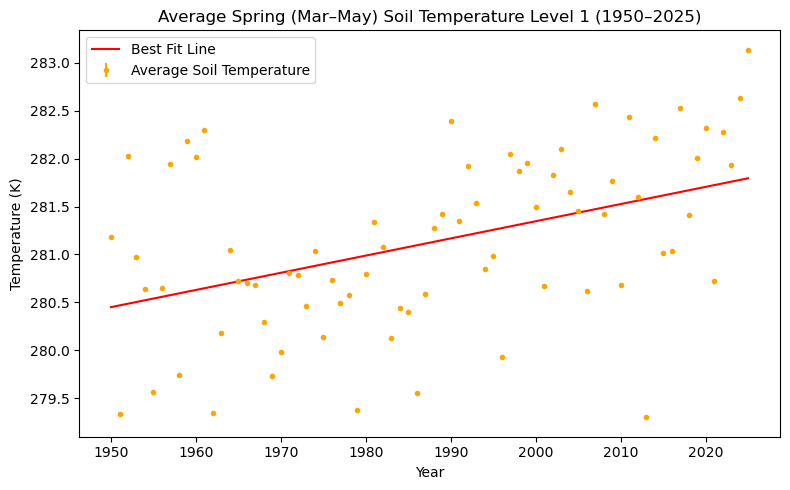

Slope: 1.79376e-02 ± 6.27232e-05 K/year
March–May 2025 average soil temperature: 283.14 K
March 2025 soil temperature: 279.78 K
April 2025 soil temperature: 283.11 K
May 2025 soil temperature: 286.52 K


In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from calendar import month_name

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

stl1_data = data.stl1
time_values = data.valid_time.values

months = np.array([(t.astype('datetime64[M]').item().month) for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

unique_years = np.unique(years)
mam_years = []
mam_means = []
mam_stds = []

for yr in unique_years:
    mask = (years == yr) & (np.isin(months, [3, 4, 5]))
    if np.sum(mask) == 3:  
        stl1_mam = stl1_data.isel(valid_time=np.where(mask)[0])
        stl1_avg = stl1_mam.mean(dim="valid_time", skipna=True)
        mean_val = stl1_avg.mean(dim=("latitude", "longitude"), skipna=True).values
        std_val = stl1_avg.std(dim=("latitude", "longitude"), skipna=True).values
        n_grid = stl1_avg.sizes["latitude"] * stl1_avg.sizes["longitude"]
        error = std_val / np.sqrt(n_grid)

        mam_years.append(yr)
        mam_means.append(mean_val)
        mam_stds.append(error)

mam_years = np.array(mam_years)
mam_means = np.array(mam_means)
mam_stds = np.array(mam_stds)

def linear_model(x, m, b):
    return m * x + b

popt, pcov = curve_fit(linear_model, mam_years, mam_means, sigma=mam_stds, absolute_sigma=True)
slope, intercept = popt
slope_err = np.sqrt(pcov[0, 0])

plt.figure(figsize=(8, 5))
plt.errorbar(mam_years, mam_means, yerr=mam_stds, fmt='.', color='orange', label='Average Soil Temperature')
plt.plot(mam_years, linear_model(mam_years, *popt), 'r-', label='Best Fit Line')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.title('Average Spring (Mar–May) Soil Temperature Level 1 (1950–2025)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Slope: {slope:.5e} ± {slope_err:.5e} K/year")

mask_2025_mam = (years == 2025) & (np.isin(months, [3, 4, 5]))
if np.sum(mask_2025_mam) == 3:
    stl1_mam_2025 = stl1_data.isel(valid_time=np.where(mask_2025_mam)[0])
    stl1_2025_mean = stl1_mam_2025.mean(dim="valid_time", skipna=True).mean(dim=("latitude", "longitude"), skipna=True).values
    print(f"March–May 2025 average soil temperature: {stl1_2025_mean:.2f} K")

    indices = np.where(mask_2025_mam)[0]
    for idx in indices:
        date = time_values[idx].astype('datetime64[M]').item()
        month_str = month_name[date.month]
        single_month = stl1_data.isel(valid_time=idx)
        monthly_mean = single_month.mean(dim=("latitude", "longitude"), skipna=True).values 
        print(f"{month_str} 2025 soil temperature: {monthly_mean:.2f} K")
else:
    print("March–May 2025 data is incomplete.")


<IPython.core.display.Javascript object>


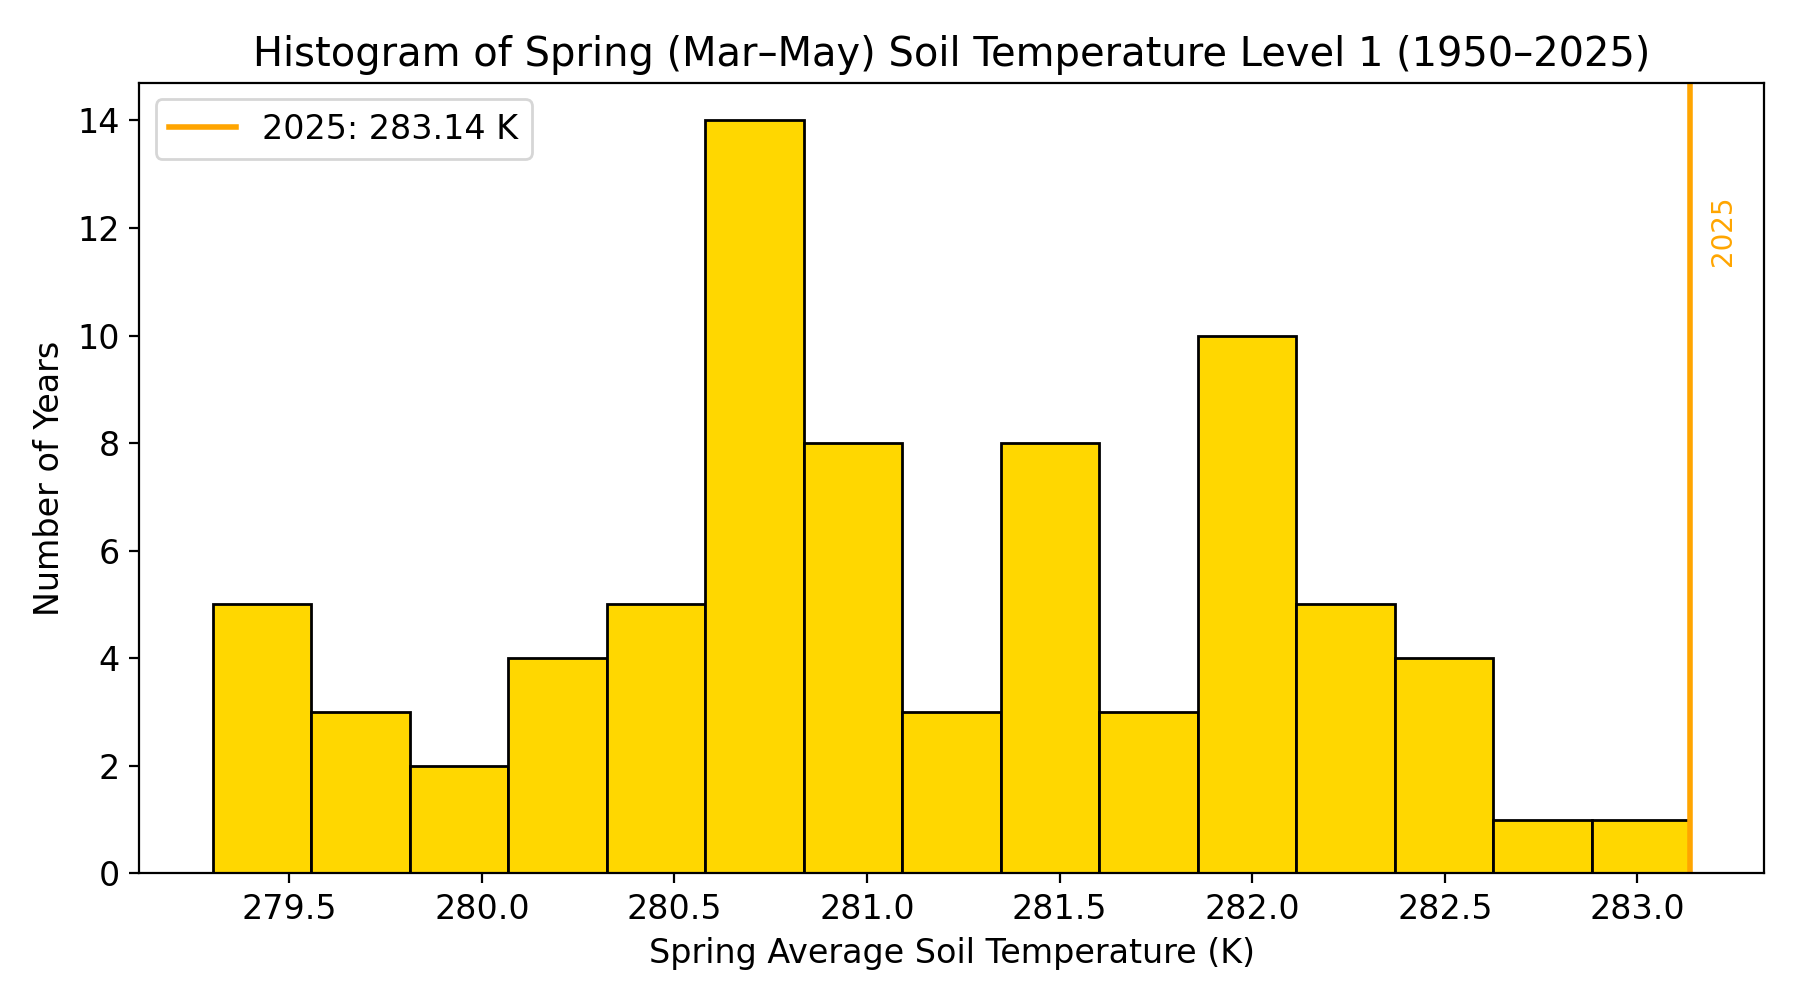

In [120]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

stl1_data = data.stl1
time_values = data.valid_time.values

months = np.array([(t.astype('datetime64[M]').item().month) for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

spring_temps = []
spring_years = []

for yr in np.unique(years):
    mask = (years == yr) & (np.isin(months, [3, 4, 5]))
    if np.sum(mask) == 3:
        stl1_spring = stl1_data.isel(valid_time=np.where(mask)[0])
        avg_temp = stl1_spring.mean(dim="valid_time", skipna=True).mean(dim=("latitude", "longitude"), skipna=True).values.item()
        spring_temps.append(avg_temp)
        spring_years.append(yr)

spring_temps = np.array(spring_temps)
spring_years = np.array(spring_years)

value_2025 = None
if 2025 in spring_years:
    index_2025 = np.where(spring_years == 2025)[0][0]
    value_2025 = spring_temps[index_2025]

plt.figure(figsize=(9, 5))
n, bins, _ = plt.hist(spring_temps, bins=15, color='gold', edgecolor='black')
plt.xlabel("Spring Average Soil Temperature (K)")
plt.ylabel("Number of Years")
plt.title("Histogram of Spring (Mar–May) Soil Temperature Level 1 (1950–2025)")

if value_2025 is not None:
    ymax = n.max()
    plt.axvline(value_2025, color='orange', linestyle='-', linewidth=2, label=f"2025: {value_2025:.2f} K")
    plt.text(value_2025 + 0.05,
             ymax * 0.9,
             '2025',
             color='orange',
             rotation=90,
             va='top',
             ha='left',
             fontsize=10)
    plt.legend()

plt.tight_layout()
plt.show()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


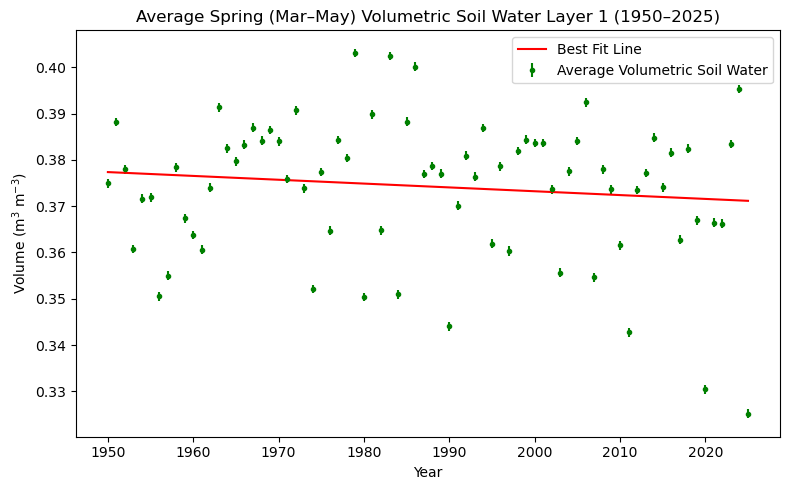

Slope: -8.27479e-05 ± 4.94903e-06 m3 m-3 per year
March–May 2025 average volumetric soil water: 0.33 m3 -3
March 2025 volumetric soil water layer 1: 0.37 m3 m-3
April 2025 volumetric soil water layer 1: 0.33 m3 m-3
May 2025 volumetric soil water layer 1: 0.27 m3 m-3


In [16]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from calendar import month_name

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

swvl1_data = data.swvl1
time_values = data.valid_time.values

months = np.array([(t.astype('datetime64[M]').item().month) for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

unique_years = np.unique(years)
mam_years = []
mam_means = []
mam_stds = []

for yr in unique_years:
    mask = (years == yr) & (np.isin(months, [3, 4, 5]))
    if np.sum(mask) == 3:  
        swvl1_mam = swvl1_data.isel(valid_time=np.where(mask)[0])
        swvl1_avg = swvl1_mam.mean(dim="valid_time", skipna=True)
        mean_val = swvl1_avg.mean(dim=("latitude", "longitude"), skipna=True).values
        std_val = swvl1_avg.std(dim=("latitude", "longitude"), skipna=True).values
        n_grid = swvl1_avg.sizes["latitude"] * swvl1_avg.sizes["longitude"]
        error = std_val / np.sqrt(n_grid)

        mam_years.append(yr)
        mam_means.append(mean_val)
        mam_stds.append(error)

mam_years = np.array(mam_years)
mam_means = np.array(mam_means)
mam_stds = np.array(mam_stds)

def linear_model(x, m, b):
    return m * x + b

popt, pcov = curve_fit(linear_model, mam_years, mam_means, sigma=mam_stds, absolute_sigma=True)
slope, intercept = popt
slope_err = np.sqrt(pcov[0, 0])

plt.figure(figsize=(8, 5))
plt.errorbar(mam_years, mam_means, yerr=mam_stds, fmt='.', color='green', label='Average Volumetric Soil Water')
plt.plot(mam_years, linear_model(mam_years, *popt), 'r-', label='Best Fit Line')
plt.xlabel('Year')
plt.ylabel('Volume (m$^3$ m$^{-3}$)')
plt.title('Average Spring (Mar–May) Volumetric Soil Water Layer 1 (1950–2025)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Slope: {slope:.5e} ± {slope_err:.5e} m3 m-3 per year")

mask_2025_mam = (years == 2025) & (np.isin(months, [3, 4, 5]))
if np.sum(mask_2025_mam) == 3:
    swvl1_mam_2025 = swvl1_data.isel(valid_time=np.where(mask_2025_mam)[0])
    swvl1_2025_mean = swvl1_mam_2025.mean(dim="valid_time", skipna=True).mean(dim=("latitude", "longitude"), skipna=True).values
    print(f"March–May 2025 average volumetric soil water: {swvl1_2025_mean:.2f} m3 -3")

    indices = np.where(mask_2025_mam)[0]
    for idx in indices:
        date = time_values[idx].astype('datetime64[M]').item()
        month_str = month_name[date.month]
        single_month = swvl1_data.isel(valid_time=idx)
        monthly_mean = single_month.mean(dim=("latitude", "longitude"), skipna=True).values 
        print(f"{month_str} 2025 volumetric soil water layer 1: {monthly_mean:.2f} m3 m-3")
else:
    print("March–May 2025 data is incomplete.")


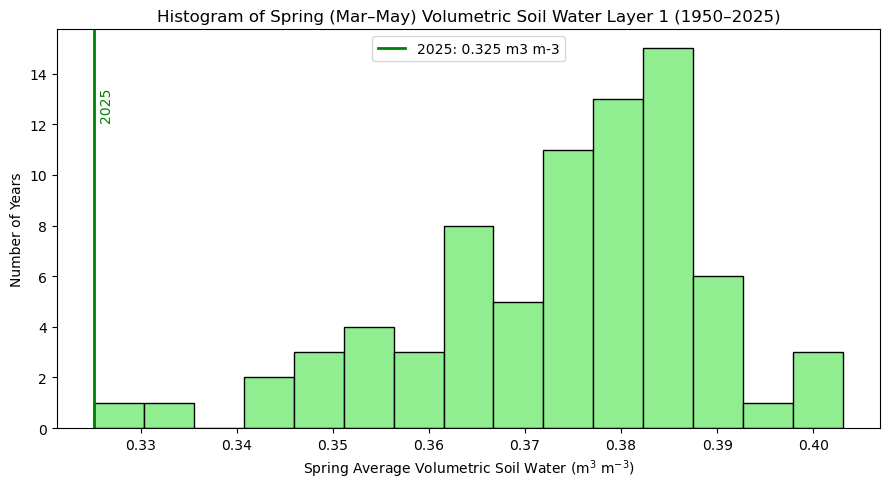

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

swvl1_data = data.swvl1
time_values = data.valid_time.values

months = np.array([(t.astype('datetime64[M]').item().month) for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

spring_values = []
spring_years = []

for yr in np.unique(years):
    mask = (years == yr) & (np.isin(months, [3, 4, 5]))
    if np.sum(mask) == 3:
        swvl1_spring = swvl1_data.isel(valid_time=np.where(mask)[0])
        avg_val = swvl1_spring.mean(dim="valid_time", skipna=True).mean(dim=("latitude", "longitude"), skipna=True).values.item()
        spring_values.append(avg_val)
        spring_years.append(yr)

spring_values = np.array(spring_values)
spring_years = np.array(spring_years)

value_2025 = None
if 2025 in spring_years:
    index_2025 = np.where(spring_years == 2025)[0][0]
    value_2025 = spring_values[index_2025]

plt.figure(figsize=(9, 5))
n, bins, _ = plt.hist(spring_values, bins=15, color='lightgreen', edgecolor='black')
plt.xlabel("Spring Average Volumetric Soil Water (m$^3$ m$^{-3}$)")
plt.ylabel("Number of Years")
plt.title("Histogram of Spring (Mar–May) Volumetric Soil Water Layer 1 (1950–2025)")

if value_2025 is not None:
    ymax = n.max()
    plt.axvline(value_2025, color='green', linestyle='-', linewidth=2, label=f"2025: {value_2025:.3f} m3 m-3")
    plt.text(value_2025 + 0.0005,
             ymax * 0.9,
             '2025',
             color='green',
             rotation=90,
             va='top',
             ha='left',
             fontsize=10)
    plt.legend()

plt.tight_layout()
plt.show()


## Winter 

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


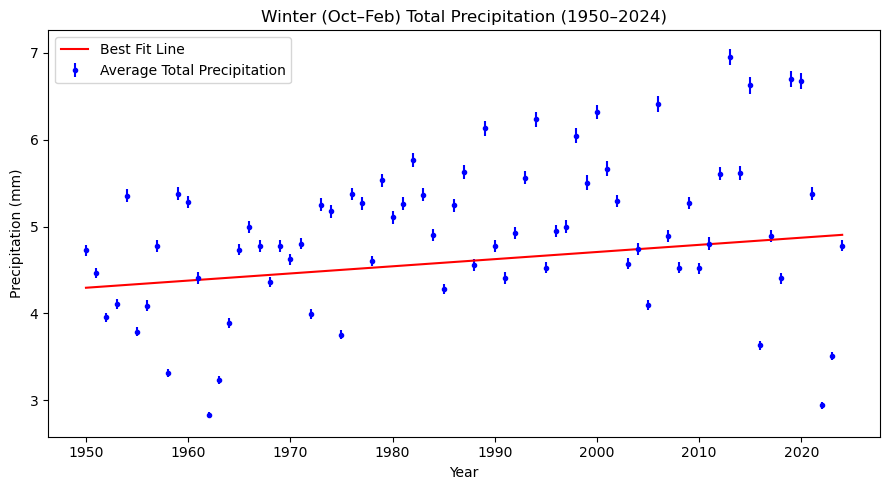

Slope: 8.24009e-03 ± 3.29127e-04 mm/year
Oct 2023 – Feb 2024 total precipitation: 3.51 mm
October 2023: 2.39 mm
November 2023: 1.92 mm
December 2023: 2.50 mm
January 2024: 1.52 mm
February 2024: 2.10 mm


In [15]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

tp_data = data.tp
latitudes = data.latitude.values
time_values = data.valid_time.values

# Extract months and years
months = np.array([t.astype('datetime64[M]').item().month for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

# Handle December as part of winter (adjust year for Dec)
adjusted_years = years.copy()
adjusted_years[months == 12] += 1

# Define masks
north_mask = latitudes >= 53.175
south_mask = latitudes < 53.175

winter_years = []
north_totals = []
south_totals = []
north_errors = []
south_errors = []

for yr in np.unique(adjusted_years):
    mask = (adjusted_years == yr) & (np.isin(months, [12, 1, 2]))
    if np.sum(mask) == 3:
        tp_winter = tp_data.isel(valid_time=np.where(mask)[0])

        tp_north = tp_winter.isel(latitude=np.where(north_mask)[0])
        tp_south = tp_winter.isel(latitude=np.where(south_mask)[0])

        north_total = tp_north.sum(dim="valid_time", skipna=True) * 1000  # mm
        south_total = tp_south.sum(dim="valid_time", skipna=True) * 1000

        north_mean = north_total.mean(dim=("latitude", "longitude"), skipna=True).values.item()
        south_mean = south_total.mean(dim=("latitude", "longitude"), skipna=True).values.item()

        north_std = north_total.std(dim=("latitude", "longitude"), skipna=True).values.item()
        south_std = south_total.std(dim=("latitude", "longitude"), skipna=True).values.item()

        n_north = tp_north.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()
        n_south = tp_south.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()

        north_se = north_std / np.sqrt(n_north)
        south_se = south_std / np.sqrt(n_south)

        winter_years.append(yr)
        north_totals.append(north_mean)
        south_totals.append(south_mean)
        north_errors.append(north_se)
        south_errors.append(south_se)

winter_years = np.array(winter_years)
north_totals = np.array(north_totals)
south_totals = np.array(south_totals)
north_errors = np.array(north_errors)
south_errors = np.array(south_errors)

def linear_model(x, m, b):
    return m * x + b

# Fit North
popt_north, pcov_north = curve_fit(linear_model, winter_years, north_totals, sigma=north_errors, absolute_sigma=True)
slope_north, intercept_north = popt_north
slope_north_err = np.sqrt(pcov_north[0, 0])
fit_north = linear_model(winter_years, *popt_north)

# Fit South
popt_south, pcov_south = curve_fit(linear_model, winter_years, south_totals, sigma=south_errors, absolute_sigma=True)
slope_south, intercept_south = popt_south
slope_south_err = np.sqrt(pcov_south[0, 0])
fit_south = linear_model(winter_years, *popt_south)

# Plot North
plt.figure(figsize=(9, 5))
plt.errorbar(winter_years, north_totals, yerr=north_errors, fmt='b.', capsize=3, label='North UK')
plt.plot(winter_years, fit_north, 'r-', label='Best Fit')
plt.title('Winter Total Precipitation - North UK (≥ 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot South
plt.figure(figsize=(9, 5))
plt.errorbar(winter_years, south_totals, yerr=south_errors, fmt='b.', capsize=3, label='South UK')
plt.plot(winter_years, fit_south, 'r-', label='Best Fit')
plt.title('Winter Total Precipitation - South UK (< 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.tight_layout()
plt.show()

# Print values
if 2025 in winter_years:
    idx_2025 = np.where(winter_years == 2025)[0][0]
    print(f"2025 North Winter Precipitation: {north_totals[idx_2025]:.2f} mm")
    print(f"2025 South Winter Precipitation: {south_totals[idx_2025]:.2f} mm")

print(f"\nNorth Slope: {slope_north:.5f} ± {slope_north_err:.5f} mm/year")
print(f"South Slope: {slope_south:.5f} ± {slope_south_err:.5f} mm/year")


<IPython.core.display.Javascript object>


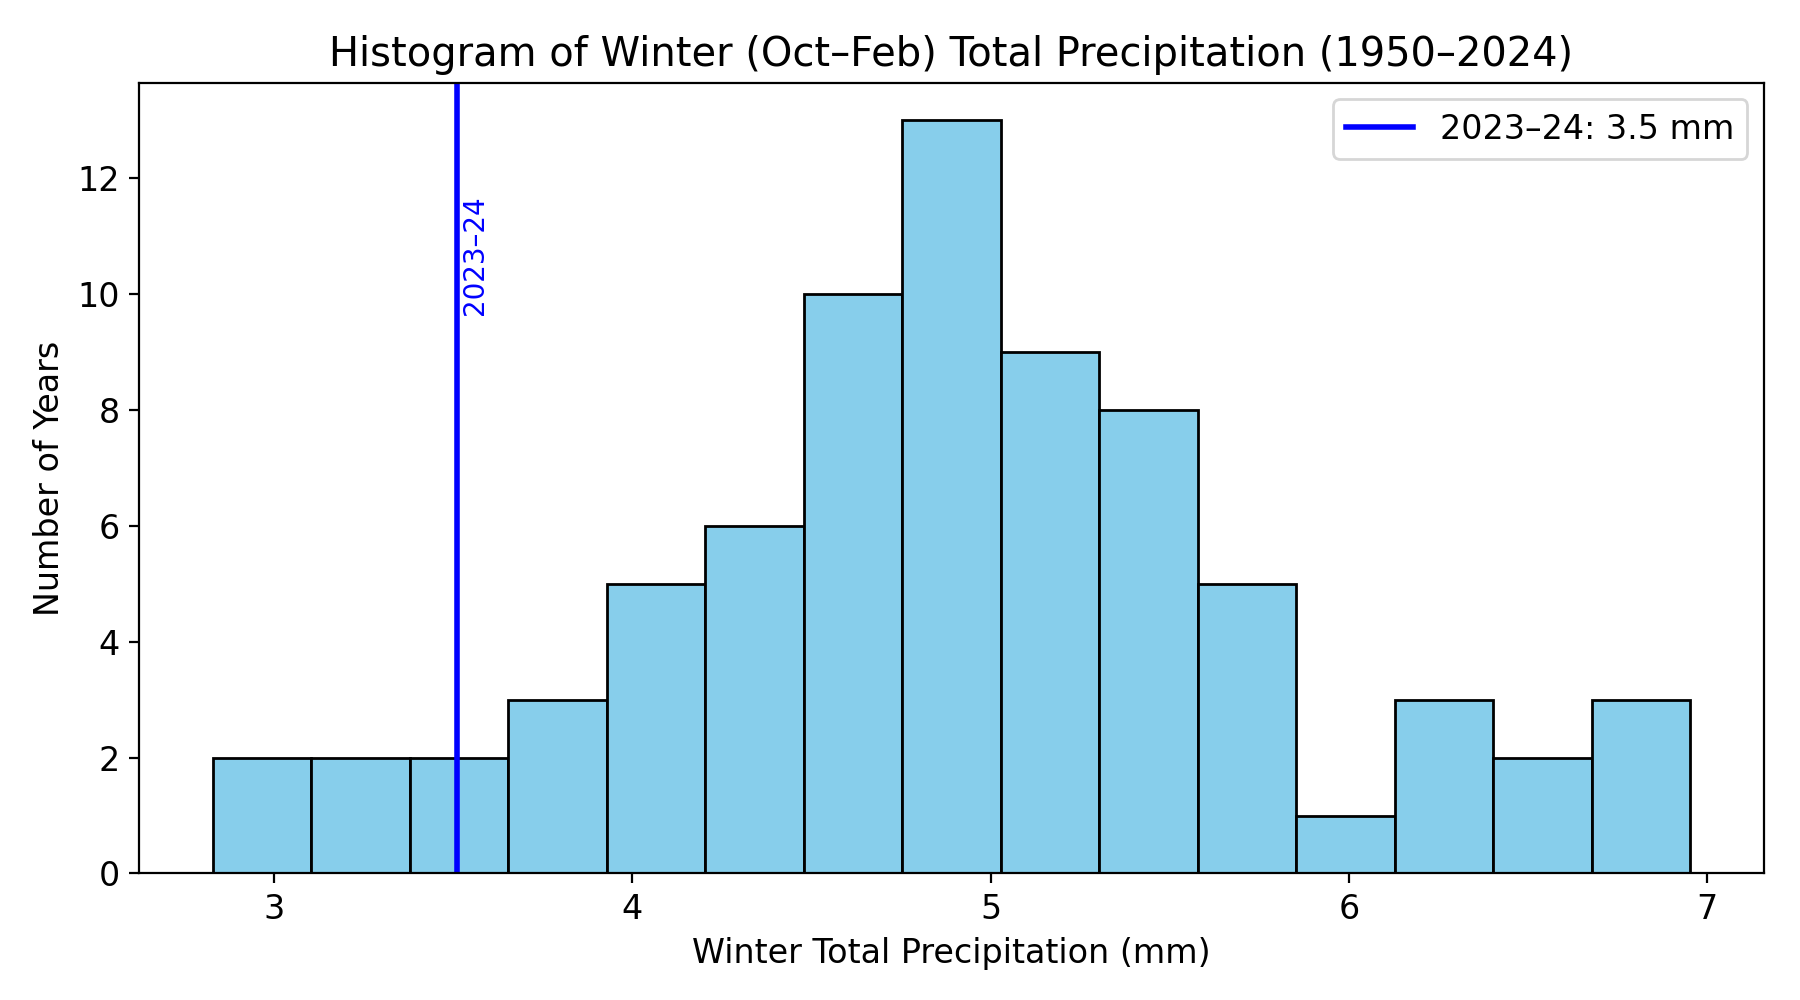

In [114]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

tp_data = data.tp
time_values = data.valid_time.values

months = np.array([t.astype('datetime64[M]').item().month for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

winter_totals = []
winter_years = []

for yr in range(1950, 2024):  
    mask = ((years == yr) & (months == 10)) | \
           ((years == yr) & (months == 11)) | \
           ((years == yr) & (months == 12)) | \
           ((years == yr + 1) & (months <= 2))
    
    if np.sum(mask) == 5:
        tp_winter = tp_data.isel(valid_time=np.where(mask)[0])
        total_mm = tp_winter.sum(dim="valid_time", skipna=True).mean(dim=("latitude", "longitude"), skipna=True).values.item() * 1000
        winter_totals.append(total_mm)
        winter_years.append(yr)

winter_totals = np.array(winter_totals)
winter_years = np.array(winter_years)

value_2023 = None
if 2023 in winter_years:
    index_2023 = np.where(winter_years == 2023)[0][0]
    value_2023 = winter_totals[index_2023]

plt.figure(figsize=(9, 5))
n, bins, _ = plt.hist(winter_totals, bins=15, color='skyblue', edgecolor='black')
plt.xlabel("Winter Total Precipitation (mm)")
plt.ylabel("Number of Years")
plt.title("Histogram of Winter (Oct–Feb) Total Precipitation (1950–2024)")

if value_2023 is not None:
    ymax = n.max()
    plt.axvline(value_2023, color='b', linestyle='-', linewidth=2, label=f"2023–24: {value_2023:.1f} mm")
    plt.text(value_2023 + 0.01,
             ymax * 0.9,
             '2023–24',
             color='b',
             rotation=90,
             va='top',
             ha='left',
             fontsize=10)
    plt.legend()

plt.tight_layout()
plt.show()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


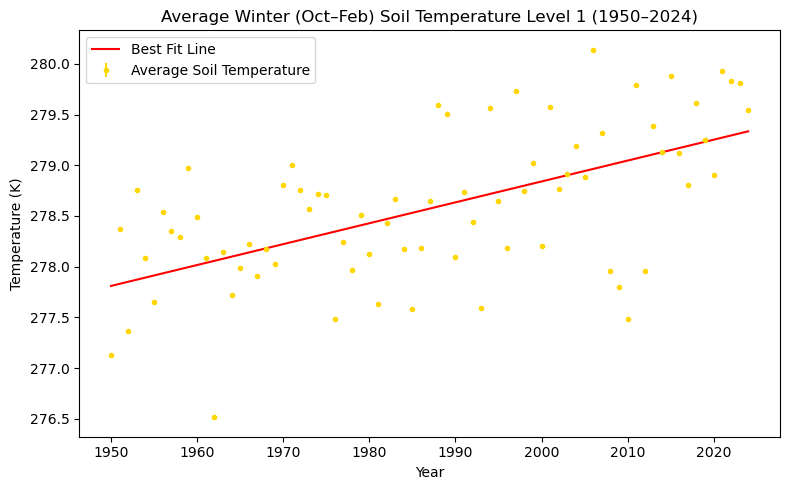

Slope: 2.06079e-02 ± 6.66462e-05 K/year
Oct 2023 – Feb 2024 average soil temperature: 279.81 K
October 2023 soil temperature: 284.36 K
November 2023 soil temperature: 279.88 K
December 2023 soil temperature: 278.78 K
January 2024 soil temperature: 276.80 K
February 2024 soil temperature: 279.25 K


In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from calendar import month_name

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

stl1_data = data.stl1
time_values = data.valid_time.values

months = np.array([(t.astype('datetime64[M]').item().month) for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

winter_years = []
winter_means = []
winter_stds = []

for year in range(1950, 2025):
    mask = ((years == year) & (months == 10)) | \
           ((years == year) & (months == 11)) | \
           ((years == year) & (months == 12)) | \
           ((years == year + 1) & (months <= 2))

    if np.sum(mask) == 5:
        stl1_winter = stl1_data.isel(valid_time=np.where(mask)[0])
        stl1_avg = stl1_winter.mean(dim="valid_time", skipna=True)
        mean_val = stl1_avg.mean(dim=("latitude", "longitude"), skipna=True).values
        std_val = stl1_avg.std(dim=("latitude", "longitude"), skipna=True).values
        n_grid = stl1_avg.sizes["latitude"] * stl1_avg.sizes["longitude"]
        error = std_val / np.sqrt(n_grid)

        winter_years.append(year)
        winter_means.append(mean_val)
        winter_stds.append(error)

winter_years = np.array(winter_years)
winter_means = np.array(winter_means)
winter_stds = np.array(winter_stds)

def linear_model(x, m, b):
    return m * x + b

popt, pcov = curve_fit(linear_model, winter_years, winter_means, sigma=winter_stds, absolute_sigma=True)
slope, intercept = popt
slope_err = np.sqrt(pcov[0, 0])

plt.figure(figsize=(8, 5))
plt.errorbar(winter_years, winter_means, yerr=winter_stds, fmt='.', color='gold', label='Average Soil Temperature')
plt.plot(winter_years, linear_model(winter_years, *popt), 'r-', label='Best Fit Line')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.title('Average Winter (Oct–Feb) Soil Temperature Level 1 (1950–2024)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Slope: {slope:.5e} ± {slope_err:.5e} K/year")

mask_2023 = ((years == 2023) & (months == 10)) | \
            ((years == 2023) & (months == 11)) | \
            ((years == 2023) & (months == 12)) | \
            ((years == 2024) & (months <= 2))

if np.sum(mask_2023) == 5:
    stl1_winter_2023 = stl1_data.isel(valid_time=np.where(mask_2023)[0])
    stl1_mean = stl1_winter_2023.mean(dim="valid_time", skipna=True).mean(dim=("latitude", "longitude"), skipna=True).values
    print(f"Oct 2023 – Feb 2024 average soil temperature: {stl1_mean:.2f} K")

    indices = np.where(mask_2023)[0]
    for idx in indices:
        date = time_values[idx].astype('datetime64[M]').item()
        month_str = month_name[date.month]
        single_month = stl1_data.isel(valid_time=idx)
        monthly_mean = single_month.mean(dim=("latitude", "longitude"), skipna=True).values
        print(f"{month_str} {date.year} soil temperature: {monthly_mean:.2f} K")
else:
    print("Winter 2023–24 data is incomplete.")


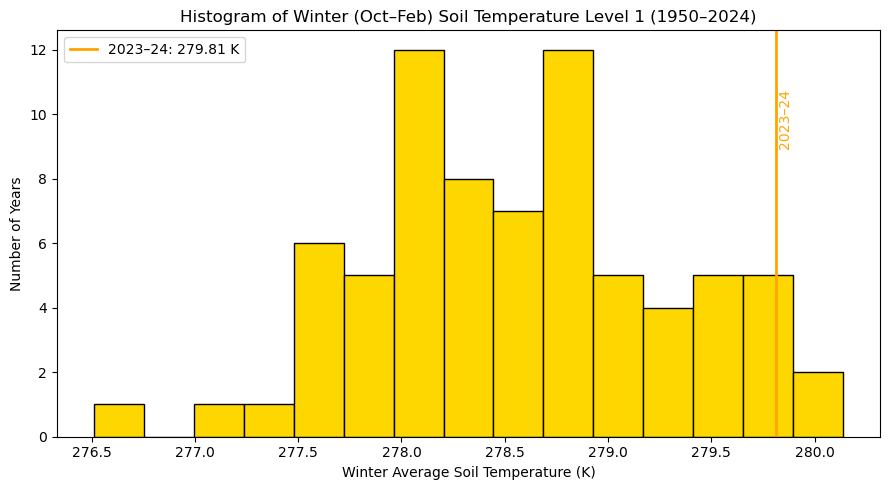

In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

stl1_data = data.stl1
time_values = data.valid_time.values

months = np.array([t.astype('datetime64[M]').item().month for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

winter_means = []
winter_years = []

for yr in range(1950, 2024):  
    mask = ((years == yr) & (months == 10)) | \
           ((years == yr) & (months == 11)) | \
           ((years == yr) & (months == 12)) | \
           ((years == yr + 1) & (months <= 2))
    
    if np.sum(mask) == 5:
        stl1_winter = stl1_data.isel(valid_time=np.where(mask)[0])
        mean_temp = stl1_winter.mean(dim="valid_time", skipna=True).mean(dim=("latitude", "longitude"), skipna=True).values.item()
        winter_means.append(mean_temp)
        winter_years.append(yr)

winter_means = np.array(winter_means)
winter_years = np.array(winter_years)

value_2023 = None
if 2023 in winter_years:
    index_2023 = np.where(winter_years == 2023)[0][0]
    value_2023 = winter_means[index_2023]

plt.figure(figsize=(9, 5))
n, bins, _ = plt.hist(winter_means, bins=15, color='gold', edgecolor='black')
plt.xlabel("Winter Average Soil Temperature (K)")
plt.ylabel("Number of Years")
plt.title("Histogram of Winter (Oct–Feb) Soil Temperature Level 1 (1950–2024)")

if value_2023 is not None:
    ymax = n.max()
    plt.axvline(value_2023, color='orange', linestyle='-', linewidth=2, label=f"2023–24: {value_2023:.2f} K")
    plt.text(value_2023 + 0.01,
             ymax * 0.9,
             '2023–24',
             color='orange',
             rotation=90,
             va='top',
             ha='left',
             fontsize=10)
    plt.legend()

plt.tight_layout()
plt.show()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


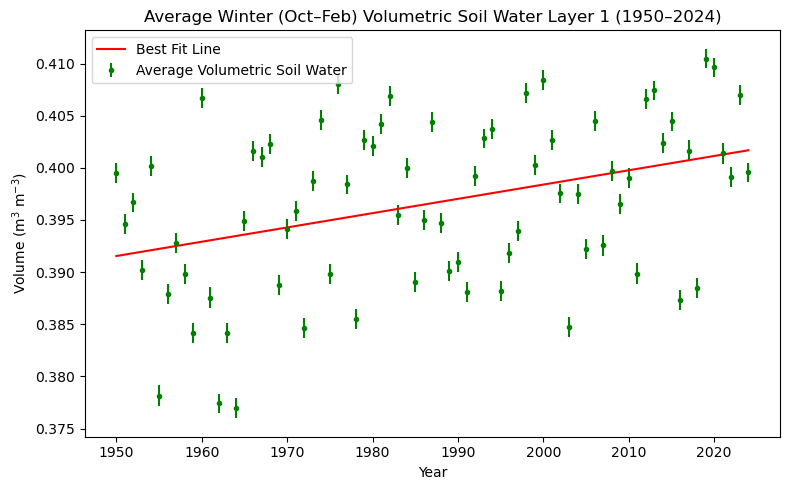

Slope: 1.37030e-04 ± 5.09190e-06 m3 m-3 per year
Oct 2023 – Feb 2024 average volumetric soil water: 0.41 m3 m-3
October 2023 volumetric soil water: 0.40 m3 m-3
November 2023 volumetric soil water: 0.41 m3 m-3
December 2023 volumetric soil water: 0.41 m3 m-3
January 2024 volumetric soil water: 0.40 m3 m-3
February 2024 volumetric soil water: 0.41 m3 m-3


In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from calendar import month_name

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

swvl1_data = data.swvl1
time_values = data.valid_time.values

months = np.array([(t.astype('datetime64[M]').item().month) for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

winter_years = []
winter_means = []
winter_stds = []

for year in range(1950, 2025):
    mask = ((years == year) & (months == 10)) | \
           ((years == year) & (months == 11)) | \
           ((years == year) & (months == 12)) | \
           ((years == year + 1) & (months <= 2))

    if np.sum(mask) == 5:
        swvl1_winter = swvl1_data.isel(valid_time=np.where(mask)[0])
        swvl1_avg = swvl1_winter.mean(dim="valid_time", skipna=True)
        mean_val = swvl1_avg.mean(dim=("latitude", "longitude"), skipna=True).values
        std_val = swvl1_avg.std(dim=("latitude", "longitude"), skipna=True).values
        n_grid = swvl1_avg.sizes["latitude"] * swvl1_avg.sizes["longitude"]
        error = std_val / np.sqrt(n_grid)

        winter_years.append(year)
        winter_means.append(mean_val)
        winter_stds.append(error)

winter_years = np.array(winter_years)
winter_means = np.array(winter_means)
winter_stds = np.array(winter_stds)

def linear_model(x, m, b):
    return m * x + b

popt, pcov = curve_fit(linear_model, winter_years, winter_means, sigma=winter_stds, absolute_sigma=True)
slope, intercept = popt
slope_err = np.sqrt(pcov[0, 0])

plt.figure(figsize=(8, 5))
plt.errorbar(winter_years, winter_means, yerr=winter_stds, fmt='.', color='green', label='Average Volumetric Soil Water')
plt.plot(winter_years, linear_model(winter_years, *popt), 'r-', label='Best Fit Line')
plt.xlabel('Year')
plt.ylabel('Volume (m$^3$ m$^{-3}$)')
plt.title('Average Winter (Oct–Feb) Volumetric Soil Water Layer 1 (1950–2024)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Slope: {slope:.5e} ± {slope_err:.5e} m3 m-3 per year")

mask_2023 = ((years == 2023) & (months == 10)) | \
            ((years == 2023) & (months == 11)) | \
            ((years == 2023) & (months == 12)) | \
            ((years == 2024) & (months <= 2))

if np.sum(mask_2023) == 5:
    swvl1_winter_2023 = swvl1_data.isel(valid_time=np.where(mask_2023)[0])
    swvl1_mean = swvl1_winter_2023.mean(dim="valid_time", skipna=True).mean(dim=("latitude", "longitude"), skipna=True).values
    print(f"Oct 2023 – Feb 2024 average volumetric soil water: {swvl1_mean:.2f} m3 m-3")

    indices = np.where(mask_2023)[0]
    for idx in indices:
        date = time_values[idx].astype('datetime64[M]').item()
        month_str = month_name[date.month]
        single_month = swvl1_data.isel(valid_time=idx)
        monthly_mean = single_month.mean(dim=("latitude", "longitude"), skipna=True).values
        print(f"{month_str} {date.year} volumetric soil water: {monthly_mean:.2f} m3 m-3")
else:
    print("Winter 2023–24 data is incomplete.")


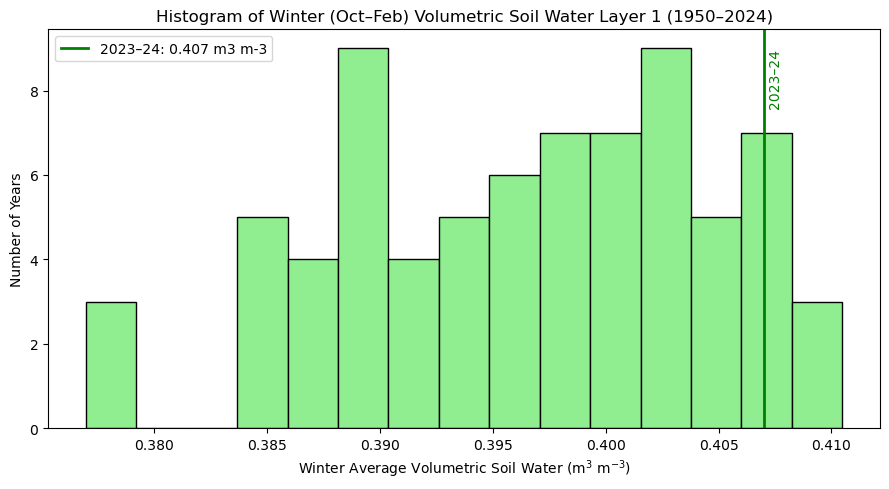

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

swvl1_data = data.swvl1
time_values = data.valid_time.values

months = np.array([t.astype('datetime64[M]').item().month for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

winter_means = []
winter_years = []

for yr in range(1950, 2024):  
    mask = ((years == yr) & (months == 10)) | \
           ((years == yr) & (months == 11)) | \
           ((years == yr) & (months == 12)) | \
           ((years == yr + 1) & (months <= 2))
    
    if np.sum(mask) == 5:
        swvl1_winter = swvl1_data.isel(valid_time=np.where(mask)[0])
        mean_val = swvl1_winter.mean(dim="valid_time", skipna=True).mean(dim=("latitude", "longitude"), skipna=True).values.item()
        winter_means.append(mean_val)
        winter_years.append(yr)

winter_means = np.array(winter_means)
winter_years = np.array(winter_years)

value_2023 = None
if 2023 in winter_years:
    index_2023 = np.where(winter_years == 2023)[0][0]
    value_2023 = winter_means[index_2023]

plt.figure(figsize=(9, 5))
n, bins, _ = plt.hist(winter_means, bins=15, color='lightgreen', edgecolor='black')
plt.xlabel("Winter Average Volumetric Soil Water (m$^3$ m$^{-3}$)")
plt.ylabel("Number of Years")
plt.title("Histogram of Winter (Oct–Feb) Volumetric Soil Water Layer 1 (1950–2024)")

if value_2023 is not None:
    ymax = n.max()
    plt.axvline(value_2023, color='green', linestyle='-', linewidth=2, label=f"2023–24: {value_2023:.3f} m3 m-3")
    plt.text(value_2023 + 0.0002,
             ymax * 1,
             '2023–24',
             color='green',
             rotation=90,
             va='top',
             ha='left',
             fontsize=10)
    plt.legend()

plt.tight_layout()
plt.show()


## Splitting Spring Into North & South

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


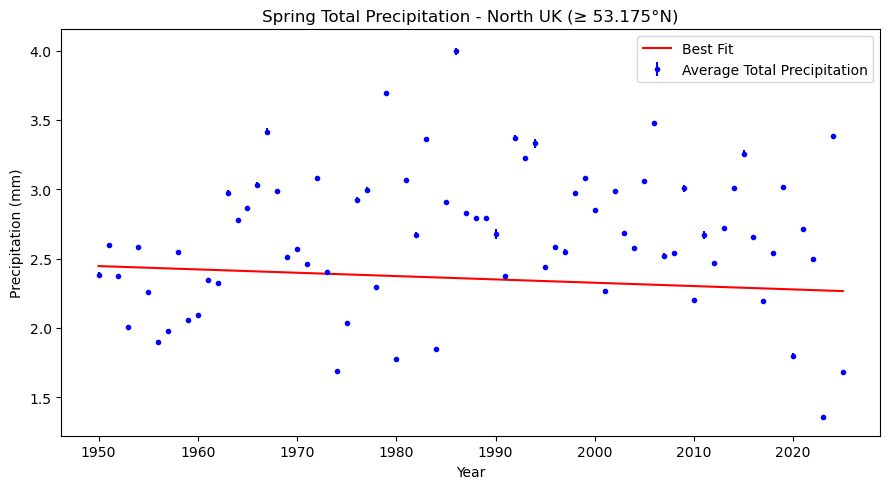

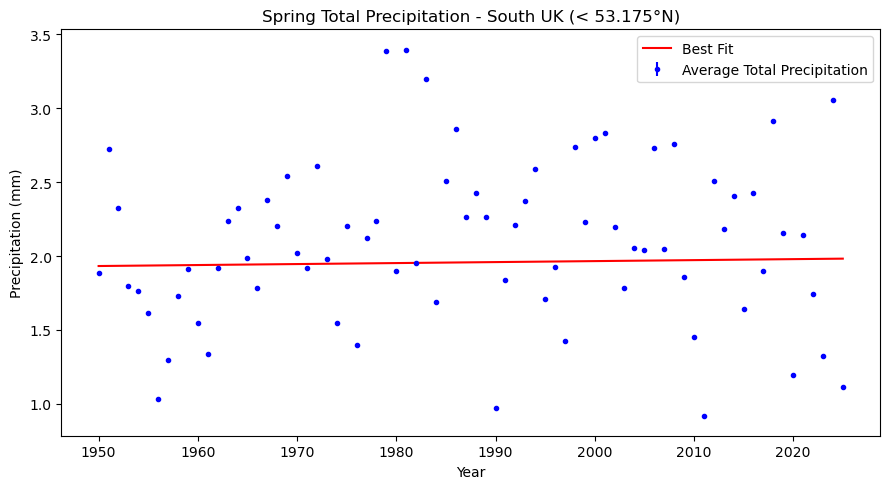

2025 North Spring Precipitation: 1.68 mm
2025 South Spring Precipitation: 1.11 mm

North UK Slope: -0.00240 ± 0.00006 mm/year
South UK Slope: 0.00067 ± 0.00004 mm/year


In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

tp_data = data.tp
latitudes = data.latitude.values
time_values = data.valid_time.values

months = np.array([t.astype('datetime64[M]').item().month for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

north_mask = latitudes >= 53.175
south_mask = latitudes < 53.175

spring_years = []
north_totals = []
south_totals = []
north_errors = []
south_errors = []

for yr in np.unique(years):
    mask = (years == yr) & (np.isin(months, [3, 4, 5]))
    if np.sum(mask) == 3:
        tp_spring = tp_data.isel(valid_time=np.where(mask)[0])

        tp_north = tp_spring.isel(latitude=np.where(north_mask)[0])
        tp_south = tp_spring.isel(latitude=np.where(south_mask)[0])

        north_season = tp_north.mean(dim="valid_time", skipna=True) * 1000
        south_season = tp_south.mean(dim="valid_time", skipna=True) * 1000

        north_mean = north_season.mean(dim=("latitude", "longitude"), skipna=True).values.item()
        south_mean = south_season.mean(dim=("latitude", "longitude"), skipna=True).values.item()

        north_std = north_season.std(dim=("latitude", "longitude"), skipna=True).values.item()
        south_std = south_season.std(dim=("latitude", "longitude"), skipna=True).values.item()

        n_north = tp_north.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()
        n_south = tp_south.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()

        north_se = north_std / np.sqrt(n_north)
        south_se = south_std / np.sqrt(n_south)

        spring_years.append(yr)
        north_totals.append(north_mean)
        south_totals.append(south_mean)
        north_errors.append(north_se)
        south_errors.append(south_se)

spring_years = np.array(spring_years)
north_totals = np.array(north_totals)
south_totals = np.array(south_totals)
north_errors = np.array(north_errors)
south_errors = np.array(south_errors)

def linear_model(x, m, b):
    return m * x + b

popt_north, pcov_north = curve_fit(linear_model, spring_years, north_totals, sigma=north_errors, absolute_sigma=True)
slope_north, intercept_north = popt_north
slope_north_err = np.sqrt(pcov_north[0, 0])

popt_south, pcov_south = curve_fit(linear_model, spring_years, south_totals, sigma=south_errors, absolute_sigma=True)
slope_south, intercept_south = popt_south
slope_south_err = np.sqrt(pcov_south[0, 0])

fit_north = linear_model(spring_years, *popt_north)
fit_south = linear_model(spring_years, *popt_south)

plt.figure(figsize=(9, 5))
plt.errorbar(spring_years, north_totals, yerr=north_errors, fmt='b.', label='Average Total Precipitation')
plt.plot(spring_years, fit_north, 'r-', label='Best Fit')
plt.title('Spring Total Precipitation - North UK (≥ 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 5))
plt.errorbar(spring_years, south_totals, yerr=south_errors, fmt='b.', label='Average Total Precipitation')
plt.plot(spring_years, fit_south, 'r-', label='Best Fit')
plt.title('Spring Total Precipitation - South UK (< 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.tight_layout()
plt.show()

if 2025 in spring_years:
    idx_2025 = np.where(spring_years == 2025)[0][0]
    print(f"2025 North Spring Precipitation: {north_totals[idx_2025]:.2f} mm")
    print(f"2025 South Spring Precipitation: {south_totals[idx_2025]:.2f} mm")

print(f"\nNorth UK Slope: {slope_north:.5f} ± {slope_north_err:.5f} mm/year")
print(f"South UK Slope: {slope_south:.5f} ± {slope_south_err:.5f} mm/year")


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


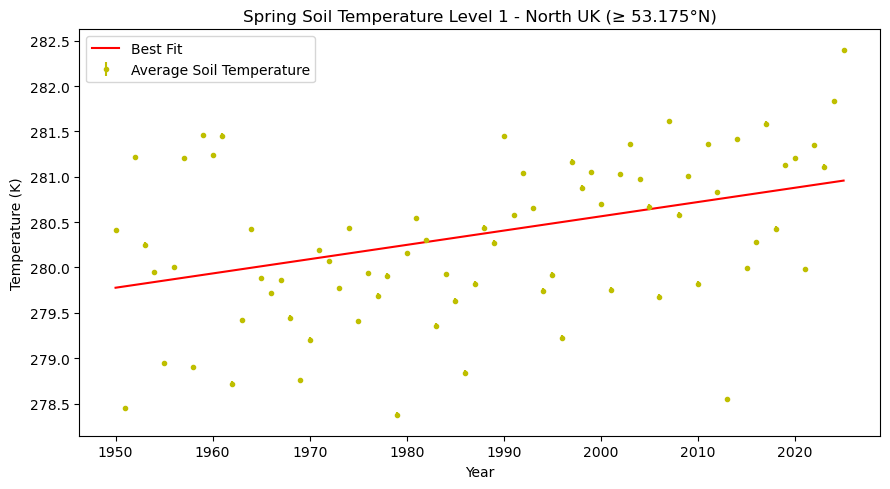

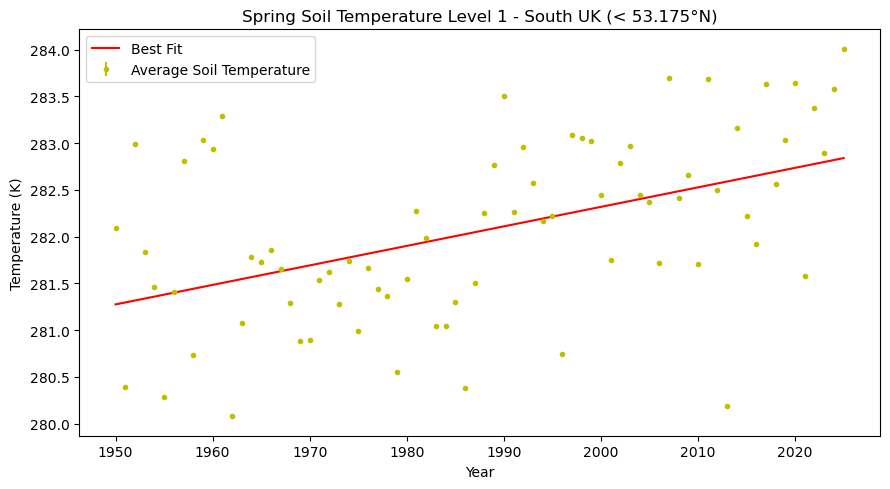

2025 North Spring Soil Temp: 282.40 K
2025 South Spring Soil Temp: 284.00 K

North Slope: 0.01575 ± 0.00013 K/year
South Slope: 0.02087 ± 0.00009 K/year


In [20]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

stl1_data = data.stl1
latitudes = data.latitude.values
time_values = data.valid_time.values

months = np.array([t.astype('datetime64[M]').item().month for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

north_mask = latitudes >= 53.175
south_mask = latitudes < 53.175

spring_years = []
north_means = []
south_means = []
north_errors = []
south_errors = []

for yr in np.unique(years):
    mask = (years == yr) & (np.isin(months, [3, 4, 5]))
    if np.sum(mask) == 3:
        stl1_spring = stl1_data.isel(valid_time=np.where(mask)[0])

        stl1_north = stl1_spring.isel(latitude=np.where(north_mask)[0])
        stl1_south = stl1_spring.isel(latitude=np.where(south_mask)[0])

        north_avg = stl1_north.mean(dim="valid_time", skipna=True)
        south_avg = stl1_south.mean(dim="valid_time", skipna=True)

        north_mean = north_avg.mean(dim=("latitude", "longitude"), skipna=True).values.item()
        south_mean = south_avg.mean(dim=("latitude", "longitude"), skipna=True).values.item()

        north_std = north_avg.std(dim=("latitude", "longitude"), skipna=True).values.item()
        south_std = south_avg.std(dim=("latitude", "longitude"), skipna=True).values.item()

        n_north = stl1_north.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()
        n_south = stl1_south.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()

        north_se = north_std / np.sqrt(n_north)
        south_se = south_std / np.sqrt(n_south)

        spring_years.append(yr)
        north_means.append(north_mean)
        south_means.append(south_mean)
        north_errors.append(north_se)
        south_errors.append(south_se)

spring_years = np.array(spring_years)
north_means = np.array(north_means)
south_means = np.array(south_means)
north_errors = np.array(north_errors)
south_errors = np.array(south_errors)

def linear_model(x, m, b):
    return m * x + b


popt_north, pcov_north = curve_fit(linear_model, spring_years, north_means, sigma=north_errors, absolute_sigma=True)
slope_north, intercept_north = popt_north
slope_north_err = np.sqrt(pcov_north[0, 0])
fit_north = linear_model(spring_years, *popt_north)


popt_south, pcov_south = curve_fit(linear_model, spring_years, south_means, sigma=south_errors, absolute_sigma=True)
slope_south, intercept_south = popt_south
slope_south_err = np.sqrt(pcov_south[0, 0])
fit_south = linear_model(spring_years, *popt_south)


plt.figure(figsize=(9, 5))
plt.errorbar(spring_years, north_means, yerr=north_errors, fmt='y.', label='Average Soil Temperature')
plt.plot(spring_years, fit_north, 'r-', label='Best Fit')
plt.title('Spring Soil Temperature Level 1 - North UK (≥ 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 5))
plt.errorbar(spring_years, south_means, yerr=south_errors, fmt='y.', label='Average Soil Temperature')
plt.plot(spring_years, fit_south, 'r-', label='Best Fit')
plt.title('Spring Soil Temperature Level 1 - South UK (< 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.legend()
plt.tight_layout()
plt.show()


if 2025 in spring_years:
    idx_2025 = np.where(spring_years == 2025)[0][0]
    print(f"2025 North Spring Soil Temp: {north_means[idx_2025]:.2f} K")
    print(f"2025 South Spring Soil Temp: {south_means[idx_2025]:.2f} K")

print(f"\nNorth Slope: {slope_north:.5f} ± {slope_north_err:.5f} K/year")
print(f"South Slope: {slope_south:.5f} ± {slope_south_err:.5f} K/year")


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


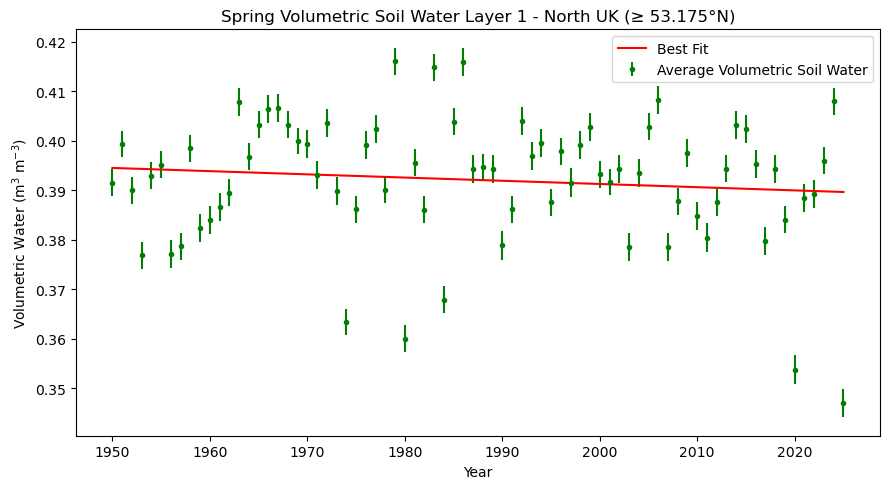

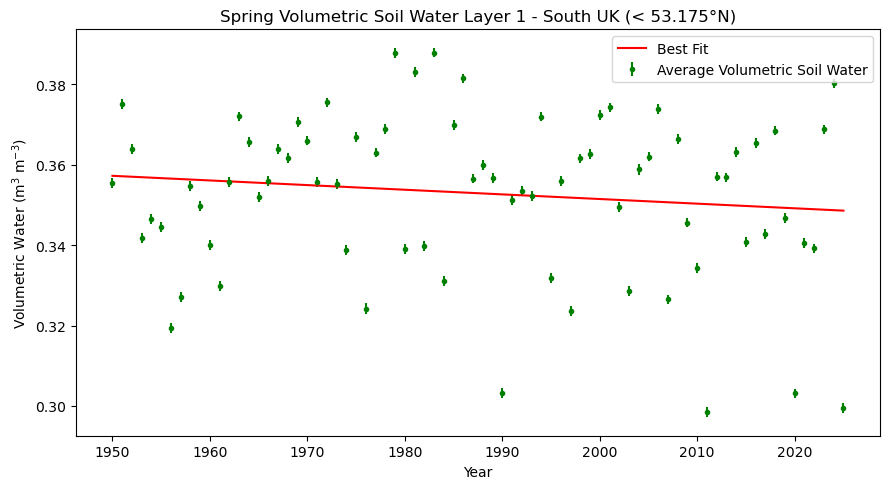

2025 North Spring Soil Water: 0.35 m3 m-3
2025 South Spring Soil Water: 0.30 m3 m-3

North Slope: -0.00006 ± 0.00001 m3 m-3/year
South Slope: -0.00012 ± 0.00001 m3 m-3/year


In [21]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

swvl1_data = data.swvl1
latitudes = data.latitude.values
time_values = data.valid_time.values

months = np.array([t.astype('datetime64[M]').item().month for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

north_mask = latitudes >= 53.175
south_mask = latitudes < 53.175

spring_years = []
north_means = []
south_means = []
north_errors = []
south_errors = []

for yr in np.unique(years):
    mask = (years == yr) & (np.isin(months, [3, 4, 5]))
    if np.sum(mask) == 3:
        swvl1_spring = swvl1_data.isel(valid_time=np.where(mask)[0])

        swvl1_north = swvl1_spring.isel(latitude=np.where(north_mask)[0])
        swvl1_south = swvl1_spring.isel(latitude=np.where(south_mask)[0])

        north_total = swvl1_north.mean(dim="valid_time", skipna=True)
        south_total = swvl1_south.mean(dim="valid_time", skipna=True)

        north_mean = north_total.mean(dim=("latitude", "longitude"), skipna=True).values.item() 
        south_mean = south_total.mean(dim=("latitude", "longitude"), skipna=True).values.item() 

        north_std = north_total.std(dim=("latitude", "longitude"), skipna=True).values.item()
        south_std = south_total.std(dim=("latitude", "longitude"), skipna=True).values.item()

        n_north = swvl1_north.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()
        n_south = swvl1_south.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()

        north_se = north_std / np.sqrt(n_north)
        south_se = south_std / np.sqrt(n_south)

        spring_years.append(yr)
        north_means.append(north_mean)
        south_means.append(south_mean)
        north_errors.append(north_se)
        south_errors.append(south_se)

spring_years = np.array(spring_years)
north_means = np.array(north_means)
south_means = np.array(south_means)
north_errors = np.array(north_errors)
south_errors = np.array(south_errors)

def linear_model(x, m, b):
    return m * x + b

popt_north, pcov_north = curve_fit(linear_model, spring_years, north_means, sigma=north_errors, absolute_sigma=True)
slope_north, intercept_north = popt_north
slope_north_err = np.sqrt(pcov_north[0, 0])
fit_north = linear_model(spring_years, *popt_north)

popt_south, pcov_south = curve_fit(linear_model, spring_years, south_means, sigma=south_errors, absolute_sigma=True)
slope_south, intercept_south = popt_south
slope_south_err = np.sqrt(pcov_south[0, 0])
fit_south = linear_model(spring_years, *popt_south)

plt.figure(figsize=(9, 5))
plt.errorbar(spring_years, north_means, yerr=north_errors, fmt='g.', label='Average Volumetric Soil Water')
plt.plot(spring_years, fit_north, 'r-', label='Best Fit')
plt.title('Spring Volumetric Soil Water Layer 1 - North UK (≥ 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Volumetric Water (m$^3$ m$^{-3}$)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.errorbar(spring_years, south_means, yerr=south_errors, fmt='g.', label='Average Volumetric Soil Water')
plt.plot(spring_years, fit_south, 'r-', label='Best Fit')
plt.title('Spring Volumetric Soil Water Layer 1 - South UK (< 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Volumetric Water (m$^3$ m$^{-3}$)')
plt.legend()
plt.tight_layout()
plt.show()

if 2025 in spring_years:
    idx_2025 = np.where(spring_years == 2025)[0][0]
    print(f"2025 North Spring Soil Water: {north_means[idx_2025]:.2f} m3 m-3")
    print(f"2025 South Spring Soil Water: {south_means[idx_2025]:.2f} m3 m-3")

print(f"\nNorth Slope: {slope_north:.5f} ± {slope_north_err:.5f} m3 m-3/year")
print(f"South Slope: {slope_south:.5f} ± {slope_south_err:.5f} m3 m-3/year")



# Splitting Winter Into North & South

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


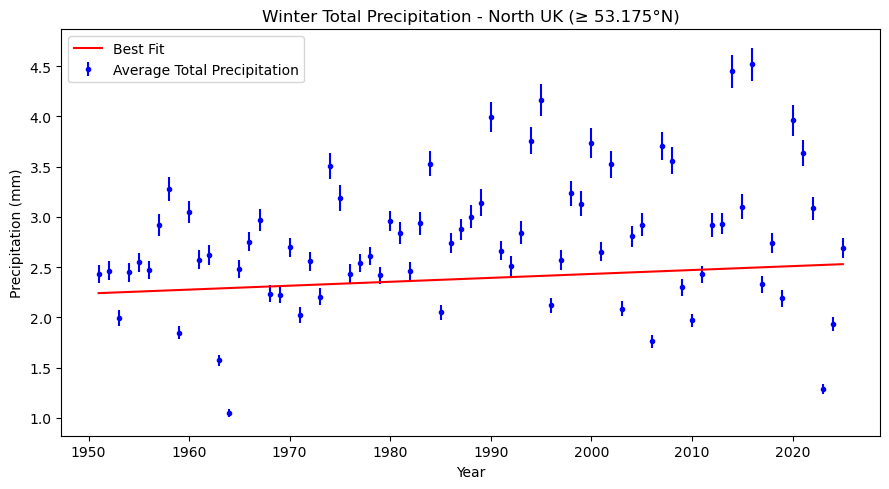

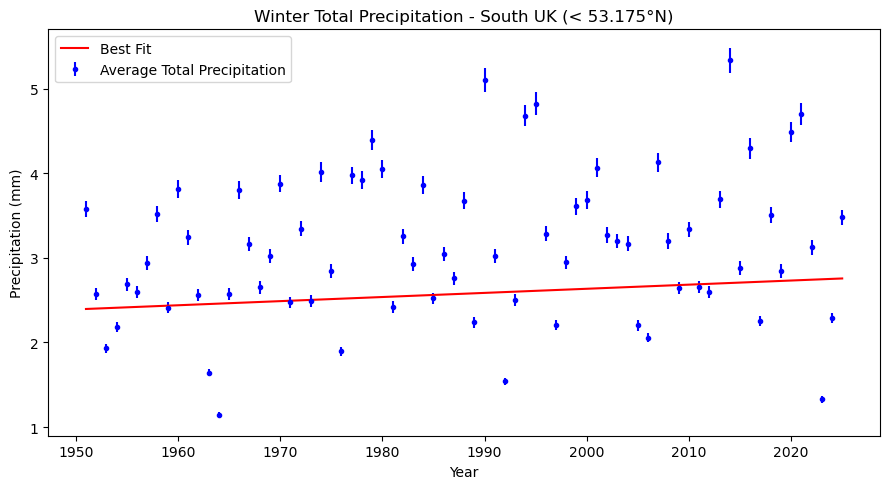

2025 North Winter Precipitation: 2.69 mm
2025 South Winter Precipitation: 3.48 mm

North Slope: 0.00389 ± 0.00046 mm/year
South Slope: 0.00487 ± 0.00037 mm/year


In [22]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

tp_data = data.tp
latitudes = data.latitude.values
time_values = data.valid_time.values

months = np.array([t.astype('datetime64[M]').item().month for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

adjusted_years = years.copy()
adjusted_years[months == 12] += 1

north_mask = latitudes >= 53.175
south_mask = latitudes < 53.175

winter_years = []
north_totals = []
south_totals = []
north_errors = []
south_errors = []

for yr in np.unique(adjusted_years):
    mask = (adjusted_years == yr) & (np.isin(months, [12, 1, 2]))
    if np.sum(mask) == 3:
        tp_winter = tp_data.isel(valid_time=np.where(mask)[0])

        tp_north = tp_winter.isel(latitude=np.where(north_mask)[0])
        tp_south = tp_winter.isel(latitude=np.where(south_mask)[0])

        north_total = tp_north.sum(dim="valid_time", skipna=True) * 1000  # mm
        south_total = tp_south.sum(dim="valid_time", skipna=True) * 1000

        north_mean = north_total.mean(dim=("latitude", "longitude"), skipna=True).values.item()
        south_mean = south_total.mean(dim=("latitude", "longitude"), skipna=True).values.item()

        north_std = north_total.std(dim=("latitude", "longitude"), skipna=True).values.item()
        south_std = south_total.std(dim=("latitude", "longitude"), skipna=True).values.item()

        n_north = tp_north.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()
        n_south = tp_south.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()

        north_se = north_std / np.sqrt(n_north)
        south_se = south_std / np.sqrt(n_south)

        winter_years.append(yr)
        north_totals.append(north_mean)
        south_totals.append(south_mean)
        north_errors.append(north_se)
        south_errors.append(south_se)

winter_years = np.array(winter_years)
north_totals = np.array(north_totals)
south_totals = np.array(south_totals)
north_errors = np.array(north_errors)
south_errors = np.array(south_errors)

def linear_model(x, m, b):
    return m * x + b

popt_north, pcov_north = curve_fit(linear_model, winter_years, north_totals, sigma=north_errors, absolute_sigma=True)
slope_north, intercept_north = popt_north
slope_north_err = np.sqrt(pcov_north[0, 0])
fit_north = linear_model(winter_years, *popt_north)

popt_south, pcov_south = curve_fit(linear_model, winter_years, south_totals, sigma=south_errors, absolute_sigma=True)
slope_south, intercept_south = popt_south
slope_south_err = np.sqrt(pcov_south[0, 0])
fit_south = linear_model(winter_years, *popt_south)

plt.figure(figsize=(9, 5))
plt.errorbar(winter_years, north_totals, yerr=north_errors, fmt='b.', label='Average Total Precipitation')
plt.plot(winter_years, fit_north, 'r-', label='Best Fit')
plt.title('Winter Total Precipitation - North UK (≥ 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.errorbar(winter_years, south_totals, yerr=south_errors, fmt='b.', label='Average Total Precipitation')
plt.plot(winter_years, fit_south, 'r-', label='Best Fit')
plt.title('Winter Total Precipitation - South UK (< 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.tight_layout()
plt.show()

if 2025 in winter_years:
    idx_2025 = np.where(winter_years == 2025)[0][0]
    print(f"2025 North Winter Precipitation: {north_totals[idx_2025]:.2f} mm")
    print(f"2025 South Winter Precipitation: {south_totals[idx_2025]:.2f} mm")

print(f"\nNorth Slope: {slope_north:.5f} ± {slope_north_err:.5f} mm/year")
print(f"South Slope: {slope_south:.5f} ± {slope_south_err:.5f} mm/year")


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


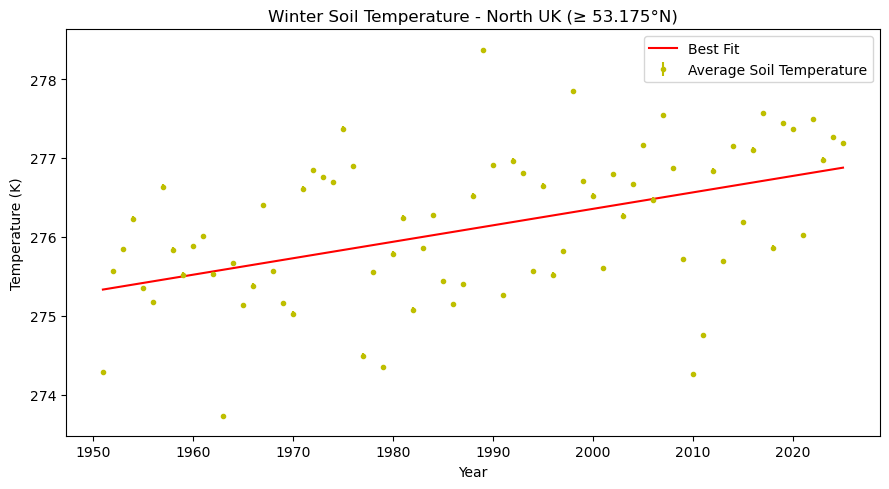

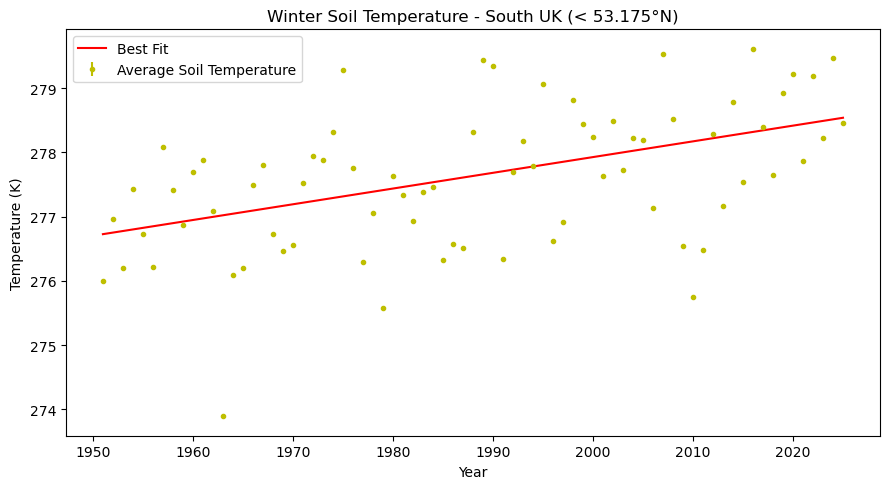

2025 North Winter Soil Temperature: 277.19 K
2025 South Winter Soil Temperature: 278.46 K

North Slope: 0.02089 ± 0.00015 K/year
South Slope: 0.02449 ± 0.00010 K/year


In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

stl1_data = data.stl1
latitudes = data.latitude.values
time_values = data.valid_time.values

months = np.array([t.astype('datetime64[M]').item().month for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

adjusted_years = years.copy()
adjusted_years[months == 12] += 1

north_mask = latitudes >= 53.175
south_mask = latitudes < 53.175

winter_years = []
north_totals = []
south_totals = []
north_errors = []
south_errors = []

for yr in np.unique(adjusted_years):
    mask = (adjusted_years == yr) & (np.isin(months, [12, 1, 2]))
    if np.sum(mask) == 3:
        stl1_winter = stl1_data.isel(valid_time=np.where(mask)[0])

        stl1_north = stl1_winter.isel(latitude=np.where(north_mask)[0])
        stl1_south = stl1_winter.isel(latitude=np.where(south_mask)[0])

        north_total = stl1_north.mean(dim="valid_time", skipna=True)
        south_total = stl1_south.mean(dim="valid_time", skipna=True)

        north_mean = north_total.mean(dim=("latitude", "longitude"), skipna=True).values.item()
        south_mean = south_total.mean(dim=("latitude", "longitude"), skipna=True).values.item()

        north_std = north_total.std(dim=("latitude", "longitude"), skipna=True).values.item()
        south_std = south_total.std(dim=("latitude", "longitude"), skipna=True).values.item()

        n_north = stl1_north.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()
        n_south = stl1_south.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()

        north_se = north_std / np.sqrt(n_north)
        south_se = south_std / np.sqrt(n_south)

        winter_years.append(yr)
        north_totals.append(north_mean)
        south_totals.append(south_mean)
        north_errors.append(north_se)
        south_errors.append(south_se)

winter_years = np.array(winter_years)
north_totals = np.array(north_totals)
south_totals = np.array(south_totals)
north_errors = np.array(north_errors)
south_errors = np.array(south_errors)

def linear_model(x, m, b):
    return m * x + b

popt_north, pcov_north = curve_fit(linear_model, winter_years, north_totals, sigma=north_errors, absolute_sigma=True)
slope_north, intercept_north = popt_north
slope_north_err = np.sqrt(pcov_north[0, 0])
fit_north = linear_model(winter_years, *popt_north)

popt_south, pcov_south = curve_fit(linear_model, winter_years, south_totals, sigma=south_errors, absolute_sigma=True)
slope_south, intercept_south = popt_south
slope_south_err = np.sqrt(pcov_south[0, 0])
fit_south = linear_model(winter_years, *popt_south)

plt.figure(figsize=(9, 5))
plt.errorbar(winter_years, north_totals, yerr=north_errors, fmt='y.', label='Average Soil Temperature')
plt.plot(winter_years, fit_north, 'r-', label='Best Fit')
plt.title('Winter Soil Temperature - North UK (≥ 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.errorbar(winter_years, south_totals, yerr=south_errors, fmt='y.', label='Average Soil Temperature')
plt.plot(winter_years, fit_south, 'r-', label='Best Fit')
plt.title('Winter Soil Temperature - South UK (< 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.legend()
plt.tight_layout()
plt.show()

if 2025 in winter_years:
    idx_2025 = np.where(winter_years == 2025)[0][0]
    print(f"2025 North Winter Soil Temperature: {north_totals[idx_2025]:.2f} K")
    print(f"2025 South Winter Soil Temperature: {south_totals[idx_2025]:.2f} K")

print(f"\nNorth Slope: {slope_north:.5f} ± {slope_north_err:.5f} K/year")
print(f"South Slope: {slope_south:.5f} ± {slope_south_err:.5f} K/year")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


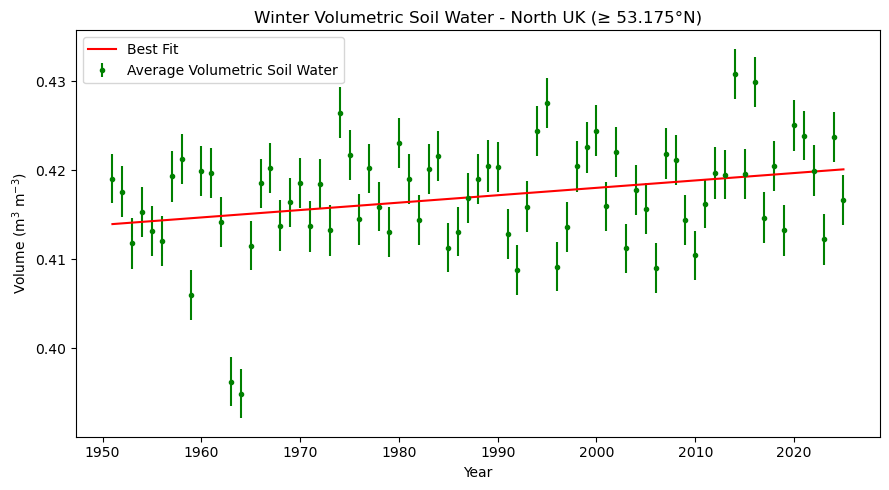

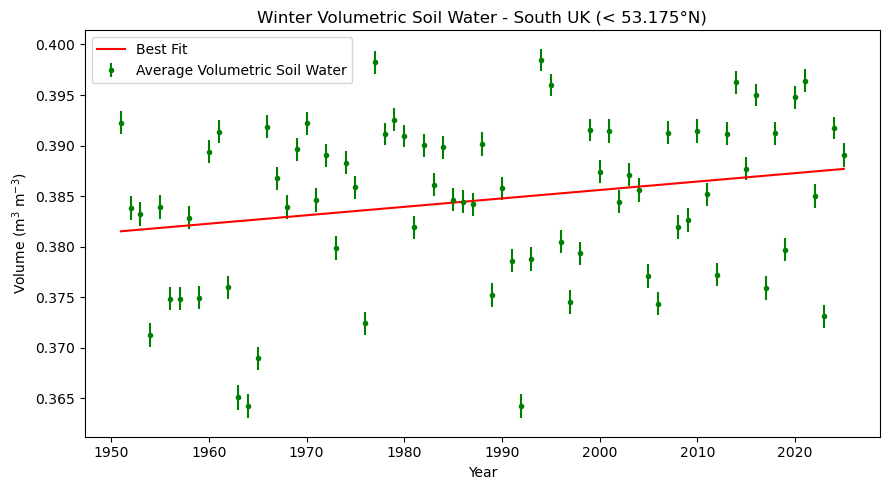

2025 North Winter Soil Water: 0.4167 m3 m-3
2025 South Winter Soil Water: 0.3891 m3 m-3

North Slope: 8.31896e-05 ± 1.50375e-05 m3 m-3 per year
South Slope: 8.33589e-05 ± 6.14555e-06 m3 m-3 per year


In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = xr.open_dataset(r"/Users/anvijoy/Desktop/Anvi/Uni Notes/Internal Placement/data_stream-moda-2.nc")

swvl1_data = data.swvl1
latitudes = data.latitude.values
time_values = data.valid_time.values

months = np.array([t.astype('datetime64[M]').item().month for t in time_values])
years = np.array([t.astype('datetime64[Y]').astype(int) + 1970 for t in time_values])

adjusted_years = years.copy()
adjusted_years[months == 12] += 1

north_mask = latitudes >= 53.175
south_mask = latitudes < 53.175

winter_years = []
north_totals = []
south_totals = []
north_errors = []
south_errors = []

for yr in np.unique(adjusted_years):
    mask = (adjusted_years == yr) & (np.isin(months, [12, 1, 2]))
    if np.sum(mask) == 3:
        swvl1_winter = swvl1_data.isel(valid_time=np.where(mask)[0])

        swvl1_north = swvl1_winter.isel(latitude=np.where(north_mask)[0])
        swvl1_south = swvl1_winter.isel(latitude=np.where(south_mask)[0])

        north_total = swvl1_north.mean(dim="valid_time", skipna=True)
        south_total = swvl1_south.mean(dim="valid_time", skipna=True)

        north_mean = north_total.mean(dim=("latitude", "longitude"), skipna=True).values.item()
        south_mean = south_total.mean(dim=("latitude", "longitude"), skipna=True).values.item()

        north_std = north_total.std(dim=("latitude", "longitude"), skipna=True).values.item()
        south_std = south_total.std(dim=("latitude", "longitude"), skipna=True).values.item()

        n_north = swvl1_north.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()
        n_south = swvl1_south.isel(valid_time=0).count(dim=("latitude", "longitude")).values.item()

        north_se = north_std / np.sqrt(n_north)
        south_se = south_std / np.sqrt(n_south)

        winter_years.append(yr)
        north_totals.append(north_mean)
        south_totals.append(south_mean)
        north_errors.append(north_se)
        south_errors.append(south_se)

winter_years = np.array(winter_years)
north_totals = np.array(north_totals)
south_totals = np.array(south_totals)
north_errors = np.array(north_errors)
south_errors = np.array(south_errors)

def linear_model(x, m, b):
    return m * x + b

popt_north, pcov_north = curve_fit(linear_model, winter_years, north_totals, sigma=north_errors, absolute_sigma=True)
slope_north, intercept_north = popt_north
slope_north_err = np.sqrt(pcov_north[0, 0])
fit_north = linear_model(winter_years, *popt_north)

popt_south, pcov_south = curve_fit(linear_model, winter_years, south_totals, sigma=south_errors, absolute_sigma=True)
slope_south, intercept_south = popt_south
slope_south_err = np.sqrt(pcov_south[0, 0])
fit_south = linear_model(winter_years, *popt_south)

plt.figure(figsize=(9, 5))
plt.errorbar(winter_years, north_totals, yerr=north_errors, fmt='g.', label='Average Volumetric Soil Water')
plt.plot(winter_years, fit_north, 'r-', label='Best Fit')
plt.title('Winter Volumetric Soil Water - North UK (≥ 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Volume (m$^3$ m$^{-3}$)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.errorbar(winter_years, south_totals, yerr=south_errors, fmt='g.', label='Average Volumetric Soil Water')
plt.plot(winter_years, fit_south, 'r-', label='Best Fit')
plt.title('Winter Volumetric Soil Water - South UK (< 53.175°N)')
plt.xlabel('Year')
plt.ylabel('Volume (m$^3$ m$^{-3}$)')
plt.legend()
plt.tight_layout()
plt.show()

if 2025 in winter_years:
    idx_2025 = np.where(winter_years == 2025)[0][0]
    print(f"2025 North Winter Soil Water: {north_totals[idx_2025]:.4f} m3 m-3")
    print(f"2025 South Winter Soil Water: {south_totals[idx_2025]:.4f} m3 m-3")

print(f"\nNorth Slope: {slope_north:.5e} ± {slope_north_err:.5e} m3 m-3 per year")
print(f"South Slope: {slope_south:.5e} ± {slope_south_err:.5e} m3 m-3 per year")


## 